In [1]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from scipy.stats import kendalltau
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from statsmodels.stats.multitest import multipletests
from itertools import combinations, product
import re
import unicodedata
import math

In [2]:
# import data
gcms_df = pd.read_csv('seed_derived_gcms_data.csv', engine='python')
seed_traits_df = pd.read_csv('seed_traits.csv', engine='python')
seed_area_df = pd.read_csv('seed_area_measurements.csv', engine='python')

In [3]:
# Function to approximate 3D seed surface area from projected area using species-specific correction factors
def surface_area_approximation(
    df,
    species_col="species",
    projected_area_col="projected_surface_area/mm^2",
    new_col="approx_surface_area/mm^2",
):
    """
    Multiply projected surface area by species-specific correction factors
    to approximate true 3D surface area.

    Parameters
    ----------
    df : DataFrame
        Must contain species_col and projected_area_col.
    custom_factors : dict or None
        Optional dictionary mapping species -> correction factor.
        If None, default factors based on morphology are used.

    Returns
    -------
    DataFrame with additional column new_col.
    """

    # Default morphology-based factors (transparent + editable)
    correction_factors = {
        "Lactuca serriola": 2.0,             # very flat
        "Daucus carota": 2.2,                # moderately flat
        "Vaccinium oxycoccus": 2.5,
        "Papaver rhoeas": 3.0,               # roughly kidney-shaped
        "Mesembryanthemum crystallinum": 3.0,
        "Ficus sycomorus": 3.0,
        "Trifolium pratense": 3.4,           # round/ellipsoid
    }

    df = df.copy()

    # Map species to factor
    df["correction_factor"] = df[species_col].map(correction_factors)

    # Warn if any species missing
    if df["correction_factor"].isna().any():
        missing = df.loc[df["correction_factor"].isna(), species_col].unique()
        raise ValueError(f"No correction factor provided for: {missing}")

    # Apply correction
    df[new_col] = df[projected_area_col] * df["correction_factor"]

    return df, correction_factors

seed_area_df, corr_factors = surface_area_approximation(seed_area_df)
seed_area_df.to_csv('seed_area_approximations.csv', index=False)

In [4]:
# Create a global ID map for compounds
HYPHENS_RE = re.compile(r"[\u2010\u2011\u2012\u2013\u2014\u2212]")  # ‐-‒–—−
SQUARE_BRACKETS_RE = re.compile(r"\[[^\]]*\]")

# Remove things like (E), (Z), (E,Z), (R), (S), (all-Z), cis/trans etc
STEREO_PARENS_RE = re.compile(
    r"\(\s*(?:[ersz]|[ez]\s*,\s*[ez]|cis|trans|dl|d|l|all-z|all\s*-\s*z|e,e,e|e,z|z,e|e,e|z,z)\s*\)",
    flags=re.IGNORECASE,
)

DOT_GREEK_REPLACEMENTS = {
    r"\.alpha\.": " alpha ",
    r"\.beta\.":  " beta ",
    r"\.gamma\.": " gamma ",
    r"\.delta\.": " delta ",
}

GREEK_CHAR_MAP = {"α":"alpha","β":"beta","γ":"gamma","δ":"delta","ε":"epsilon","μ":"mu","ω":"omega"}
LEADING_STEREO_PREFIX_RE = re.compile(r"^(?:cis|trans|dl|d|l)\s*-\s*", flags=re.IGNORECASE)

def normalise_compound_name(s) -> str:
    if s is None:
        return ""
    if not isinstance(s, str):
        s = str(s)

    s = unicodedata.normalize("NFKC", s).lower()
    s = HYPHENS_RE.sub("-", s)

    # greek chars
    for g, w in GREEK_CHAR_MAP.items():
        s = s.replace(g, w)

    # ".beta." style
    for pat, repl in DOT_GREEK_REPLACEMENTS.items():
        s = re.sub(pat, repl, s, flags=re.IGNORECASE)

    # remove bracket blocks like [1R-(...)]
    s = SQUARE_BRACKETS_RE.sub(" ", s)

    # Remove parenthetical stereochem blocks that contain alpha/beta (or greek letters)
    s = re.sub(r"\([^)]*(?:alpha|beta|gamma|delta|α|β|γ|δ)[^)]*\)\s*-?", " ", s, flags=re.IGNORECASE)

    # remove small stereo parentheses
    s = STEREO_PARENS_RE.sub(" ", s)

    # drop leading "trans-" / "cis-" etc (outside parentheses)
    s = LEADING_STEREO_PREFIX_RE.sub("", s)

    # remove stray leading dots
    s = re.sub(r"^\.+", "", s)

    # keep letters/digits/hyphens/spaces, turn other punctuation into spaces
    s = re.sub(r"[^a-z0-9\-\s]", " ", s)

    # collapse whitespace
    s = re.sub(r"\s+", " ", s).strip()

    # KEY STEP: collapse spaces around hyphens so "beta -myrcene" -> "beta-myrcene"
    s = re.sub(r"\s*-\s*", "-", s)

    # strip trailing hyphens
    s = re.sub(r"-+$", "", s)

    return s

In [5]:
oil_markers = ['Nonadecane',
'Octadecane',
'Heneicosane',
'Eicosane',
'Henicos-1-ene',
'Octadecane, 3-methyl-',
'Heptadecane, 3-methyl-',
'Octadecane, 2-methyl-',
'Nonanoic acid',
'β-Myrcene',
'p-Cymene',
'2,6-Octadien-1-ol, 3,7-dimethyl-, acetate (Z)',
'Pentadecane',
'1-Tetradecanol',
'Geraniol',
'6-Hydroxy-3,7-dimethyl-2,7-octadienyl acetate (E)',
'2,6-Octadien-1-ol, 3,7-dimethyl-, acetate (Z)',
'Acetic acid, 3-methyl-6-oxo-hex-2-enyl ester'
]

oil_markers = [normalise_compound_name(c) for c in oil_markers]

In [6]:
ageing_markers = ['Hexadecanal',
'Pentadecanal',
'Butanoic acid, 2-methyl-',
'Acetone',
'2-Octenal (E)',
'2-Decenal (E)',
'Furan, 2-pentyl-',
'1-Hexanol',
'Benzaldehyde',
]

ageing_markers = [normalise_compound_name(c) for c in ageing_markers]

In [ ]:
# Function to create species×treatment summary with signal totals and seed traits
def make_species_treatment_summary(
    gcms_df,
    seed_area_df,
    seed_traits_df,
    subset=None,
    expected_n_replicates=3,
    species_col="species",
    treatment_col="treatment",
    replicate_col="replicate",
    signal_col="area",
    n_seeds_col="n_seeds",
    sample_mass_col="sample_mass_mg",
    compound_id_col="compound_id",
    compound_name_col="compound_name",
    compound_norm_col="compound_norm",
    empty_label="Empty",
    # seed_area_df columns
    seed_area_species_col="species",
    projected_area_col="projected_surface_area/mm^2",
    approx_area_col="approx_surface_area/mm^2",
    # seed_traits_df columns
    seed_traits_species_col="species",
    seed_mass_col="seed_mass_mg",
    oil_low_col="oil_content_low",
    oil_high_col="oil_content_high",
    oil_mean_col="oil_content_mean",
    germination_change_col="germination_change",
):
    """
    Returns species×treatment summary with:
      - mean/std/min/max total signal per seed and per mass
      - n_replicates
      - mean/std projected and approx seed surface area
      - species-level seed trait columns from seed_traits_df

    If a species×treatment has fewer than expected_n_replicates observed in gcms_df,
    missing replicates are added with total_signal = 0.
    """

    def make_mask(d):
        if subset is None:
            return pd.Series(True, index=d.index)
        if callable(subset):
            return pd.Series(subset(d), index=d.index)

        if isinstance(subset, dict):
            if "query" in subset:
                return d.eval(subset["query"]).astype(bool)

            if "ids" in subset:
                return d[compound_id_col].isin(set(subset["ids"]))

            if "names" in subset:
                names = [str(x) for x in subset["names"]]
                match = subset.get("match", "exact")
                s = d[compound_name_col].fillna("").astype(str)
                if match == "exact":
                    return s.isin(set(names))
                elif match == "contains":
                    m = pd.Series(False, index=d.index)
                    for nm in names:
                        m |= s.str.contains(nm, case=False, na=False, regex=False)
                    return m
                else:
                    raise ValueError("subset['match'] must be 'exact' or 'contains'")

            if "norm" in subset:
                norms = [str(x) for x in subset["norm"]]
                match = subset.get("match", "exact")
                s = d[compound_norm_col].fillna("").astype(str)
                if match == "exact":
                    return s.isin(set(norms))
                elif match == "contains":
                    m = pd.Series(False, index=d.index)
                    for nm in norms:
                        m |= s.str.contains(nm, case=False, na=False, regex=False)
                    return m
                else:
                    raise ValueError("subset['match'] must be 'exact' or 'contains'")

        raise ValueError("Bad subset spec")

    # ---- base: remove Empty once and use everywhere ----
    base = gcms_df[gcms_df[species_col] != empty_label].copy()

    # subset-applied detections for signal totals
    d = base[make_mask(base)].copy()

    # replicate totals for signal (subset)
    rep_sig = (
        d.groupby([species_col, treatment_col, replicate_col], dropna=False)[signal_col]
         .sum()
         .rename("total_signal")
         .reset_index()
    )

    # replicate grid for all observed replicates
    grid = (
        base.groupby([species_col, treatment_col, replicate_col], dropna=False)
            .agg(
                n_seeds=(n_seeds_col, "first"),
                sample_mass=(sample_mass_col, "first"),
            )
            .reset_index()
    )

    rep = grid.merge(rep_sig, on=[species_col, treatment_col, replicate_col], how="left")
    rep["total_signal"] = rep["total_signal"].fillna(0.0)

    # force numeric
    rep["n_seeds"] = pd.to_numeric(rep["n_seeds"], errors="coerce")
    rep["sample_mass"] = pd.to_numeric(rep["sample_mass"], errors="coerce")

    # per-replicate ratios
    rep["signal_per_seed"] = rep["total_signal"] / rep["n_seeds"]
    rep["signal_per_mass"] = rep["total_signal"] / rep["sample_mass"]

    # ------------------------------------------------------------------
    # Pad each species×treatment to expected_n_replicates with zero rows
    # ------------------------------------------------------------------
    padded_rows = []

    for (sp, tr), grp in rep.groupby([species_col, treatment_col], dropna=False):
        n_obs = len(grp)
        n_missing = max(0, expected_n_replicates - n_obs)

        if n_missing > 0:
            existing_labels = set(grp[replicate_col].astype(str))

            for j in range(n_missing):
                new_label = f"__added_zero_rep_{j+1}"
                while new_label in existing_labels:
                    new_label = f"__added_zero_rep_{j+1}_x"

                padded_rows.append({
                    species_col: sp,
                    treatment_col: tr,
                    replicate_col: new_label,
                    "n_seeds": np.nan,
                    "sample_mass": np.nan,
                    "total_signal": 0.0,
                    "signal_per_seed": 0.0,
                    "signal_per_mass": 0.0,
                })

    if padded_rows:
        rep = pd.concat([rep, pd.DataFrame(padded_rows)], ignore_index=True)

    # species×treatment mean/std/min/max across replicates
    out = (
        rep.groupby([species_col, treatment_col], dropna=False)
           .agg(
               mean_total_area_sample_mass=("signal_per_mass", "mean"),
               std_total_area_sample_mass=("signal_per_mass", "std"),
               min_total_area_sample_mass=("signal_per_mass", "min"),
               max_total_area_sample_mass=("signal_per_mass", "max"),
               mean_total_area_n_seeds=("signal_per_seed", "mean"),
               std_total_area_n_seeds=("signal_per_seed", "std"),
               min_total_area_n_seeds=("signal_per_seed", "min"),
               max_total_area_n_seeds=("signal_per_seed", "max"),
               mean_n_seeds=("n_seeds", "mean"),
               std_n_seeds=("n_seeds", "std"),
               n_replicates=(replicate_col, "nunique"),
           )
           .reset_index()
           .rename(columns={
               "mean_total_area_sample_mass": "mean_total_area/sample_mass",
               "std_total_area_sample_mass": "std_total_area/sample_mass",
               "min_total_area_sample_mass": "min_total_area/sample_mass",
               "max_total_area_sample_mass": "max_total_area/sample_mass",
               "mean_total_area_n_seeds": "mean_total_area/n_seeds",
               "std_total_area_n_seeds": "std_total_area/n_seeds",
               "min_total_area_n_seeds": "min_total_area/n_seeds",
               "max_total_area_n_seeds": "max_total_area/n_seeds",
           })
    )

    # ---- merge seed surface areas (species-level; same for all treatments) ----
    sa = (
        seed_area_df[seed_area_df[seed_area_species_col] != empty_label]
        .groupby(seed_area_species_col, dropna=False)
        .agg(
            mean_projected_surface_area=(projected_area_col, "mean"),
            std_projected_surface_area=(projected_area_col, "std"),
            mean_approx_surface_area=(approx_area_col, "mean"),
            std_approx_surface_area=(approx_area_col, "std"),
            n_area_measurements=(projected_area_col, "count"),
        )
        .reset_index()
        .rename(columns={seed_area_species_col: species_col})
    )

    out = out.merge(sa, on=species_col, how="left")

    # ---- merge seed traits directly (already one row per species) ----
    st = (
        seed_traits_df.loc[seed_traits_df[seed_traits_species_col] != empty_label, [
            seed_traits_species_col,
            seed_mass_col,
            oil_low_col,
            oil_high_col,
            oil_mean_col,
            germination_change_col,
        ]]
        .drop_duplicates(subset=[seed_traits_species_col])
        .rename(columns={
            seed_traits_species_col: species_col,
            seed_mass_col: "seed_mass_mg",
            oil_low_col: "oil_content_low",
            oil_high_col: "oil_content_high",
            oil_mean_col: "oil_content_mean",
            germination_change_col: "germination_change",
        })
    )

    out = out.merge(st, on=species_col, how="left")

    return out

all_summary = make_species_treatment_summary(gcms_df, seed_area_df, seed_traits_df)
oil_markers_summary = make_species_treatment_summary(gcms_df, seed_area_df, seed_traits_df, subset={"norm": oil_markers, "match": "exact"})
ageing_markers_summary = make_species_treatment_summary(gcms_df, seed_area_df, seed_traits_df, subset={"norm": ageing_markers, "match": "exact"})

all_summary

,species,treatment,mean_total_area/sample_mass,std_total_area/sample_mass,min_total_area/sample_mass,max_total_area/sample_mass,mean_total_area/n_seeds,std_total_area/n_seeds,min_total_area/n_seeds,max_total_area/n_seeds,...,mean_projected_surface_area,std_projected_surface_area,mean_approx_surface_area,std_approx_surface_area,n_area_measurements,seed_mass_mg,oil_content_low,oil_content_high,oil_content_mean,germination_change
0,Daucus carota,normal_atm_whole,1.361667e+07,1.746321e+06,1.242364e+07,1.562107e+07,1.170934e+07,1.536284e+06,1.066362e+07,1.347318e+07,...,2.9158,0.550869,6.41476,1.211911,10,0.8513,0.193,0.193,0.193,-10.2
1,Daucus carota,vacuum_cut,6.335992e+07,2.089422e+07,4.082647e+07,8.209333e+07,5.444186e+07,1.851663e+07,3.453239e+07,7.114755e+07,...,2.9158,0.550869,6.41476,1.211911,10,0.8513,0.193,0.193,0.193,-10.2
2,Daucus carota,vacuum_whole,2.124839e+07,5.318695e+06,1.631880e+07,2.688539e+07,1.820168e+07,4.693372e+06,1.387098e+07,2.318865e+07,...,2.9158,0.550869,6.41476,1.211911,10,0.8513,0.193,0.193,0.193,-10.2
3,Ficus sycomorus,normal_atm_whole,1.911672e+05,8.228290e+04,1.296512e+05,2.846333e+05,1.070003e+05,4.538156e+04,7.274872e+04,1.584715e+05,...,1.3559,0.498106,4.06770,1.494318,10,0.5623,0.050,0.300,0.175,-22.3
4,Ficus sycomorus,vacuum_cut,2.294149e+07,7.149670e+06,1.581012e+07,3.010932e+07,1.281410e+07,3.980953e+06,8.802392e+06,1.676357e+07,...,1.3559,0.498106,4.06770,1.494318,10,0.5623,0.050,0.300,0.175,-22.3
5,Ficus sycomorus,vacuum_whole,1.316555e+07,5.504069e+06,7.573141e+06,1.857681e+07,7.387529e+06,3.114996e+06,4.216397e+06,1.044318e+07,...,1.3559,0.498106,4.06770,1.494318,10,0.5623,0.050,0.300,0.175,-22.3
6,Lactuca serriola,normal_atm_whole,3.019106e+05,2.545620e+05,7.911670e+04,5.793616e+05,2.322476e+05,1.962454e+05,6.085900e+04,4.463230e+05,...,3.4929,0.272704,6.98580,0.545407,10,0.7653,0.310,0.380,0.345,-2.0
7,Lactuca serriola,vacuum_cut,1.764810e+07,2.495317e+06,1.614880e+07,2.052864e+07,1.335961e+07,1.931430e+06,1.214151e+07,1.558656e+07,...,3.4929,0.272704,6.98580,0.545407,10,0.7653,0.310,0.380,0.345,-2.0
8,Lactuca serriola,vacuum_whole,2.258420e+06,3.528098e+05,1.926379e+06,2.628857e+06,1.711480e+06,2.627730e+05,1.462621e+06,1.986248e+06,...,3.4929,0.272704,6.98580,0.545407,10,0.7653,0.310,0.380,0.345,-2.0
9,Mesembryanthemum crystallinum,normal_atm_whole,6.075728e+04,6.182413e+04,0.000000e+00,1.235957e+05,1.092565e+04,1.111750e+04,0.000000e+00,2.222554e+04,...,0.4529,0.060491,1.35870,0.181474,10,0.1793,0.075,0.075,0.075,1.3


In [45]:
def plot_normalised_signal_area_vs_trait(
    summary_df,
    normalise_by="n_seeds",
    x_var="surface_area",               # "surface_area", "oil_content", "germination_change"
    surface_area="approx",
    x_axis_surface_areas="individual",  # only used if x_var="surface_area"
    species_col="species",
    treatment_col="treatment",

    # surface-area cols
    mean_projected_col="mean_projected_surface_area",
    std_projected_col="std_projected_surface_area",
    mean_approx_col="mean_approx_surface_area",
    std_approx_col="std_approx_surface_area",

    # replicate-count cols
    mean_n_seeds_col="mean_n_seeds",
    std_n_seeds_col="std_n_seeds",

    # seed-trait cols
    oil_content_low_col="oil_content_low",
    oil_content_high_col="oil_content_high",
    oil_content_mean_col="oil_content_mean",
    germination_change_col="germination_change",

    label_map=None,
    ax=None,
    show=True,
    markersize=6,
    band_alpha=0.22,
    yscale="log",
):
    """
    Plot total signal area (normalised per seed or per sample mass) against a chosen x-variable.

    x_var options:
      - "surface_area"
      - "oil_content"
      - "germination_change"

    For x_var="surface_area":
      - uses surface_area="projected" or "approx"
      - uses x_axis_surface_areas="individual" or "total"

    For x_var="oil_content":
      - uses oil_content_variant="low", "high", or "mean"

    Returns
    -------
    ax : matplotlib Axes
    """

    if label_map is None:
        label_map = {
            "normal_atm_whole": "Normal atmosphere (whole)",
            "vacuum_whole": "Vacuum (whole)",
            "vacuum_cut": "Vacuum (cut)"
        }

    # ----------------------------
    # Choose y-axis
    # ----------------------------
    if normalise_by == "n_seeds":
        y_col = "mean_total_area/n_seeds"
        y_min_col = "min_total_area/n_seeds"
        y_max_col = "max_total_area/n_seeds"
        ylabel = "Total signal area per seed"
    elif normalise_by == "sample_mass":
        y_col = "mean_total_area/sample_mass"
        y_min_col = "min_total_area/sample_mass"
        y_max_col = "max_total_area/sample_mass"
        ylabel = "Total signal area / sample mass"
    else:
        raise ValueError("normalise_by must be 'n_seeds' or 'sample_mass'")

    # ----------------------------
    # Figure / axes
    # ----------------------------
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))
    else:
        fig = ax.figure

    treatments = summary_df[treatment_col].dropna().unique()
    markers = ["o", "s", "^", "D", "v", "P"]
    marker_map = dict(zip(treatments, markers))

    colour_cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
    if len(colour_cycle) == 0:
        colour_cycle = ["C0", "C1", "C2", "C3", "C4", "C5"]
    colour_map = {tr: colour_cycle[i % len(colour_cycle)] for i, tr in enumerate(treatments)}

    y_text_pos = 0.95
    y_step = 0.05
    xlabel = None

    # ----------------------------
    # X-axis helper
    # ----------------------------
    def get_x_and_xerr(tr_plot):
        # ---- surface area ----
        if x_var == "surface_area":
            if surface_area == "projected":
                area_mean_col = mean_projected_col
                area_std_col = std_projected_col
                area_label = "projected"
            elif surface_area == "approx":
                area_mean_col = mean_approx_col
                area_std_col = std_approx_col
                area_label = "approx."
            else:
                raise ValueError("surface_area must be 'projected' or 'approx'")

            area_mean = pd.to_numeric(tr_plot[area_mean_col], errors="coerce")
            area_std = pd.to_numeric(tr_plot[area_std_col], errors="coerce")

            if x_axis_surface_areas == "individual":
                x = area_mean
                xerr = area_std
                xlabel_local = f"Mean {area_label} seed surface area / mm$^2$"

            elif x_axis_surface_areas == "total":
                if mean_n_seeds_col not in tr_plot.columns:
                    raise ValueError(
                        f"summary_df must include '{mean_n_seeds_col}' when "
                        "x_axis_surface_areas='total'"
                    )

                n_mean = pd.to_numeric(tr_plot[mean_n_seeds_col], errors="coerce")

                if std_n_seeds_col in tr_plot.columns:
                    n_std = pd.to_numeric(tr_plot[std_n_seeds_col], errors="coerce").fillna(0.0)
                else:
                    n_std = pd.Series(0.0, index=tr_plot.index)

                x = area_mean * n_mean

                # propagate uncertainty for x = A * N
                rel_area = np.where(
                    (area_mean > 0) & np.isfinite(area_mean),
                    area_std / area_mean,
                    0.0
                )
                rel_n = np.where(
                    (n_mean > 0) & np.isfinite(n_mean),
                    n_std / n_mean,
                    0.0
                )
                xerr = x * np.sqrt(rel_area**2 + rel_n**2)

                xlabel_local = f"Total {area_label} seed surface area per replicate / mm$^2$"

            else:
                raise ValueError("x_axis_surface_areas must be 'individual' or 'total'")

            return x, xerr, xlabel_local

        # ---- oil content ----
        elif x_var == "oil_content":

            # convert from fractions to percentages
            x_mean = pd.to_numeric(tr_plot[oil_content_mean_col], errors="coerce") * 100.0
            x_low  = pd.to_numeric(tr_plot[oil_content_low_col], errors="coerce") * 100.0
            x_high = pd.to_numeric(tr_plot[oil_content_high_col], errors="coerce") * 100.0

            # asymmetric error bars
            xerr_low = x_mean - x_low
            xerr_high = x_high - x_mean

            xerr = np.vstack([xerr_low, xerr_high])

            xlabel_local = "Oil content (%)"

            return x_mean, xerr, xlabel_local

        # ---- germination change ----
        elif x_var == "germination_change":
            x = pd.to_numeric(tr_plot[germination_change_col], errors="coerce")
            xerr = None
            xlabel_local = "Germination change (%)"
            return x, xerr, xlabel_local

        else:
            raise ValueError("x_var must be 'surface_area', 'oil_content', or 'germination_change'")

    # Decide sort column per x variable
    def get_sort_values(tr_plot):
        x, _, _ = get_x_and_xerr(tr_plot)
        return x

    # ----------------------------
    # First pass: markers and x error bars
    # ----------------------------
    for i, tr in enumerate(treatments):
        tr_plot = summary_df[summary_df[treatment_col] == tr].copy()
        tr_plot = tr_plot.assign(_sort_x=get_sort_values(tr_plot)).sort_values("_sort_x")

        x, xerr, xlabel = get_x_and_xerr(tr_plot)
        y = pd.to_numeric(tr_plot[y_col], errors="coerce")

        label = label_map.get(tr, tr)
        marker = marker_map.get(tr, "o")
        colour = colour_map[tr]

        ax.errorbar(
            x, y,
            xerr=xerr,
            yerr=None,
            fmt=marker,
            capsize=3 if xerr is not None else 0,
            elinewidth=1,
            markersize=markersize,
            color=colour,
            label=label,
        )

        good = np.isfinite(x) & np.isfinite(y)
        if good.sum() > 2:
            tau, p_value = kendalltau(x[good], y[good])
            ax.text(
                1.02, y_text_pos - i * y_step,
                f"{label}: $τ = {tau:.2f}$",
                transform=ax.transAxes,
                fontsize=9,
            )
            print(f"{tr}: Kendall's tau: {tau}, p-value: {p_value}")

    ax.set_xlabel(xlabel or "Trait value")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    fig.legend(bbox_to_anchor=(0.75, 0.55), loc="upper left")

    if yscale is not None:
        ax.set_yscale(yscale)

    # ----------------------------
    # Determine band width in x units
    # ----------------------------
    fig.canvas.draw()

    marker_diameter_points = markersize
    marker_diameter_pixels = marker_diameter_points * fig.dpi / 72.0

    if yscale == "log":
        ymin, ymax = ax.get_ylim()
        ymid = np.sqrt(ymin * ymax)
    else:
        ymin, ymax = ax.get_ylim()
        ymid = 0.5 * (ymin + ymax)

    ymid_disp = ax.transData.transform((0, ymid))[1]
    x0_disp = ax.transData.transform((0, ymin))[0]
    x1_disp = x0_disp + marker_diameter_pixels

    x0_data = ax.transData.inverted().transform((x0_disp, ymid_disp))[0]
    x1_data = ax.transData.inverted().transform((x1_disp, ymid_disp))[0]
    band_width = abs(x1_data - x0_data)

    # ----------------------------
    # Second pass: vertical min-max bands
    # ----------------------------
    for tr in treatments:
        tr_plot = summary_df[summary_df[treatment_col] == tr].copy()
        tr_plot = tr_plot.assign(_sort_x=get_sort_values(tr_plot)).sort_values("_sort_x")

        x, _, _ = get_x_and_xerr(tr_plot)
        y_min = pd.to_numeric(tr_plot[y_min_col], errors="coerce")
        y_max = pd.to_numeric(tr_plot[y_max_col], errors="coerce")
        colour = colour_map[tr]

        for xi, ylo, yhi in zip(x, y_min, y_max):
            if np.isfinite(xi) and np.isfinite(ylo) and np.isfinite(yhi):
                if yhi < ylo:
                    ylo, yhi = yhi, ylo

                rect = Rectangle(
                    (xi - band_width / 2, ylo),
                    band_width,
                    yhi - ylo,
                    facecolor=colour,
                    edgecolor="none",
                    alpha=band_alpha,
                    zorder=1,
                )
                ax.add_patch(rect)

    for line in ax.lines:
        line.set_zorder(3)

    #plt.savefig('Plots/oil_markers_signal_area_per_unit_mass_vs_seed_surface_area.png', dpi=300, bbox_inches='tight')

    plt.tight_layout()

    if show:
        plt.show()

    return ax

normal_atm_whole: Kendall's tau: 0.14285714285714288, p-value: 0.7726190476190476
vacuum_cut: Kendall's tau: 0.14285714285714288, p-value: 0.7726190476190476
vacuum_whole: Kendall's tau: -0.04761904761904762, p-value: 1.0


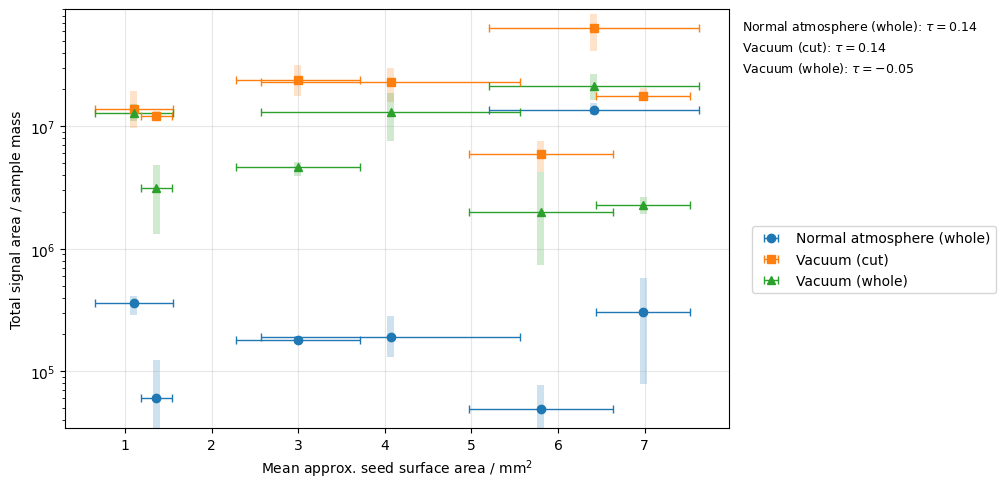

<Axes: xlabel='Mean approx. seed surface area / mm$^2$', ylabel='Total signal area / sample mass'>

In [46]:
plot_normalised_signal_area_vs_trait(
    all_summary,
    normalise_by="sample_mass",
    x_var="surface_area",
    surface_area="approx",
    x_axis_surface_areas="individual",
)

normal_atm_whole: Kendall's tau: 0.5238095238095238, p-value: 0.1361111111111111
vacuum_cut: Kendall's tau: 0.14285714285714288, p-value: 0.7726190476190476
vacuum_whole: Kendall's tau: 0.14285714285714288, p-value: 0.7726190476190476


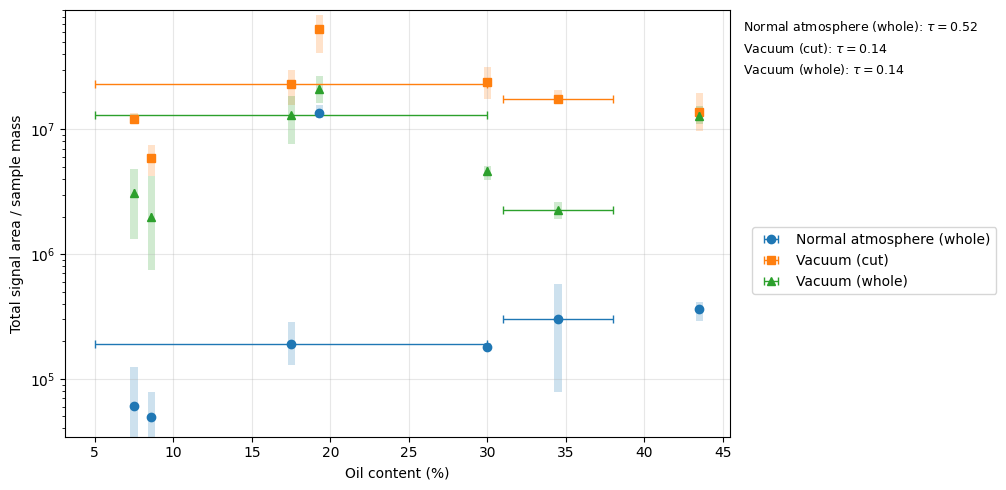

<Axes: xlabel='Oil content (%)', ylabel='Total signal area / sample mass'>

In [47]:
plot_normalised_signal_area_vs_trait(
    all_summary,
    normalise_by="sample_mass",
    x_var="oil_content",
)

normal_atm_whole: Kendall's tau: -0.23809523809523814, p-value: 0.5619047619047619
vacuum_cut: Kendall's tau: -0.04761904761904762, p-value: 1.0
vacuum_whole: Kendall's tau: -0.23809523809523814, p-value: 0.5619047619047619


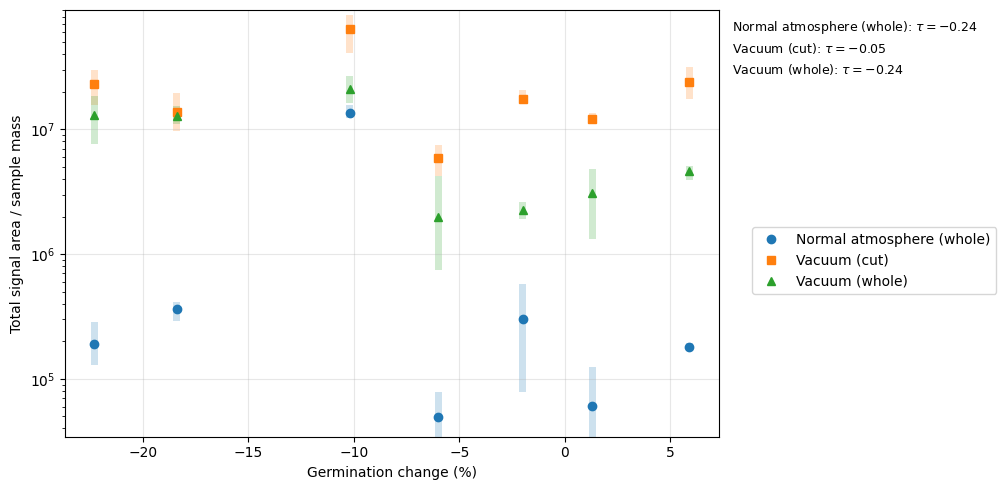

<Axes: xlabel='Germination change (%)', ylabel='Total signal area / sample mass'>

In [48]:
plot_normalised_signal_area_vs_trait(
    all_summary,
    normalise_by="sample_mass",
    x_var="germination_change",
)

In [ ]:
# Function to bootstrap confidence interval for Kendall's tau
def bootstrap_kendall_tau(
    summary_df,
    treatment,
    x_var="oil_content",
    normalise_by="n_seeds",
    n_bootstrap=5000,
    random_state=42,

    # summary args
    expected_n_replicates=3,
    species_col="species",
    treatment_col="treatment",
    empty_label="Empty",

    # x columns
    oil_content_mean_col="oil_content_mean",
    germination_change_col="germination_change",
    mean_projected_col="mean_projected_surface_area",
    mean_approx_col="mean_approx_surface_area",
    surface_area="approx",
):
    """
    Bootstrap confidence interval for Kendall's tau.
    """

    rng = np.random.default_rng(random_state)

    df = summary_df.loc[summary_df[treatment_col] == treatment].copy()

    # ----------------------------
    # Extract x
    # ----------------------------
    if x_var == "oil_content":
        x = pd.to_numeric(df[oil_content_mean_col], errors="coerce") * 100.0
    elif x_var == "germination_change":
        x = pd.to_numeric(df[germination_change_col], errors="coerce")
    elif x_var == "surface_area":
        if surface_area == "projected":
            x = pd.to_numeric(df[mean_projected_col], errors="coerce")
        else:
            x = pd.to_numeric(df[mean_approx_col], errors="coerce")
    else:
        raise ValueError("Invalid x_var")

    # ----------------------------
    # Extract y
    # ----------------------------
    if normalise_by == "n_seeds":
        y = pd.to_numeric(df["mean_total_area/n_seeds"], errors="coerce")
    elif normalise_by == "sample_mass":
        y = pd.to_numeric(df["mean_total_area/sample_mass"], errors="coerce")
    else:
        raise ValueError("Invalid normalise_by")

    # ----------------------------
    # Clean
    # ----------------------------
    good = np.isfinite(x) & np.isfinite(y)
    x = np.asarray(x[good], dtype=float)
    y = np.asarray(y[good], dtype=float)

    n = len(x)
    if n < 3:
        raise ValueError("Need at least 3 data points")

    # ----------------------------
    # Observed tau
    # ----------------------------
    tau_obs, _ = kendalltau(x, y)

    # ----------------------------
    # Bootstrap
    # ----------------------------
    taus = np.empty(n_bootstrap)

    for i in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)   # resample indices
        tau_i, _ = kendalltau(x[idx], y[idx])
        taus[i] = tau_i

    # ----------------------------
    # Confidence intervals
    # ----------------------------
    ci_lower = np.percentile(taus, 2.5)
    ci_upper = np.percentile(taus, 97.5)

    return {
        "tau_obs": tau_obs,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "bootstrap_taus": taus,
        "n_points": n,
    }

In [54]:
res1 = bootstrap_kendall_tau(
    all_summary,
    seed_area_df,
    seed_traits_df,
    treatment="vacuum_whole",
    x_var="surface_area",
    normalise_by="sample_mass",
)

print("Signal area vs. seed surface area (vacuum whole; all compounds):")
print(f"Measured tau value: {res1['tau_obs']}")
print(f"Confidence interval: [{res1['ci_lower']}, {res1['ci_upper']}]")

res2 = bootstrap_kendall_tau(
    oil_markers_summary,
    seed_area_df,
    seed_traits_df,
    treatment="vacuum_whole",
    x_var="surface_area",
    normalise_by="sample_mass",
)

print("Signal area vs. seed surface area (vacuum whole; oil-marker compounds):")
print(f"Measured tau value: {res2['tau_obs']}")
print(f"Confidence interval: [{res2['ci_lower']}, {res2['ci_upper']}]")


res3 = bootstrap_kendall_tau(
    ageing_markers_summary,
    seed_area_df,
    seed_traits_df,
    treatment="vacuum_whole",
    x_var="surface_area",
    normalise_by="sample_mass",
)

print("Signal area vs. seed surface area (vacuum whole; ageing-marker compounds):")
print(f"Measured tau value: {res3['tau_obs']}")
print(f"Confidence interval: [{res3['ci_lower']}, {res3['ci_upper']}]")


res4 = bootstrap_kendall_tau(
    all_summary,
    seed_area_df,
    seed_traits_df,
    treatment="vacuum_whole",
    x_var="oil_content",
    normalise_by="sample_mass",
)

print("Signal area vs. seed oil content (vacuum whole; all compounds):")
print(f"Measured tau value: {res4['tau_obs']}")
print(f"Confidence interval: [{res4['ci_lower']}, {res4['ci_upper']}]")


res5 = bootstrap_kendall_tau(
    oil_markers_summary,
    seed_area_df,
    seed_traits_df,
    treatment="vacuum_whole",
    x_var="oil_content",
    normalise_by="sample_mass",
)

print("Signal area vs. seed oil content (vacuum whole; oil-marker compounds):")
print(f"Measured tau value: {res5['tau_obs']}")
print(f"Confidence interval: [{res5['ci_lower']}, {res5['ci_upper']}]")


res6 = bootstrap_kendall_tau(
    all_summary,
    seed_area_df,
    seed_traits_df,
    treatment="vacuum_whole",
    x_var="germination_change",
    normalise_by="sample_mass",
)

print("Signal area vs. seed germination change (vacuum whole; all compounds):")
print(f"Measured tau value: {res6['tau_obs']}")
print(f"Confidence interval: [{res6['ci_lower']}, {res6['ci_upper']}]")


res7 = bootstrap_kendall_tau(
    ageing_markers_summary,
    seed_area_df,
    seed_traits_df,
    treatment="vacuum_whole",
    x_var="germination_change",
    normalise_by="sample_mass",
)       

print("Signal area vs. seed germination change (vacuum whole; ageing-marker compounds):")
print(f"Measured tau value: {res7['tau_obs']}")
print(f"Confidence interval: [{res7['ci_lower']}, {res7['ci_upper']}]")

Signal area vs. seed surface area (vacuum whole; all compounds):
Measured tau value: -0.04761904761904762
Confidence interval: [-0.7777777777777779, 0.8823529411764706]
Signal area vs. seed surface area (vacuum whole; oil-marker compounds):
Measured tau value: -0.23809523809523814
Confidence interval: [-0.8666666666666666, 0.5294117647058824]
Signal area vs. seed surface area (vacuum whole; ageing-marker compounds):
Measured tau value: 0.33333333333333337
Confidence interval: [-0.5294117647058824, 1.0]
Signal area vs. seed oil content (vacuum whole; all compounds):
Measured tau value: 0.14285714285714288
Confidence interval: [-0.6, 0.7777777777777779]
Signal area vs. seed oil content (vacuum whole; oil-marker compounds):
Measured tau value: 0.14285714285714288
Confidence interval: [-0.6470588235294117, 0.7777777777777779]
Signal area vs. seed germination change (vacuum whole; all compounds):
Measured tau value: -0.23809523809523814
Confidence interval: [-0.7777777777777779, 0.602857142

In [49]:
# Function to plot one treatment in a single panel, comparing the relationships from all compounds with marker compounds
def plot_signal_area_vs_trait_one_treatment_all_and_markers(
    summary_df_all,
    summary_df_markers,
    treatment,
    marker_label="Marker compounds",
    all_label="All compounds",
    normalise_by="n_seeds",
    x_var="surface_area",               # "surface_area", "oil_content", "germination_change"
    surface_area="approx",
    x_axis_surface_areas="individual",  # only used if x_var="surface_area"
    species_col="species",
    treatment_col="treatment",

    # surface-area cols
    mean_projected_col="mean_projected_surface_area",
    std_projected_col="std_projected_surface_area",
    mean_approx_col="mean_approx_surface_area",
    std_approx_col="std_approx_surface_area",

    # replicate-count cols
    mean_n_seeds_col="mean_n_seeds",
    std_n_seeds_col="std_n_seeds",

    # seed-trait cols
    oil_content_low_col="oil_content_low",
    oil_content_high_col="oil_content_high",
    oil_content_mean_col="oil_content_mean",
    germination_change_col="germination_change",

    ax=None,
    show=True,
    markersize=6,
    band_alpha=0.22,
    yscale="log",
    annotate_species=False,

    # styles
    all_marker="o",
    marker_marker="s",
    all_colour="C0",
    marker_colour="C1",
):
    """
    Plot one treatment in a single panel, overplotting:
      - all compounds
      - marker compounds

    summary_df_all and summary_df_markers should already contain the
    species×treatment summaries.
    """

    # ----------------------------
    # Filter to one treatment
    # ----------------------------
    df_all = summary_df_all.loc[summary_df_all[treatment_col] == treatment].copy()
    df_mark = summary_df_markers.loc[summary_df_markers[treatment_col] == treatment].copy()

    if df_all.empty:
        raise ValueError(f"No rows found for treatment={treatment!r} in summary_df_all.")
    if df_mark.empty:
        raise ValueError(f"No rows found for treatment={treatment!r} in summary_df_markers.")

    # ----------------------------
    # Choose y-axis
    # ----------------------------
    if normalise_by == "n_seeds":
        y_col = "mean_total_area/n_seeds"
        y_min_col = "min_total_area/n_seeds"
        y_max_col = "max_total_area/n_seeds"
        ylabel = "Total signal area per seed"
    elif normalise_by == "sample_mass":
        y_col = "mean_total_area/sample_mass"
        y_min_col = "min_total_area/sample_mass"
        y_max_col = "max_total_area/sample_mass"
        ylabel = "Total signal area / sample mass"
    else:
        raise ValueError("normalise_by must be 'n_seeds' or 'sample_mass'")

    # ----------------------------
    # Figure / axes
    # ----------------------------
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))
    else:
        fig = ax.figure

    # ----------------------------
    # X-axis helper
    # ----------------------------
    def get_x_and_xerr(df_plot):
        if x_var == "surface_area":
            if surface_area == "projected":
                area_mean_col = mean_projected_col
                area_std_col = std_projected_col
                area_label = "projected"
            elif surface_area == "approx":
                area_mean_col = mean_approx_col
                area_std_col = std_approx_col
                area_label = "approx."
            else:
                raise ValueError("surface_area must be 'projected' or 'approx'")

            area_mean = pd.to_numeric(df_plot[area_mean_col], errors="coerce")
            area_std = pd.to_numeric(df_plot[area_std_col], errors="coerce")

            if x_axis_surface_areas == "individual":
                x = area_mean
                xerr = area_std
                xlabel_local = f"Mean {area_label} seed surface area / mm$^2$"

            elif x_axis_surface_areas == "total":
                n_mean = pd.to_numeric(df_plot[mean_n_seeds_col], errors="coerce")

                if std_n_seeds_col in df_plot.columns:
                    n_std = pd.to_numeric(df_plot[std_n_seeds_col], errors="coerce").fillna(0.0)
                else:
                    n_std = pd.Series(0.0, index=df_plot.index)

                x = area_mean * n_mean

                rel_area = np.where(
                    (area_mean > 0) & np.isfinite(area_mean),
                    area_std / area_mean,
                    0.0
                )
                rel_n = np.where(
                    (n_mean > 0) & np.isfinite(n_mean),
                    n_std / n_mean,
                    0.0
                )
                xerr = x * np.sqrt(rel_area**2 + rel_n**2)

                xlabel_local = f"Total {area_label} seed surface area per replicate / mm$^2$"

            else:
                raise ValueError("x_axis_surface_areas must be 'individual' or 'total'")

            return x, xerr, xlabel_local

        elif x_var == "oil_content":
            x_mean = pd.to_numeric(df_plot[oil_content_mean_col], errors="coerce") * 100 # convert from fraction to percentage
            x_low = pd.to_numeric(df_plot[oil_content_low_col], errors="coerce") * 100
            x_high = pd.to_numeric(df_plot[oil_content_high_col], errors="coerce") * 100

            xerr_low = np.clip(x_mean - x_low, 0, None)
            xerr_high = np.clip(x_high - x_mean, 0, None)
            xerr = np.vstack([xerr_low, xerr_high])

            xlabel_local = "Oil content (%)"
            return x_mean, xerr, xlabel_local

        elif x_var == "germination_change":
            x = pd.to_numeric(df_plot[germination_change_col], errors="coerce")
            xerr = None
            xlabel_local = "Germination change (%)"
            return x, xerr, xlabel_local

        else:
            raise ValueError("x_var must be 'surface_area', 'oil_content', or 'germination_change'")

    # ----------------------------
    # Plot helper
    # ----------------------------
    def plot_dataset(df_plot, label, colour, marker, tau_ypos):
        x, xerr, xlabel_local = get_x_and_xerr(df_plot)
        y = pd.to_numeric(df_plot[y_col], errors="coerce")
        y_min = pd.to_numeric(df_plot[y_min_col], errors="coerce")
        y_max = pd.to_numeric(df_plot[y_max_col], errors="coerce")

        order = np.argsort(np.where(np.isfinite(x), x, np.inf))
        df_plot = df_plot.iloc[order]
        x = np.asarray(x)[order]
        y = np.asarray(y)[order]
        y_min = np.asarray(y_min)[order]
        y_max = np.asarray(y_max)[order]

        if xerr is not None:
            xerr = np.asarray(xerr)[:, order]

        ax.errorbar(
            x, y,
            xerr=xerr,
            yerr=None,
            fmt=marker,
            capsize=3 if xerr is not None else 0,
            elinewidth=1,
            markersize=markersize,
            color=colour,
            label=label,
            zorder=3,
        )

        # Kendall tau annotation
        good = np.isfinite(x) & np.isfinite(y)
        if good.sum() > 2:
            tau, p_value = kendalltau(x[good], y[good])
            ax.text(
                1.02, tau_ypos,
                f"{label}: $τ = {tau:.2f}$",
                transform=ax.transAxes,
                fontsize=9,
            )
        print(f"{label}: Kendall's tau: {tau}, p-value: {p_value}")

        # Optional species labels
        if annotate_species:
            species_vals = df_plot[species_col].astype(str).values
            for xi, yi, sp in zip(x, y, species_vals):
                if np.isfinite(xi) and np.isfinite(yi):
                    ax.annotate(
                        sp,
                        (xi, yi),
                        xytext=(4, 4),
                        textcoords="offset points",
                        fontsize=8,
                        color=colour,
                    )

        return xlabel_local, x, y_min, y_max

    # ----------------------------
    # First pass: points/error bars
    # ----------------------------
    xlabel = None
    xlabel, x_all, y_min_all, y_max_all = plot_dataset(
        df_all, all_label, all_colour, all_marker, tau_ypos=0.95
    )
    _, x_mark, y_min_mark, y_max_mark = plot_dataset(
        df_mark, marker_label, marker_colour, marker_marker, tau_ypos=0.90
    )

    ax.set_xlabel(xlabel or "Trait value")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend()

    if yscale is not None:
        ax.set_yscale(yscale)

    # ----------------------------
    # Band width in x units
    # ----------------------------
    fig.canvas.draw()

    marker_diameter_points = markersize
    marker_diameter_pixels = marker_diameter_points * fig.dpi / 72.0

    ymin_ax, ymax_ax = ax.get_ylim()
    if yscale == "log":
        ymid = np.sqrt(ymin_ax * ymax_ax)
    else:
        ymid = 0.5 * (ymin_ax + ymax_ax)

    ymid_disp = ax.transData.transform((0, ymid))[1]
    x0_disp = ax.transData.transform((0, ymin_ax))[0]
    x1_disp = x0_disp + marker_diameter_pixels

    x0_data = ax.transData.inverted().transform((x0_disp, ymid_disp))[0]
    x1_data = ax.transData.inverted().transform((x1_disp, ymid_disp))[0]
    band_width = abs(x1_data - x0_data)

    if yscale == "log":
        ymin_ax *= 0.8
        ymax_ax *= 1.2
    else:
        pad = 0.05 * (ymax_ax - ymin_ax)
        ymin_ax -= pad
        ymax_ax += pad

    ax.set_ylim(ymin_ax, ymax_ax)

    # ----------------------------
    # Second pass: min-max vertical bands
    # ----------------------------
    def draw_bands(x, y_min, y_max, colour):
        for xi, ylo, yhi in zip(x, y_min, y_max):
            if np.isfinite(xi) and np.isfinite(ylo) and np.isfinite(yhi):
                if yhi < ylo:
                    ylo, yhi = yhi, ylo
                rect = Rectangle(
                    (xi - band_width / 2, ylo),
                    band_width,
                    yhi - ylo,
                    facecolor=colour,
                    edgecolor="none",
                    alpha=band_alpha,
                    zorder=1,
                )
                ax.add_patch(rect)

    draw_bands(x_all, y_min_all, y_max_all, all_colour)
    draw_bands(x_mark, y_min_mark, y_max_mark, marker_colour)

    # keep points above patches
    for line in ax.lines:
        line.set_zorder(3)

    plt.tight_layout()

    #plt.savefig(f'Plots/signal_area_per_seed_vs_{x_var}_{treatment}.png', dpi=300, bbox_inches='tight')

    if show:
        plt.show()

    return ax

All compounds: Kendall's tau: 0.14285714285714288, p-value: 0.7726190476190476
Oil markers: Kendall's tau: 0.14285714285714288, p-value: 0.7726190476190476


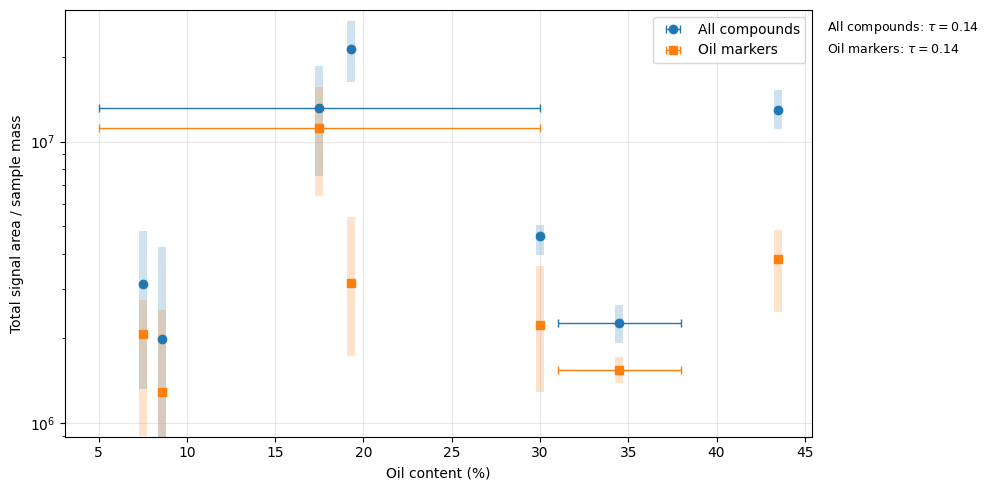

All compounds: Kendall's tau: -0.23809523809523814, p-value: 0.5619047619047619
Ageing markers: Kendall's tau: -0.04761904761904762, p-value: 1.0


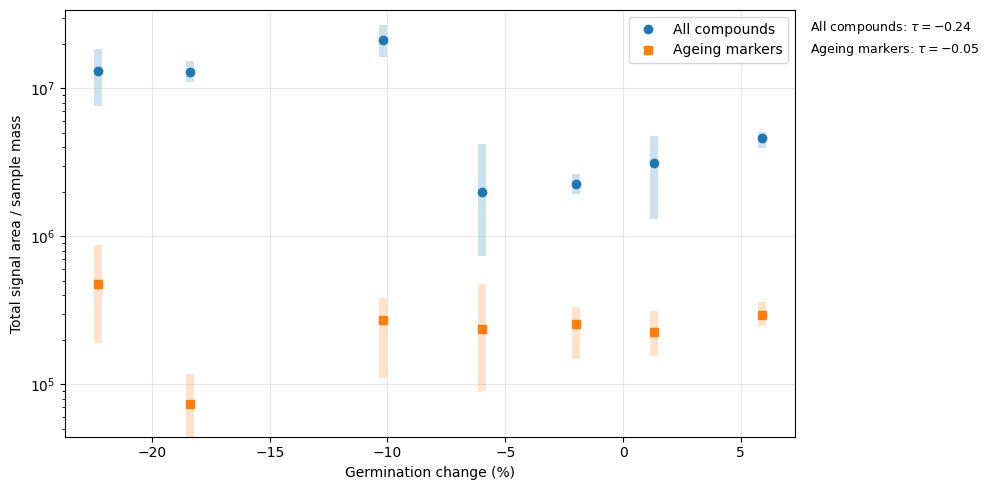

All compounds: Kendall's tau: 0.14285714285714288, p-value: 0.7726190476190476
Oil markers: Kendall's tau: -0.14285714285714288, p-value: 0.7726190476190476


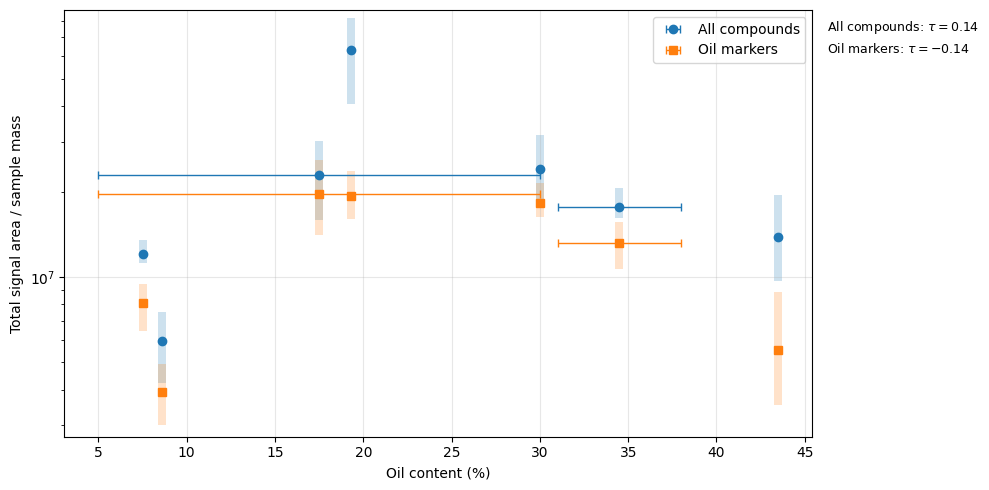

All compounds: Kendall's tau: -0.04761904761904762, p-value: 1.0
Ageing markers: Kendall's tau: 0.4285714285714286, p-value: 0.2388888888888889


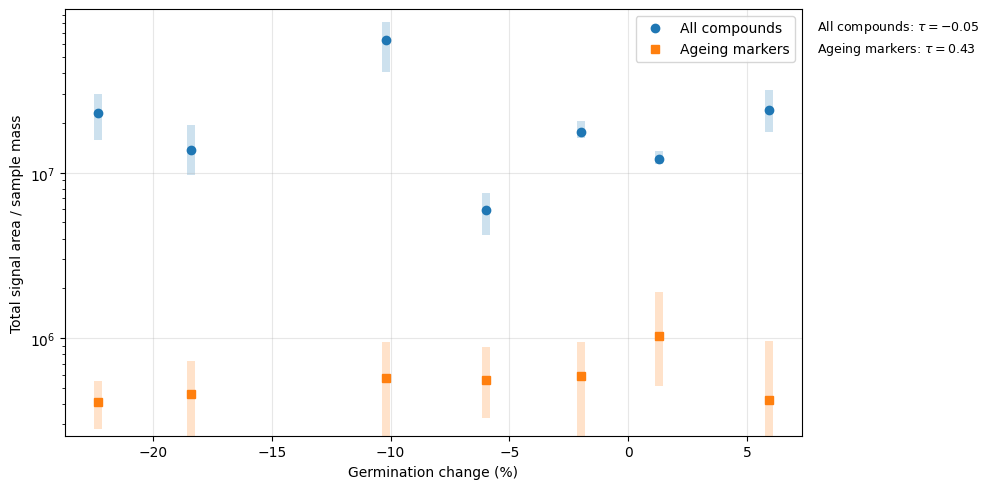

<Axes: xlabel='Germination change (%)', ylabel='Total signal area / sample mass'>

In [52]:
plot_signal_area_vs_trait_one_treatment_all_and_markers(
    all_summary,
    oil_markers_summary,
    treatment="vacuum_whole",
    marker_label="Oil markers",
    x_var="oil_content",
    normalise_by="sample_mass",
)

plot_signal_area_vs_trait_one_treatment_all_and_markers(
    all_summary,
    ageing_markers_summary,
    treatment="vacuum_whole",
    marker_label="Ageing markers",
    x_var="germination_change",
    normalise_by="sample_mass",
)

plot_signal_area_vs_trait_one_treatment_all_and_markers(
    all_summary,
    oil_markers_summary,
    treatment="vacuum_cut",
    marker_label="Oil markers",
    x_var="oil_content",
    normalise_by="sample_mass",
)

plot_signal_area_vs_trait_one_treatment_all_and_markers(
    all_summary,
    ageing_markers_summary,
    treatment="vacuum_cut",
    marker_label="Ageing markers",
    x_var="germination_change",
    normalise_by="sample_mass",
)

In [ ]:
# function to compute Kendall's tau from an existing species×treatment summary dataframe, for a given treatment and choice of seed trait
def kendall_tau_from_summary(
    summary_df,
    treatment,
    x_var="oil_content",                 # "oil_content", "germination_change", "surface_area"
    normalise_by="n_seeds",              # "n_seeds" or "sample_mass"
    treatment_col="treatment",
    oil_content_mean_col="oil_content_mean",
    germination_change_col="germination_change",
    mean_projected_col="mean_projected_surface_area",
    mean_approx_col="mean_approx_surface_area",
    surface_area="approx",
):
    """
    Compute Kendall's tau from an existing species×treatment summary dataframe.
    """

    df = summary_df.loc[summary_df[treatment_col] == treatment].copy()

    if df.empty:
        return np.nan, 0

    # x
    if x_var == "oil_content":
        x = pd.to_numeric(df[oil_content_mean_col], errors="coerce") * 100.0
    elif x_var == "germination_change":
        x = pd.to_numeric(df[germination_change_col], errors="coerce")
    elif x_var == "surface_area":
        if surface_area == "projected":
            x = pd.to_numeric(df[mean_projected_col], errors="coerce")
        elif surface_area == "approx":
            x = pd.to_numeric(df[mean_approx_col], errors="coerce")
        else:
            raise ValueError("surface_area must be 'projected' or 'approx'")
    else:
        raise ValueError("x_var must be 'oil_content', 'germination_change', or 'surface_area'")

    # y
    if normalise_by == "n_seeds":
        y = pd.to_numeric(df["mean_total_area/n_seeds"], errors="coerce")
    elif normalise_by == "sample_mass":
        y = pd.to_numeric(df["mean_total_area/sample_mass"], errors="coerce")
    else:
        raise ValueError("normalise_by must be 'n_seeds' or 'sample_mass'")

    good = np.isfinite(x) & np.isfinite(y)
    n = int(good.sum())

    if n < 3:
        return np.nan, n

    tau, _ = kendalltau(np.asarray(x[good]), np.asarray(y[good]))
    return tau, n

In [ ]:
# Function to perform a permutation test comparing the tau from marker_summary against the tau from all_summary, using random compound subsets to build a null distribution
def permutation_test_marker_summary_vs_all(
    gcms_df,
    seed_area_df,
    seed_traits_df,
    all_summary,
    marker_summary,
    marker_compounds,                
    treatment,
    x_var,
    normalise_by="n_seeds",
    marker_subset_key="norm",         
    compound_name_col="compound_name",
    compound_norm_col="compound_norm",
    treatment_col="treatment",
    species_col="species",
    empty_label="Empty",
    n_permutations=5000,
    random_state=42,
    alternative="two-sided",
    expected_n_replicates=3,
):
    """
    Permutation test comparing:
        tau(marker_summary) - tau(all_summary)

    against a null built from random compound subsets of the same size as the marker set.

    marker_subset_key:
        "names" -> marker_compounds are compound_name values
        "norm"  -> marker_compounds are compound_norm values
    """

    rng = np.random.default_rng(random_state)

    # ----------------------------
    # observed taus from existing summaries
    # ----------------------------
    tau_all, n_all = kendall_tau_from_summary(
        all_summary,
        treatment=treatment,
        x_var=x_var,
        normalise_by=normalise_by,
        treatment_col=treatment_col,
    )

    tau_marker, n_marker = kendall_tau_from_summary(
        marker_summary,
        treatment=treatment,
        x_var=x_var,
        normalise_by=normalise_by,
        treatment_col=treatment_col,
    )

    if not np.isfinite(tau_all):
        raise ValueError(f"Could not compute tau for all_summary at treatment={treatment!r}.")
    if not np.isfinite(tau_marker):
        raise ValueError(f"Could not compute tau for marker_summary at treatment={treatment!r}.")

    delta_obs = tau_marker - tau_all

    # ----------------------------
    # define compound universe for this treatment
    # ----------------------------
    d = gcms_df.loc[gcms_df[species_col] != empty_label].copy()
    d = d.loc[d[treatment_col] == treatment].copy()

    if marker_subset_key == "names":
        universe = pd.Index(sorted(d[compound_name_col].dropna().astype(str).unique()))
        marker_compounds = [str(x) for x in marker_compounds if pd.notna(x)]
    elif marker_subset_key == "norm":
        universe = pd.Index(sorted(d[compound_norm_col].dropna().astype(str).unique()))
        marker_compounds = [str(x) for x in marker_compounds if pd.notna(x)]
    else:
        raise ValueError("marker_subset_key must be 'names' or 'norm'")

    universe_norm = set(
        gcms_df.loc[gcms_df["treatment"] == "vacuum_whole", "compound_norm"]
        .dropna().astype(str)
    )

    marker_compounds_present = [x for x in marker_compounds if x in set(universe)]
    k = len(marker_compounds_present)

    if k == 0:
        raise ValueError("None of the supplied marker compounds are present in this treatment.")
    if k >= len(universe):
        raise ValueError("Marker set must be smaller than the available compound universe.")

    # ----------------------------
    # permutation null
    # ----------------------------
    null_taus = np.empty(n_permutations, dtype=float)
    null_deltas = np.empty(n_permutations, dtype=float)

    universe_arr = np.asarray(universe)

    for i in range(n_permutations):
        rand_subset = rng.choice(universe_arr, size=k, replace=False)

        if marker_subset_key == "names":
            subset = {"names": list(rand_subset), "match": "exact"}
        else:
            subset = {"norm": list(rand_subset), "match": "exact"}

        rand_summary = make_species_treatment_summary(
            gcms_df,
            seed_area_df,
            seed_traits_df,
            subset=subset,
            expected_n_replicates=expected_n_replicates,
        )

        tau_rand, _ = kendall_tau_from_summary(
            rand_summary,
            treatment=treatment,
            x_var=x_var,
            normalise_by=normalise_by,
            treatment_col=treatment_col,
        )

        null_taus[i] = tau_rand
        null_deltas[i] = tau_rand - tau_all

    # remove any NaN permutations, just in case
    good = np.isfinite(null_deltas)
    null_deltas = null_deltas[good]
    null_taus = null_taus[good]

    if len(null_deltas) == 0:
        raise ValueError("All permutation taus were NaN.")

    # ----------------------------
    # p-value
    # ----------------------------
    if alternative == "two-sided":
        p_value = (np.sum(np.abs(null_deltas) >= abs(delta_obs)) + 1) / (len(null_deltas) + 1)
    elif alternative == "greater":
        # tests whether marker set gives a larger tau than expected
        p_value = (np.sum(null_deltas >= delta_obs) + 1) / (len(null_deltas) + 1)
    elif alternative == "less":
        p_value = (np.sum(null_deltas <= delta_obs) + 1) / (len(null_deltas) + 1)
    else:
        raise ValueError("alternative must be 'two-sided', 'greater', or 'less'")

    return {
        "treatment": treatment,
        "x_var": x_var,
        "normalise_by": normalise_by,
        "tau_all": tau_all,
        "tau_marker": tau_marker,
        "delta_obs": delta_obs,
        "n_all": n_all,
        "n_marker": n_marker,
        "n_marker_compounds": k,
        "n_universe_compounds": len(universe),
        "null_taus": null_taus,
        "null_deltas": null_deltas,
        "p_value": p_value,
    }

def run_marker_permutation_tests(
    gcms_df,
    seed_area_df,
    seed_traits_df,
    *,
    all_summary,
    oil_markers_summary,
    ageing_markers_summary,
    oil_marker_compounds,
    ageing_marker_compounds,
    treatment,
    normalise_by="n_seeds",
    marker_subset_key="names",
    n_permutations=5000,
    random_state=42,
):
    """
    Runs:
      1) oil markers vs all compounds against oil content
      2) ageing markers vs all compounds against germination change
    """

    oil_result = permutation_test_marker_summary_vs_all(
        gcms_df,
        seed_area_df,
        seed_traits_df,
        all_summary=all_summary,
        marker_summary=oil_markers_summary,
        marker_compounds=oil_marker_compounds,
        treatment=treatment,
        x_var="oil_content",
        normalise_by=normalise_by,
        marker_subset_key=marker_subset_key,
        n_permutations=n_permutations,
        random_state=random_state,
        alternative="two-sided",
    )

    ageing_result = permutation_test_marker_summary_vs_all(
        gcms_df,
        seed_area_df,
        seed_traits_df,
        all_summary=all_summary,
        marker_summary=ageing_markers_summary,
        marker_compounds=ageing_marker_compounds,
        treatment=treatment,
        x_var="germination_change",
        normalise_by=normalise_by,
        marker_subset_key=marker_subset_key,
        n_permutations=n_permutations,
        random_state=random_state + 1,
        alternative="two-sided",
    )

    return oil_result, ageing_result

In [57]:
surface_area_all_compounds_vs_oil_markers = permutation_test_marker_summary_vs_all(
    gcms_df,
    seed_area_df,
    seed_traits_df,
    all_summary=all_summary,
    marker_summary=oil_markers_summary,
    marker_compounds=oil_markers,
    treatment="vacuum_whole",
    x_var="surface_area",
    normalise_by="sample_mass",
    n_permutations=1000,
    random_state=42,
    alternative="two-sided",
)

print("Permutation test: surface area for all compounds vs oil markers (vacuum whole):")
print("tau_all      =", surface_area_all_compounds_vs_oil_markers["tau_all"])
print("tau_markers  =", surface_area_all_compounds_vs_oil_markers["tau_marker"])
print("delta_obs    =", surface_area_all_compounds_vs_oil_markers["delta_obs"])
print("mean tau_rand =", surface_area_all_compounds_vs_oil_markers["null_taus"].mean())
print("p_value      =", surface_area_all_compounds_vs_oil_markers["p_value"])


surface_area_all_compounds_vs_ageing_markers = permutation_test_marker_summary_vs_all(
    gcms_df,
    seed_area_df,
    seed_traits_df,
    all_summary=all_summary,
    marker_summary=ageing_markers_summary,
    marker_compounds=ageing_markers,
    treatment="vacuum_whole",
    x_var="surface_area",
    normalise_by="sample_mass",
    n_permutations=1000,
    random_state=42,
    alternative="two-sided",
)

print("\nPermutation test: surface area for all compounds vs ageing markers (vacuum whole):")
print("tau_all      =", surface_area_all_compounds_vs_ageing_markers["tau_all"])
print("tau_markers  =", surface_area_all_compounds_vs_ageing_markers["tau_marker"])
print("delta_obs    =", surface_area_all_compounds_vs_ageing_markers["delta_obs"])
print("mean tau_rand =", surface_area_all_compounds_vs_ageing_markers["null_taus"].mean())
print("p_value      =", surface_area_all_compounds_vs_ageing_markers["p_value"])

Permutation test: surface area for all compounds vs oil markers (vacuum whole):
tau_all      = -0.04761904761904762
tau_markers  = -0.23809523809523814
delta_obs    = -0.19047619047619052
mean tau_rand = -0.13580952380952382
p_value      = 0.39760239760239763

Permutation test: surface area for all compounds vs ageing markers (vacuum whole):
tau_all      = -0.04761904761904762
tau_markers  = 0.33333333333333337
delta_obs    = 0.380952380952381
mean tau_rand = -0.10882135812439292
p_value      = 0.15384615384615385


In [58]:
oil_result, ageing_result = run_marker_permutation_tests(
    gcms_df,
    seed_area_df,
    seed_traits_df,
    all_summary=all_summary,
    oil_markers_summary=oil_markers_summary,
    ageing_markers_summary=ageing_markers_summary,
    oil_marker_compounds=oil_markers,
    ageing_marker_compounds=ageing_markers,
    treatment="vacuum_whole",
    normalise_by="sample_mass",
    marker_subset_key="norm",
    n_permutations=1000,
    random_state=42,
)

print("Permutation test: oil content for all compounds vs oil markers (vacuum whole):")
print("tau_all      =", oil_result["tau_all"])
print("tau_markers  =", oil_result["tau_marker"])
print("delta_obs    =", oil_result["delta_obs"])
print("mean tau_rand =", oil_result["null_taus"].mean())
print("p_value      =", oil_result["p_value"])

print("\nPermutation test: germination change for all compounds vs ageing markers (vacuum whole):")
print("tau_all      =", ageing_result["tau_all"])
print("tau_markers  =", ageing_result["tau_marker"])
print("delta_obs    =", ageing_result["delta_obs"])
print("mean tau_rand =", ageing_result["null_taus"].mean())
print("p_value      =", ageing_result["p_value"])

Permutation test: oil content for all compounds vs oil markers (vacuum whole):
tau_all      = 0.14285714285714288
tau_markers  = 0.14285714285714288
delta_obs    = 0.0
mean tau_rand = 0.11923809523809524
p_value      = 1.0

Permutation test: germination change for all compounds vs ageing markers (vacuum whole):
tau_all      = -0.23809523809523814
tau_markers  = -0.04761904761904762
delta_obs    = 0.19047619047619052
mean tau_rand = -0.28841009918481514
p_value      = 0.3276723276723277


In [ ]:
# Function to plot signal area against seed trait for one treatment, comparing all compounds with oil and ageing markers
def plot_signal_area_vs_trait_one_treatment_all_oil_and_ageing(
    summary_df_all,
    summary_df_oil,
    summary_df_ageing,
    treatment,
    all_label="All compounds",
    oil_label="Oil markers",
    ageing_label="Ageing markers",
    normalise_by="n_seeds",
    x_var="surface_area",               # "surface_area", "oil_content", "germination_change"
    surface_area="approx",
    x_axis_surface_areas="individual",  # only used if x_var="surface_area"
    species_col="species",
    treatment_col="treatment",

    # surface-area cols
    mean_projected_col="mean_projected_surface_area",
    std_projected_col="std_projected_surface_area",
    mean_approx_col="mean_approx_surface_area",
    std_approx_col="std_approx_surface_area",

    # replicate-count cols
    mean_n_seeds_col="mean_n_seeds",
    std_n_seeds_col="std_n_seeds",

    # seed-trait cols
    oil_content_low_col="oil_content_low",
    oil_content_high_col="oil_content_high",
    oil_content_mean_col="oil_content_mean",
    germination_change_col="germination_change",

    ax=None,
    show=True,
    markersize=6,
    band_alpha=0.22,
    yscale="log",
    annotate_species=False,

    # styles
    all_marker="o",
    oil_marker="s",
    ageing_marker="^",
    all_colour="C0",
    oil_colour="C1",
    ageing_colour="C2",
):
    """
    Plot one treatment in a single panel, overplotting:
      - all compounds
      - oil markers
      - ageing markers

    Each summary dataframe should already contain the species×treatment summaries.
    """

    # ----------------------------
    # Filter to one treatment
    # ----------------------------
    df_all = summary_df_all.loc[summary_df_all[treatment_col] == treatment].copy()
    df_oil = summary_df_oil.loc[summary_df_oil[treatment_col] == treatment].copy()
    df_age = summary_df_ageing.loc[summary_df_ageing[treatment_col] == treatment].copy()

    if df_all.empty:
        raise ValueError(f"No rows found for treatment={treatment!r} in summary_df_all.")
    if df_oil.empty:
        raise ValueError(f"No rows found for treatment={treatment!r} in summary_df_oil.")
    if df_age.empty:
        raise ValueError(f"No rows found for treatment={treatment!r} in summary_df_ageing.")

    # ----------------------------
    # Choose y-axis
    # ----------------------------
    if normalise_by == "n_seeds":
        y_col = "mean_total_area/n_seeds"
        y_min_col = "min_total_area/n_seeds"
        y_max_col = "max_total_area/n_seeds"
        ylabel = "Total signal area per seed"
    elif normalise_by == "sample_mass":
        y_col = "mean_total_area/sample_mass"
        y_min_col = "min_total_area/sample_mass"
        y_max_col = "max_total_area/sample_mass"
        ylabel = "Total signal area / sample mass"
    else:
        raise ValueError("normalise_by must be 'n_seeds' or 'sample_mass'")

    # ----------------------------
    # Figure / axes
    # ----------------------------
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))
    else:
        fig = ax.figure

    # ----------------------------
    # X-axis helper
    # ----------------------------
    def get_x_and_xerr(df_plot):
        if x_var == "surface_area":
            if surface_area == "projected":
                area_mean_col = mean_projected_col
                area_std_col = std_projected_col
                area_label = "projected"
            elif surface_area == "approx":
                area_mean_col = mean_approx_col
                area_std_col = std_approx_col
                area_label = "approx."
            else:
                raise ValueError("surface_area must be 'projected' or 'approx'")

            area_mean = pd.to_numeric(df_plot[area_mean_col], errors="coerce")
            area_std = pd.to_numeric(df_plot[area_std_col], errors="coerce")

            if x_axis_surface_areas == "individual":
                x = area_mean
                xerr = area_std
                xlabel_local = f"Mean {area_label} seed surface area / mm$^2$"

            elif x_axis_surface_areas == "total":
                n_mean = pd.to_numeric(df_plot[mean_n_seeds_col], errors="coerce")

                if std_n_seeds_col in df_plot.columns:
                    n_std = pd.to_numeric(df_plot[std_n_seeds_col], errors="coerce").fillna(0.0)
                else:
                    n_std = pd.Series(0.0, index=df_plot.index)

                x = area_mean * n_mean

                rel_area = np.where(
                    (area_mean > 0) & np.isfinite(area_mean),
                    area_std / area_mean,
                    0.0
                )
                rel_n = np.where(
                    (n_mean > 0) & np.isfinite(n_mean),
                    n_std / n_mean,
                    0.0
                )
                xerr = x * np.sqrt(rel_area**2 + rel_n**2)

                xlabel_local = f"Total {area_label} seed surface area per replicate / mm$^2$"

            else:
                raise ValueError("x_axis_surface_areas must be 'individual' or 'total'")

            return x, xerr, xlabel_local

        elif x_var == "oil_content":
            x_mean = pd.to_numeric(df_plot[oil_content_mean_col], errors="coerce") * 100
            x_low = pd.to_numeric(df_plot[oil_content_low_col], errors="coerce") * 100
            x_high = pd.to_numeric(df_plot[oil_content_high_col], errors="coerce") * 100

            xerr_low = np.clip(x_mean - x_low, 0, None)
            xerr_high = np.clip(x_high - x_mean, 0, None)
            xerr = np.vstack([xerr_low, xerr_high])

            xlabel_local = "Oil content (%)"
            return x_mean, xerr, xlabel_local

        elif x_var == "germination_change":
            x = pd.to_numeric(df_plot[germination_change_col], errors="coerce")
            xerr = None
            xlabel_local = "Germination change (%)"
            return x, xerr, xlabel_local

        else:
            raise ValueError("x_var must be 'surface_area', 'oil_content', or 'germination_change'")

    # ----------------------------
    # Plot helper
    # ----------------------------
    def plot_dataset(df_plot, label, colour, marker, tau_ypos):
        x, xerr, xlabel_local = get_x_and_xerr(df_plot)
        y = pd.to_numeric(df_plot[y_col], errors="coerce")
        y_min = pd.to_numeric(df_plot[y_min_col], errors="coerce")
        y_max = pd.to_numeric(df_plot[y_max_col], errors="coerce")

        order = np.argsort(np.where(np.isfinite(x), x, np.inf))
        df_plot = df_plot.iloc[order]
        x = np.asarray(x)[order]
        y = np.asarray(y)[order]
        y_min = np.asarray(y_min)[order]
        y_max = np.asarray(y_max)[order]

        if xerr is not None:
            xerr = np.asarray(xerr)
            if xerr.ndim == 2:
                xerr = xerr[:, order]
            else:
                xerr = xerr[order]

        ax.errorbar(
            x, y,
            xerr=xerr,
            yerr=None,
            fmt=marker,
            capsize=3 if xerr is not None else 0,
            elinewidth=1,
            markersize=markersize,
            color=colour,
            label=label,
            zorder=3,
        )

        tau, p_value = np.nan, np.nan
        good = np.isfinite(x) & np.isfinite(y)
        if good.sum() > 2:
            tau, p_value = kendalltau(x[good], y[good])
            ax.text(
                1.02, tau_ypos,
                f"{label}: $\\tau = {tau:.2f}$",
                transform=ax.transAxes,
                fontsize=9,
                color='black',
            )

        print(f"{label}: tau={tau}, p={p_value}")

        if annotate_species:
            species_vals = df_plot[species_col].astype(str).values
            for xi, yi, sp in zip(x, y, species_vals):
                if np.isfinite(xi) and np.isfinite(yi):
                    ax.annotate(
                        sp,
                        (xi, yi),
                        xytext=(4, 4),
                        textcoords="offset points",
                        fontsize=8,
                        color=colour,
                    )

        return xlabel_local, x, y_min, y_max

    # ----------------------------
    # First pass: points/error bars
    # ----------------------------
    xlabel = None

    xlabel, x_all, y_min_all, y_max_all = plot_dataset(
        df_all, all_label, all_colour, all_marker, tau_ypos=0.95
    )
    _, x_oil, y_min_oil, y_max_oil = plot_dataset(
        df_oil, oil_label, oil_colour, oil_marker, tau_ypos=0.90
    )
    _, x_age, y_min_age, y_max_age = plot_dataset(
        df_age, ageing_label, ageing_colour, ageing_marker, tau_ypos=0.85
    )

    ax.set_xlabel(xlabel or "Trait value")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend()

    if yscale is not None:
        ax.set_yscale(yscale)

    # ----------------------------
    # Band width in x units
    # ----------------------------
    fig.canvas.draw()

    marker_diameter_points = markersize
    marker_diameter_pixels = marker_diameter_points * fig.dpi / 72.0

    ymin_ax, ymax_ax = ax.get_ylim()
    if yscale == "log":
        ymid = np.sqrt(ymin_ax * ymax_ax)
    else:
        ymid = 0.5 * (ymin_ax + ymax_ax)

    ymid_disp = ax.transData.transform((0, ymid))[1]
    x0_disp = ax.transData.transform((0, ymin_ax))[0]
    x1_disp = x0_disp + marker_diameter_pixels

    x0_data = ax.transData.inverted().transform((x0_disp, ymid_disp))[0]
    x1_data = ax.transData.inverted().transform((x1_disp, ymid_disp))[0]
    band_width = abs(x1_data - x0_data)

    if yscale == "log":
        ymin_ax *= 0.8
        ymax_ax *= 1.2
    else:
        pad = 0.05 * (ymax_ax - ymin_ax)
        ymin_ax -= pad
        ymax_ax += pad

    ax.set_ylim(ymin_ax, ymax_ax)

    # ----------------------------
    # Second pass: min-max vertical bands
    # ----------------------------
    def draw_bands(x, y_min, y_max, colour):
        for xi, ylo, yhi in zip(x, y_min, y_max):
            if np.isfinite(xi) and np.isfinite(ylo) and np.isfinite(yhi):
                if yhi < ylo:
                    ylo, yhi = yhi, ylo
                rect = Rectangle(
                    (xi - band_width / 2, ylo),
                    band_width,
                    yhi - ylo,
                    facecolor=colour,
                    edgecolor="none",
                    alpha=band_alpha,
                    zorder=1,
                )
                ax.add_patch(rect)

    draw_bands(x_all, y_min_all, y_max_all, all_colour)
    draw_bands(x_oil, y_min_oil, y_max_oil, oil_colour)
    draw_bands(x_age, y_min_age, y_max_age, ageing_colour)

    # keep points above patches
    for line in ax.lines:
        line.set_zorder(3)

    plt.tight_layout()

    #plt.savefig(f'Plots/signal_area_per_unit_mass_vs_{x_var}_{treatment}_compound_types_comparison.png', dpi=300, bbox_inches='tight')

    if show:
        plt.show()

    return ax

All compounds: tau=-0.04761904761904762, p=1.0
Oil markers: tau=-0.23809523809523814, p=0.5619047619047619
Ageing markers: tau=0.33333333333333337, p=0.3813492063492063


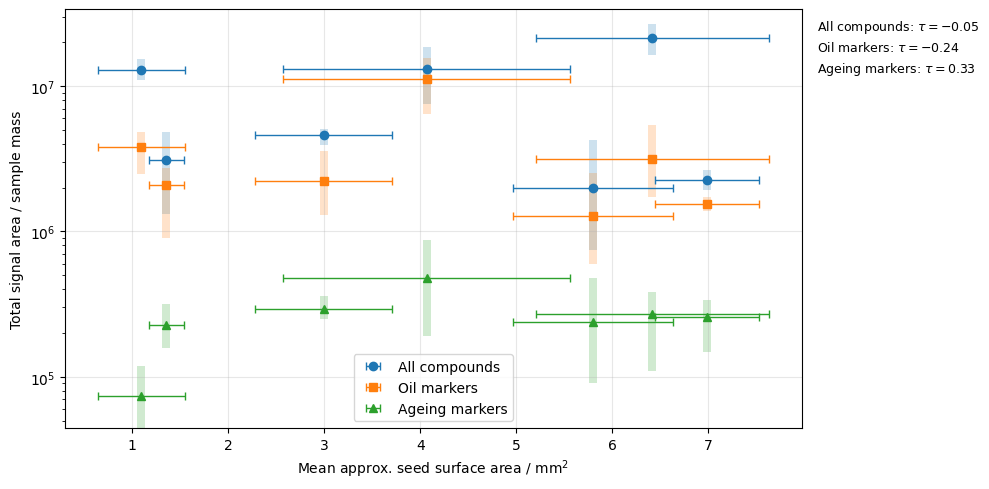

<Axes: xlabel='Mean approx. seed surface area / mm$^2$', ylabel='Total signal area / sample mass'>

In [ ]:
plot_signal_area_vs_trait_one_treatment_all_oil_and_ageing(
    all_summary,
    oil_markers_summary,
    ageing_markers_summary,
    treatment="vacuum_whole",
    normalise_by="sample_mass",
    x_var="surface_area",
    surface_area="approx",
    x_axis_surface_areas="individual",
)

In [ ]:
# Plot signal area and fraction vs trait for one treatment
def plot_signal_and_fraction_vs_trait(
    gcms_df,
    summary_df_all,
    summary_df_oil,
    summary_df_ageing,
    treatment,
    oil_markers,
    ageing_markers,

    # choose which marker sets to include
    include_oil=True,
    include_ageing=True,

    # GC-MS columns
    species_col="species",
    treatment_col="treatment",
    replicate_col="replicate",
    compound_col="compound_norm",
    signal_col_per_seed="area/n_seeds",
    signal_col_per_mass="area/sample_mass",

    # optional filtering
    drop_empty_species=True,
    empty_label="Empty",

    # trait / x-axis options
    x_var="surface_area",               # "surface_area", "oil_content", "germination_change"
    surface_area="approx",              # "approx" or "projected"
    x_axis_surface_areas="individual",  # "individual" or "total"
    normalise_by="sample_mass",         # "sample_mass" or "n_seeds"

    # summary_df columns
    mean_projected_col="mean_projected_surface_area",
    std_projected_col="std_projected_surface_area",
    mean_approx_col="mean_approx_surface_area",
    std_approx_col="std_approx_surface_area",
    mean_n_seeds_col="mean_n_seeds",
    std_n_seeds_col="std_n_seeds",
    oil_content_low_col="oil_content_low",
    oil_content_high_col="oil_content_high",
    oil_content_mean_col="oil_content_mean",
    germination_change_col="germination_change",

    # plotting
    figsize=(10, 6),
    show=True,
    markersize=6,
    band_alpha=0.22,
    annotate_species=False,
    yscale_top="log",

    # styles
    all_label="All compounds",
    oil_label="Oil markers",
    ageing_label="Ageing markers",
    all_marker="o",
    oil_marker="s",
    ageing_marker="^",
    all_colour="C0",
    oil_colour="C1",
    ageing_colour="C2",
):
    """
    Two-panel figure for one treatment.

    Top panel:
        absolute signal vs trait for all compounds plus any selected marker summaries

    Bottom panel:
        fraction of total signal vs trait for the selected marker sets, where fractions are
        computed at replicate level first from gcms_df, then summarised by species.
    """

    if not include_oil and not include_ageing:
        raise ValueError("At least one of include_oil or include_ageing must be True.")

    # ----------------------------
    # Choose signal column names
    # ----------------------------
    if normalise_by == "n_seeds":
        summary_mean_col = "mean_total_area/n_seeds"
        summary_min_col = "min_total_area/n_seeds"
        summary_max_col = "max_total_area/n_seeds"
        signal_col = signal_col_per_seed
        ylabel_top = "Total signal area per seed"
    elif normalise_by == "sample_mass":
        summary_mean_col = "mean_total_area/sample_mass"
        summary_min_col = "min_total_area/sample_mass"
        summary_max_col = "max_total_area/sample_mass"
        signal_col = signal_col_per_mass
        ylabel_top = "Total signal area / sample mass"
    else:
        raise ValueError("normalise_by must be 'n_seeds' or 'sample_mass'")

    # ----------------------------
    # Filter summary dataframes
    # ----------------------------
    def prep_summary(df, name):
        out = df.loc[df[treatment_col] == treatment].copy()
        if drop_empty_species:
            out = out.loc[out[species_col] != empty_label].copy()
        if out.empty:
            raise ValueError(f"No rows found for treatment={treatment!r} in {name}.")
        return out

    df_all = prep_summary(summary_df_all, "summary_df_all")
    df_oil = prep_summary(summary_df_oil, "summary_df_oil") if include_oil else None
    df_age = prep_summary(summary_df_ageing, "summary_df_ageing") if include_ageing else None

    # ----------------------------
    # X-axis helper
    # ----------------------------
    def get_x_and_xerr(df_plot):
        if x_var == "surface_area":
            if surface_area == "projected":
                area_mean_col = mean_projected_col
                area_std_col = std_projected_col
                area_label = "projected"
            elif surface_area == "approx":
                area_mean_col = mean_approx_col
                area_std_col = std_approx_col
                area_label = "approx."
            else:
                raise ValueError("surface_area must be 'projected' or 'approx'")

            area_mean = pd.to_numeric(df_plot[area_mean_col], errors="coerce")
            area_std = pd.to_numeric(df_plot[area_std_col], errors="coerce")

            if x_axis_surface_areas == "individual":
                x = area_mean
                xerr = area_std
                xlabel_local = f"Mean {area_label} seed surface area / mm$^2$"

            elif x_axis_surface_areas == "total":
                n_mean = pd.to_numeric(df_plot[mean_n_seeds_col], errors="coerce")

                if std_n_seeds_col in df_plot.columns:
                    n_std = pd.to_numeric(df_plot[std_n_seeds_col], errors="coerce").fillna(0.0)
                else:
                    n_std = pd.Series(0.0, index=df_plot.index)

                x = area_mean * n_mean

                rel_area = np.where(
                    (area_mean > 0) & np.isfinite(area_mean),
                    area_std / area_mean,
                    0.0
                )
                rel_n = np.where(
                    (n_mean > 0) & np.isfinite(n_mean),
                    n_std / n_mean,
                    0.0
                )
                xerr = x * np.sqrt(rel_area**2 + rel_n**2)
                xlabel_local = f"Total {area_label} seed surface area per replicate / mm$^2$"

            else:
                raise ValueError("x_axis_surface_areas must be 'individual' or 'total'")

            return x, xerr, xlabel_local

        elif x_var == "oil_content":
            x_mean = pd.to_numeric(df_plot[oil_content_mean_col], errors="coerce") * 100
            x_low = pd.to_numeric(df_plot[oil_content_low_col], errors="coerce") * 100
            x_high = pd.to_numeric(df_plot[oil_content_high_col], errors="coerce") * 100

            xerr_low = np.clip(x_mean - x_low, 0, None)
            xerr_high = np.clip(x_high - x_mean, 0, None)
            xerr = np.vstack([xerr_low, xerr_high])
            xlabel_local = "Oil content (%)"
            return x_mean, xerr, xlabel_local

        elif x_var == "germination_change":
            x = pd.to_numeric(df_plot[germination_change_col], errors="coerce")
            xerr = None
            xlabel_local = "Germination change (%)"
            return x, xerr, xlabel_local

        else:
            raise ValueError("x_var must be 'surface_area', 'oil_content', or 'germination_change'")

    # ----------------------------
    # Figure / axes
    # ----------------------------
    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, figsize=figsize, sharex=True,
        gridspec_kw={"height_ratios": [4, 1], "hspace": 0.2},
    )

    # ----------------------------
    # Top panel helper
    # ----------------------------
    def plot_absolute_dataset(ax, df_plot, label, colour, marker, tau_ypos):
        x, xerr, xlabel_local = get_x_and_xerr(df_plot)
        y = pd.to_numeric(df_plot[summary_mean_col], errors="coerce")
        y_min = pd.to_numeric(df_plot[summary_min_col], errors="coerce")
        y_max = pd.to_numeric(df_plot[summary_max_col], errors="coerce")

        order = np.argsort(np.where(np.isfinite(x), x, np.inf))
        df_ord = df_plot.iloc[order]
        x = np.asarray(x)[order]
        y = np.asarray(y)[order]
        y_min = np.asarray(y_min)[order]
        y_max = np.asarray(y_max)[order]

        if xerr is not None:
            xerr = np.asarray(xerr)
            if xerr.ndim == 2:
                xerr = xerr[:, order]
            else:
                xerr = xerr[order]

        ax.errorbar(
            x, y,
            xerr=xerr,
            yerr=None,
            fmt=marker,
            capsize=3 if xerr is not None else 0,
            elinewidth=1,
            markersize=markersize,
            color=colour,
            label=label,
            zorder=3,
        )

        tau, p_value = np.nan, np.nan
        good = np.isfinite(x) & np.isfinite(y)
        if good.sum() > 2:
            tau, p_value = kendalltau(x[good], y[good])
            ax.text(
                1.02, tau_ypos,
                f"{label}: $\\tau = {tau:.2f}$",
                transform=ax.transAxes,
                fontsize=9,
                color="black",
            )

        print(f"[absolute] {label}: tau={tau}, p={p_value}")

        if annotate_species:
            species_vals = df_ord[species_col].astype(str).values
            for xi, yi, sp in zip(x, y, species_vals):
                if np.isfinite(xi) and np.isfinite(yi):
                    ax.annotate(
                        sp, (xi, yi),
                        xytext=(4, 4),
                        textcoords="offset points",
                        fontsize=8,
                        color=colour,
                    )

        return xlabel_local, x, y_min, y_max

    # ----------------------------
    # Plot top panel
    # ----------------------------
    xlabel = None
    top_band_data = []

    xlabel, x_all, y_min_all, y_max_all = plot_absolute_dataset(
        ax_top, df_all, all_label, all_colour, all_marker, tau_ypos=0.95
    )
    top_band_data.append((x_all, y_min_all, y_max_all, all_colour))

    current_tau_y = 0.90
    tau_step_top = 0.05

    if include_oil:
        _, x_oil_abs, y_min_oil_abs, y_max_oil_abs = plot_absolute_dataset(
            ax_top, df_oil, oil_label, oil_colour, oil_marker, tau_ypos=current_tau_y
        )
        top_band_data.append((x_oil_abs, y_min_oil_abs, y_max_oil_abs, oil_colour))
        current_tau_y -= tau_step_top

    if include_ageing:
        _, x_age_abs, y_min_age_abs, y_max_age_abs = plot_absolute_dataset(
            ax_top, df_age, ageing_label, ageing_colour, ageing_marker, tau_ypos=current_tau_y
        )
        top_band_data.append((x_age_abs, y_min_age_abs, y_max_age_abs, ageing_colour))

    ax_top.set_ylabel(ylabel_top)
    ax_top.grid(True, alpha=0.3)
    ax_top.legend(loc="center", bbox_to_anchor=(1.12, 0.5))
    if yscale_top is not None:
        ax_top.set_yscale(yscale_top)

    # band width from top axis
    fig.canvas.draw()

    def get_band_width(ax, markersize, yscale=None):
        marker_diameter_points = markersize
        marker_diameter_pixels = marker_diameter_points * fig.dpi / 72.0
        ymin_ax, ymax_ax = ax.get_ylim()

        if yscale == "log":
            ymid = np.sqrt(ymin_ax * ymax_ax)
        else:
            ymid = 0.5 * (ymin_ax + ymax_ax)

        ymid_disp = ax.transData.transform((0, ymid))[1]
        x0_disp = ax.transData.transform((0, ymin_ax))[0]
        x1_disp = x0_disp + marker_diameter_pixels

        x0_data = ax.transData.inverted().transform((x0_disp, ymid_disp))[0]
        x1_data = ax.transData.inverted().transform((x1_disp, ymid_disp))[0]
        return abs(x1_data - x0_data)

    def draw_bands(ax, x, y_min, y_max, colour, band_width):
        for xi, ylo, yhi in zip(x, y_min, y_max):
            if np.isfinite(xi) and np.isfinite(ylo) and np.isfinite(yhi):
                if yhi < ylo:
                    ylo, yhi = yhi, ylo
                rect = Rectangle(
                    (xi - band_width / 2, ylo),
                    band_width,
                    yhi - ylo,
                    facecolor=colour,
                    edgecolor="none",
                    alpha=band_alpha,
                    zorder=1,
                )
                ax.add_patch(rect)

    bw_top = get_band_width(ax_top, markersize, yscale=yscale_top)

    for xvals, ymins, ymaxs, colour in top_band_data:
        draw_bands(ax_top, xvals, ymins, ymaxs, colour, bw_top)

    for line in ax_top.lines:
        line.set_zorder(3)

    # ----------------------------
    # Bottom panel: true replicate-level fractions
    # ----------------------------
    df_gc = gcms_df.loc[gcms_df[treatment_col] == treatment].copy()
    if drop_empty_species:
        df_gc = df_gc.loc[df_gc[species_col] != empty_label].copy()
    if df_gc.empty:
        raise ValueError(f"No GC-MS rows found for treatment={treatment!r}")

    df_gc[signal_col] = pd.to_numeric(df_gc[signal_col], errors="coerce").fillna(0.0)
    df_gc[compound_col] = df_gc[compound_col].astype(str)

    grp_cols = [species_col, treatment_col, replicate_col]

    total_rep = (
        df_gc.groupby(grp_cols, as_index=False)[signal_col]
        .sum()
        .rename(columns={signal_col: "total_signal"})
    )

    rep_df = total_rep.copy()

    if include_oil:
        oil_set = {str(x) for x in oil_markers}
        oil_rep = (
            df_gc.loc[df_gc[compound_col].isin(oil_set)]
            .groupby(grp_cols, as_index=False)[signal_col]
            .sum()
            .rename(columns={signal_col: "oil_signal"})
        )
        rep_df = rep_df.merge(oil_rep, on=grp_cols, how="left")
        rep_df["oil_signal"] = rep_df["oil_signal"].fillna(0.0)
        rep_df["oil_fraction"] = np.where(
            rep_df["total_signal"] > 0,
            rep_df["oil_signal"] / rep_df["total_signal"],
            np.nan,
        )
        rep_df["oil_fraction"] = rep_df["oil_fraction"].clip(0, 1)

    if include_ageing:
        ageing_set = {str(x) for x in ageing_markers}
        ageing_rep = (
            df_gc.loc[df_gc[compound_col].isin(ageing_set)]
            .groupby(grp_cols, as_index=False)[signal_col]
            .sum()
            .rename(columns={signal_col: "ageing_signal"})
        )
        rep_df = rep_df.merge(ageing_rep, on=grp_cols, how="left")
        rep_df["ageing_signal"] = rep_df["ageing_signal"].fillna(0.0)
        rep_df["ageing_fraction"] = np.where(
            rep_df["total_signal"] > 0,
            rep_df["ageing_signal"] / rep_df["total_signal"],
            np.nan,
        )
        rep_df["ageing_fraction"] = rep_df["ageing_fraction"].clip(0, 1)

    agg_dict = {"n_replicates": (replicate_col, "nunique")}
    if include_oil:
        agg_dict.update({
            "mean_oil_fraction": ("oil_fraction", "mean"),
            "min_oil_fraction": ("oil_fraction", "min"),
            "max_oil_fraction": ("oil_fraction", "max"),
        })
    if include_ageing:
        agg_dict.update({
            "mean_ageing_fraction": ("ageing_fraction", "mean"),
            "min_ageing_fraction": ("ageing_fraction", "min"),
            "max_ageing_fraction": ("ageing_fraction", "max"),
        })

    frac_summary = (
        rep_df.groupby([species_col, treatment_col], as_index=False)
        .agg(**agg_dict)
    )

    # use all-summary traits as x-axis source
    trait_df = df_all.copy()

    frac_plot = pd.merge(
        frac_summary,
        trait_df,
        on=[species_col, treatment_col],
        how="inner",
    )

    if frac_plot.empty:
        raise ValueError("No overlapping species between fraction summary and trait summary.")

    def plot_fraction_dataset(ax, df_plot, mean_col, min_col, max_col, label, colour, marker, tau_ypos):
        x, xerr, xlabel_local = get_x_and_xerr(df_plot)
        y = pd.to_numeric(df_plot[mean_col], errors="coerce")
        y_min = pd.to_numeric(df_plot[min_col], errors="coerce")
        y_max = pd.to_numeric(df_plot[max_col], errors="coerce")

        order = np.argsort(np.where(np.isfinite(x), x, np.inf))
        df_ord = df_plot.iloc[order]
        x = np.asarray(x)[order]
        y = np.asarray(y)[order]
        y_min = np.asarray(y_min)[order]
        y_max = np.asarray(y_max)[order]

        if xerr is not None:
            xerr = np.asarray(xerr)
            if xerr.ndim == 2:
                xerr = xerr[:, order]
            else:
                xerr = xerr[order]

        ax.errorbar(
            x, y,
            xerr=xerr,
            yerr=None,
            fmt=marker,
            capsize=3 if xerr is not None else 0,
            elinewidth=1,
            markersize=markersize,
            color=colour,
            label=label,
            zorder=3,
        )

        tau, p_value = np.nan, np.nan
        good = np.isfinite(x) & np.isfinite(y)
        if good.sum() > 2:
            tau, p_value = kendalltau(x[good], y[good])
            ax.text(
                1.02, tau_ypos,
                f"{label}: $\\tau = {tau:.2f}$",
                transform=ax.transAxes,
                fontsize=9,
                color="black",
            )

        print(f"[fraction] {label}: tau={tau}, p={p_value}")

        if annotate_species:
            species_vals = df_ord[species_col].astype(str).values
            for xi, yi, sp in zip(x, y, species_vals):
                if np.isfinite(xi) and np.isfinite(yi):
                    ax.annotate(
                        sp, (xi, yi),
                        xytext=(4, 4),
                        textcoords="offset points",
                        fontsize=8,
                        color=colour,
                    )

        return xlabel_local, x, y_min, y_max

    bottom_band_data = []
    current_tau_y = 0.75
    tau_step_bot = 0.20
    xlabel_bot = None

    if include_oil:
        xlabel_bot, x_oil_frac, y_min_oil_frac, y_max_oil_frac = plot_fraction_dataset(
            ax_bot, frac_plot,
            "mean_oil_fraction", "min_oil_fraction", "max_oil_fraction",
            oil_label, oil_colour, oil_marker, tau_ypos=current_tau_y
        )
        bottom_band_data.append((x_oil_frac, y_min_oil_frac, y_max_oil_frac, oil_colour))
        current_tau_y -= tau_step_bot

    if include_ageing:
        xlabel_bot, x_age_frac, y_min_age_frac, y_max_age_frac = plot_fraction_dataset(
            ax_bot, frac_plot,
            "mean_ageing_fraction", "min_ageing_fraction", "max_ageing_fraction",
            ageing_label, ageing_colour, ageing_marker, tau_ypos=current_tau_y
        )
        bottom_band_data.append((x_age_frac, y_min_age_frac, y_max_age_frac, ageing_colour))

    ax_bot.set_xlabel(xlabel_bot or xlabel or "Trait value")
    ax_bot.set_ylabel("Fraction of total signal")
    ax_bot.set_ylim(0, 1.05)
    ax_bot.grid(True, alpha=0.3)

    bw_bot = get_band_width(ax_bot, markersize, yscale=None)
    for xvals, ymins, ymaxs, colour in bottom_band_data:
        draw_bands(ax_bot, xvals, ymins, ymaxs, colour, bw_bot)

    for line in ax_bot.lines:
        line.set_zorder(3)

    plt.tight_layout()

    #plt.savefig(
     #   f"Plots/signal_area_per_unit_mass_and_fraction_vs_germination_change_{treatment}.png",
      #  bbox_inches="tight",
       # dpi=300,
    #)

    if show:
        plt.show()

    return {
        "fig": fig,
        "ax_top": ax_top,
        "ax_bottom": ax_bot,
        "replicate_fraction_df": rep_df,
        "fraction_summary_df": frac_summary,
    }

[absolute] All compounds: tau=-0.04761904761904762, p=1.0
[absolute] Oil markers: tau=-0.23809523809523814, p=0.5619047619047619
[absolute] Ageing markers: tau=0.33333333333333337, p=0.3813492063492063
[fraction] Oil markers: tau=0.14285714285714288, p=0.7726190476190476
[fraction] Ageing markers: tau=0.23809523809523814, p=0.5619047619047619


/var/folders/1n/rfdxldfd4yj2l9m0wtnby8x8000bzq/T/ipykernel_75193/1326653815.py:516: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


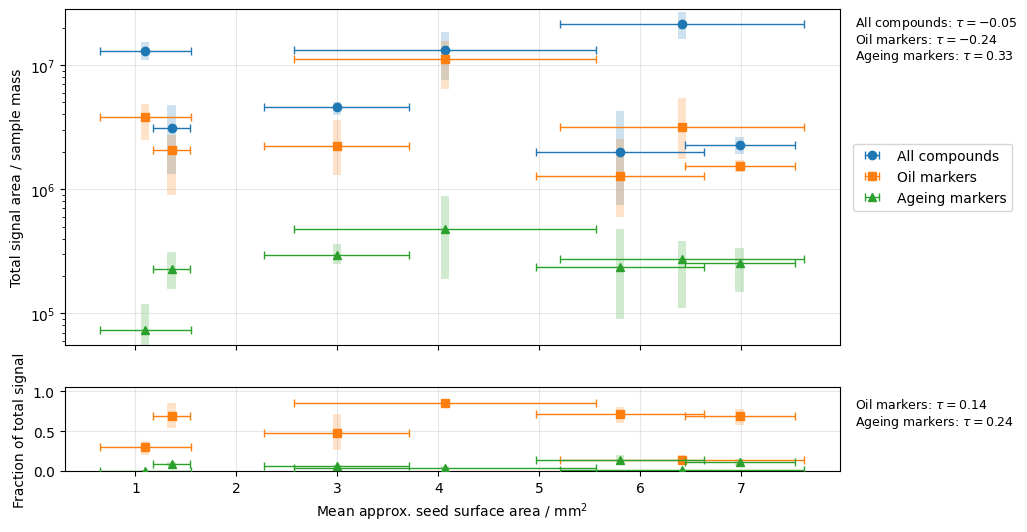

[absolute] All compounds: tau=0.14285714285714288, p=0.7726190476190476
[absolute] Oil markers: tau=0.14285714285714288, p=0.7726190476190476
[fraction] Oil markers: tau=-0.23809523809523814, p=0.5619047619047619


/var/folders/1n/rfdxldfd4yj2l9m0wtnby8x8000bzq/T/ipykernel_75193/1326653815.py:516: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


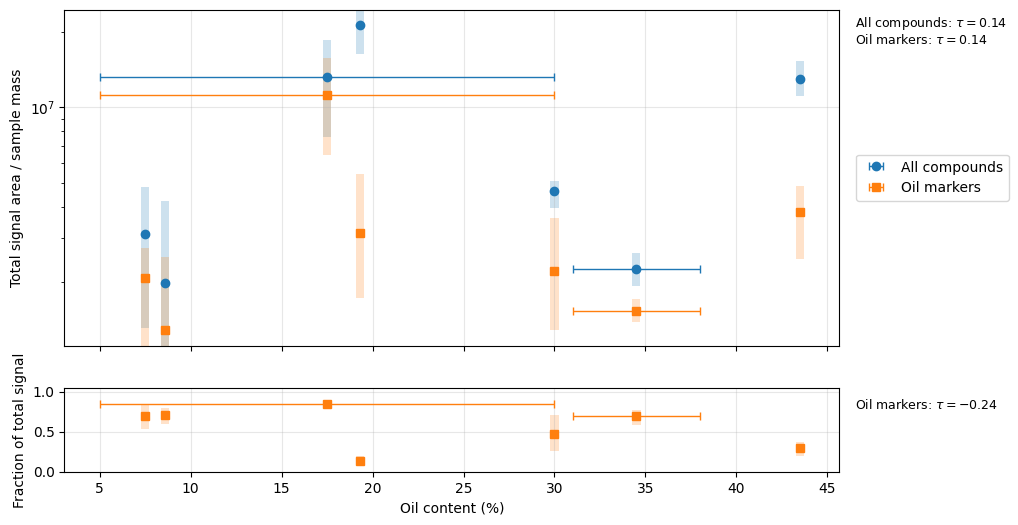

[absolute] All compounds: tau=-0.23809523809523814, p=0.5619047619047619
[absolute] Ageing markers: tau=-0.04761904761904762, p=1.0
[fraction] Ageing markers: tau=0.23809523809523814, p=0.5619047619047619


/var/folders/1n/rfdxldfd4yj2l9m0wtnby8x8000bzq/T/ipykernel_75193/1326653815.py:516: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


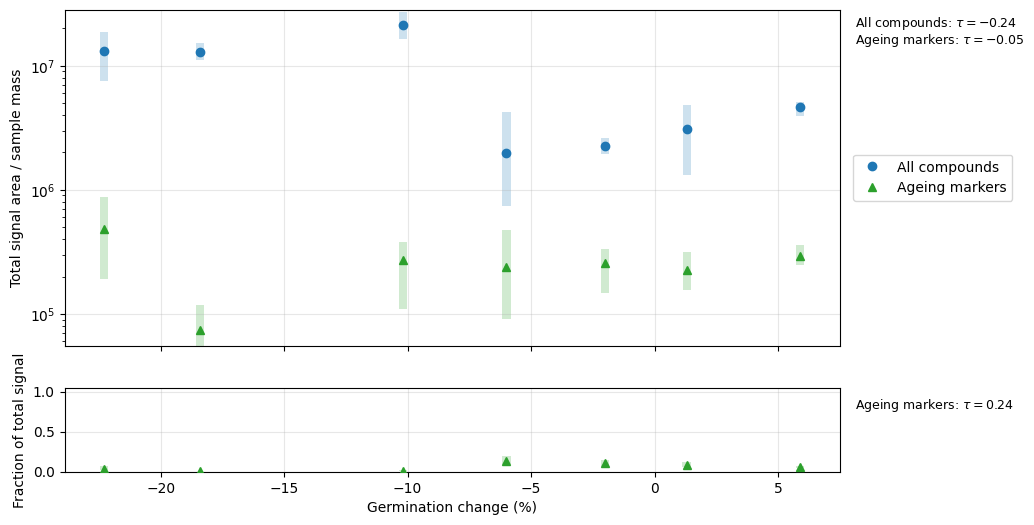

{'fig': <Figure size 1000x600 with 2 Axes>,
 'ax_top': <Axes: ylabel='Total signal area / sample mass'>,
 'ax_bottom': <Axes: xlabel='Germination change (%)', ylabel='Fraction of total signal'>,
 'replicate_fraction_df':                           species     treatment  replicate  total_signal  \
 0                   Daucus carota  vacuum_whole          1  2.688539e+07   
 1                   Daucus carota  vacuum_whole          2  1.631880e+07   
 2                   Daucus carota  vacuum_whole          3  2.054097e+07   
 3                 Ficus sycomorus  vacuum_whole          1  7.573141e+06   
 4                 Ficus sycomorus  vacuum_whole          3  1.334671e+07   
 5                 Ficus sycomorus  vacuum_whole          4  1.857681e+07   
 6                Lactuca serriola  vacuum_whole          1  1.926379e+06   
 7                Lactuca serriola  vacuum_whole          2  2.220023e+06   
 8                Lactuca serriola  vacuum_whole          4  2.628857e+06   
 9   Mesem

In [59]:
plot_signal_and_fraction_vs_trait(
    gcms_df,
    all_summary,
    oil_markers_summary,
    ageing_markers_summary,
    treatment="vacuum_whole",
    oil_markers=oil_markers,
    ageing_markers=ageing_markers,
    normalise_by="sample_mass",
    x_var="surface_area",
)

plot_signal_and_fraction_vs_trait(
    gcms_df,
    all_summary,
    oil_markers_summary,
    ageing_markers_summary,
    treatment="vacuum_whole",
    oil_markers=oil_markers,
    ageing_markers=ageing_markers,
    normalise_by="sample_mass",
    x_var="oil_content",
    include_ageing=False
)

plot_signal_and_fraction_vs_trait(
    gcms_df,
    all_summary,
    oil_markers_summary,
    ageing_markers_summary,
    treatment="vacuum_whole",
    oil_markers=oil_markers,
    ageing_markers=ageing_markers,
    normalise_by="sample_mass",
    x_var="germination_change",
    include_oil=False
)

In [ ]:
# For each common compound, plot compound signal vs trait across species
def plot_compound_signal_vs_trait(
    gcms_df,
    seed_area_df,
    seed_traits_df,
    treatment: str,

    # GC columns
    species_col_gc: str = "species",
    treatment_col: str = "treatment",
    replicate_col: str = "replicate",
    compound_col: str = "compound_name",

    # GC signal columns (already normalised per row)
    signal_col_per_seed: str = "area/n_seeds",
    signal_col_per_mass: str = "area/sample_mass",
    normalise_by: str = "n_seeds",          # "n_seeds" or "sample_mass"

    # x-axis choice
    x_var: str = "surface_area",            # "surface_area", "oil_content", "germination_change"

    # Area columns
    species_col_area: str = "species",
    surface_area: str = "approx",        # "projected" or "approx"
    projected_area_col: str = "projected_surface_area/mm^2",
    approx_area_col: str = "approx_surface_area/mm^2",

    # Trait columns
    species_col_traits: str = "species",
    oil_content_low_col: str = "oil_content_low",
    oil_content_high_col: str = "oil_content_high",
    oil_content_mean_col: str = "oil_content_mean",
    germination_change_col: str = "germination_change",

    # Filtering
    min_species: int = 3,
    expected_n_replicates: int = 3,

    # Plot options
    xerr_on: bool = False,
    logy: bool = True,
    show_regression: bool = False,
    show_correlation: bool = True,
    ncols: int = 3,
    figsize_per_panel=(4.2, 3.6),
    markersize: float = 5,
    band_alpha: float = 0.22,
):
    """
    For each common compound (present in >= min_species within treatment),
    make a subplot of compound signal vs a species-level trait across species.

    x_var options:
      - "surface_area"
      - "oil_content"
      - "germination_change"

    Uses GCMS columns already normalised per compound-row:
        - signal_col_per_seed  (area/n_seeds)
        - signal_col_per_mass  (area/sample_mass)

    Important behaviour:
      - For each species, compounds absent from one of the treatment replicates
        are assigned rep_signal = 0 in that replicate.
      - mean/min/max are therefore computed over the full replicate set.
    """

    treatment_labels = {
        "normal_atm_whole": "Normal atmosphere (whole)",
        "vacuum_whole": "Vacuum (whole)",
        "vacuum_cut": "Vacuum (cut)",
        "normal_atm_empty": "Normal atmosphere (empty)",
        "vacuum_empty": "Vacuum (empty)",
    }

    # -------------------------
    # Choose signal column
    # -------------------------
    if normalise_by == "n_seeds":
        sig_col = signal_col_per_seed
        sig_label = "per seed"
    elif normalise_by == "sample_mass":
        sig_col = signal_col_per_mass
        sig_label = "/ sample mass"
    else:
        raise ValueError("normalise_by must be 'n_seeds' or 'sample_mass'")

    # -------------------------
    # 1) Species-level x summary
    # -------------------------
    if x_var == "surface_area":
        if surface_area == "projected":
            area_col = projected_area_col
            x_label = "Mean projected seed surface area / mm$^2$"
        elif surface_area == "approx":
            area_col = approx_area_col
            x_label = "Mean approx. seed surface area / mm$^2$"
        else:
            raise ValueError("surface_area must be 'projected' or 'approx'")

        area = seed_area_df[[species_col_area, area_col]].copy()
        area[area_col] = pd.to_numeric(area[area_col], errors="coerce")
        area = area.dropna(subset=[species_col_area, area_col])

        x_summary = (
            area.groupby(species_col_area)[area_col]
            .agg(["mean", "std"])
            .reset_index()
            .rename(columns={
                species_col_area: "species",
                "mean": "x_mean",
                "std": "x_std",
            })
        )

        x_summary["xerr_lo"] = x_summary["x_std"].fillna(0.0)
        x_summary["xerr_hi"] = x_summary["x_std"].fillna(0.0)

    elif x_var == "oil_content":
        tr = seed_traits_df[
            [
                species_col_traits,
                oil_content_low_col,
                oil_content_high_col,
                oil_content_mean_col,
            ]
        ].copy()

        tr = tr.rename(columns={species_col_traits: "species"})
        tr["x_mean"] = pd.to_numeric(tr[oil_content_mean_col], errors="coerce") * 100.0 # convert from fraction to percentage
        tr["x_low"] = pd.to_numeric(tr[oil_content_low_col], errors="coerce") * 100.0
        tr["x_high"] = pd.to_numeric(tr[oil_content_high_col], errors="coerce") * 100.0

        tr["xerr_lo"] = np.clip(tr["x_mean"] - tr["x_low"], 0, None)
        tr["xerr_hi"] = np.clip(tr["x_high"] - tr["x_mean"], 0, None)

        x_summary = tr[["species", "x_mean", "xerr_lo", "xerr_hi"]].copy()
        x_label = "Oil content (%)"

    elif x_var == "germination_change":
        tr = seed_traits_df[
            [species_col_traits, germination_change_col]
        ].copy()

        tr = tr.rename(columns={species_col_traits: "species"})
        tr["x_mean"] = pd.to_numeric(tr[germination_change_col], errors="coerce")
        tr["xerr_lo"] = 0.0
        tr["xerr_hi"] = 0.0

        x_summary = tr[["species", "x_mean", "xerr_lo", "xerr_hi"]].copy()
        x_label = "Germination change (%)"

    else:
        raise ValueError("x_var must be 'surface_area', 'oil_content', or 'germination_change'")

    x_summary = x_summary.dropna(subset=["species", "x_mean"])

    # -------------------------
    # 2) Filter GC to treatment + clean
    # -------------------------
    gc = gcms_df.copy()
    gc = gc[gc[treatment_col] == treatment].copy()

    gc[sig_col] = pd.to_numeric(gc[sig_col], errors="coerce")
    gc = gc.dropna(subset=[species_col_gc, replicate_col, compound_col, sig_col])

    # Find common compounds within this treatment
    common_compounds = (
        gc.groupby(compound_col)[species_col_gc]
          .nunique()
          .reset_index(name="n_species")
          .sort_values("n_species", ascending=False)
    )
    common_compounds = common_compounds[common_compounds["n_species"] >= min_species].copy()
    common_ids = common_compounds[compound_col].tolist()

    gc = gc[gc[compound_col].isin(common_ids)].copy()

    # -------------------------
    # 3) Sum within replicate (per species×compound×replicate)
    # -------------------------
    per_rep_obs = (
        gc.groupby([species_col_gc, compound_col, replicate_col])[sig_col]
          .sum()
          .reset_index()
          .rename(columns={
              species_col_gc: "species",
              compound_col: "compound",
              sig_col: "rep_signal"
          })
    )

    # -------------------------
    # 4) Build species replicate grid from all replicates actually run
    #    in this treatment
    # -------------------------
    species_reps = (
        gc[[species_col_gc, replicate_col]]
        .drop_duplicates()
        .rename(columns={species_col_gc: "species"})
        .copy()
    )

    rep_counts = species_reps.groupby("species")[replicate_col].nunique()
    bad_species = rep_counts[rep_counts != expected_n_replicates]
    if len(bad_species) > 0:
        print(
            "Warning: some species do not have the expected number of replicates "
            f"({expected_n_replicates}) in treatment '{treatment}':"
        )
        print(bad_species)

    # -------------------------
    # 5) Expand to all species×compound×replicate combinations
    #    so absent compounds get zero in missing replicates
    # -------------------------
    species_compounds = (
        per_rep_obs[["species", "compound"]]
        .drop_duplicates()
        .copy()
    )

    full_grid = species_compounds.merge(species_reps, on="species", how="left")

    per_rep = full_grid.merge(
        per_rep_obs,
        on=["species", "compound", replicate_col],
        how="left"
    )

    per_rep["rep_signal"] = per_rep["rep_signal"].fillna(0.0)

    # -------------------------
    # 6) Merge x-variable info
    # -------------------------
    per_rep = per_rep.merge(x_summary, on="species", how="inner")

    # -------------------------
    # 7) Mean/min/max across replicates per species×compound
    # -------------------------
    agg_dict = {
        "mean_signal": ("rep_signal", "mean"),
        "min_signal": ("rep_signal", "min"),
        "max_signal": ("rep_signal", "max"),
        "std_signal": ("rep_signal", "std"),
        "n_reps": ("rep_signal", "count"),
        "x_mean": ("x_mean", "first"),
        "xerr_lo": ("xerr_lo", "first"),
        "xerr_hi": ("xerr_hi", "first"),
    }

    if x_var == "surface_area" and "x_std" in per_rep.columns:
        agg_dict["x_std"] = ("x_std", "first")

    plot_df = (
        per_rep.groupby(["species", "compound"], dropna=False)
               .agg(**agg_dict)
               .reset_index()
    )

    ymin = plot_df["min_signal"].min()
    ymax = plot_df["max_signal"].max()

    if logy:
        positive_y = pd.concat([
            plot_df.loc[plot_df["mean_signal"] > 0, "mean_signal"],
            plot_df.loc[plot_df["min_signal"] > 0, "min_signal"],
            plot_df.loc[plot_df["max_signal"] > 0, "max_signal"],
        ])

        if len(positive_y) == 0:
            raise ValueError("Cannot use log y-axis because there are no positive y values.")

        ymin = positive_y.min() * 0.8
        ymax = positive_y.max() * 1.2

    # -------------------------
    # 8) Plot subplots
    # -------------------------
    compounds = sorted(plot_df["compound"].unique())
    n = len(compounds)
    if n == 0:
        raise ValueError("No compounds left after filtering.")

    nrows = math.ceil(n / ncols)
    fig_w = figsize_per_panel[0] * ncols
    fig_h = figsize_per_panel[1] * nrows
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), sharex=True, sharey=True)
    axes = np.array(axes).reshape(-1)

    marker_diameter_pixels = markersize * fig.dpi / 72.0

    for i, comp in enumerate(compounds):
        ax = axes[i]
        sub = plot_df[plot_df["compound"] == comp].sort_values("x_mean").copy()

        if xerr_on:
            xerr = np.vstack([
                sub["xerr_lo"].fillna(0.0).to_numpy(),
                sub["xerr_hi"].fillna(0.0).to_numpy()
            ])
        else:
            xerr = None

        ax.errorbar(
            sub["x_mean"],
            sub["mean_signal"],
            xerr=xerr,
            yerr=None,
            fmt="o",
            capsize=3,
            elinewidth=1,
            markersize=markersize,
            zorder=3,
        )

        title_bits = []

        if show_regression and len(sub) >= 2:
            x = sub["x_mean"].to_numpy()
            y = sub["mean_signal"].to_numpy()
            good = np.isfinite(x) & np.isfinite(y)
            if good.sum() >= 2:
                slope, intercept, *_ = linregress(x[good], y[good])
                x_line = np.linspace(x[good].min(), x[good].max(), 100)
                ax.plot(x_line, intercept + slope * x_line, linestyle="--", alpha=0.4, zorder=2)

        if show_correlation and len(sub) >= 3:
            x = sub["x_mean"].to_numpy()
            y = sub["mean_signal"].to_numpy()
            good = np.isfinite(x) & np.isfinite(y)
            if good.sum() >= 3:
                tau, p_value = kendalltau(x[good], y[good])
                title_bits.append(f"$τ={tau:.2f}$")
            print(f"{comp}, Kendall's tau: {tau}, p-value: {p_value}")

        ax.set_ylim(ymin, ymax)
        ax.set_title(
            f"{comp}\n({', '.join(title_bits)})" if title_bits else str(comp),
            fontsize=10
        )
        ax.grid(True, alpha=0.3)
        if logy:
            ax.set_yscale("log")

    fig.canvas.draw()

    # -------------------------
    # 9) Draw vertical min-max bands
    # -------------------------
    for i, comp in enumerate(compounds):
        ax = axes[i]
        sub = plot_df[plot_df["compound"] == comp].sort_values("x_mean").copy()

        if len(sub) > 0:
            ylim = ax.get_ylim()
            if logy and ylim[0] > 0 and ylim[1] > 0:
                ymid = np.sqrt(ylim[0] * ylim[1])
            else:
                ymid = 0.5 * (ylim[0] + ylim[1])

            ymid_disp = ax.transData.transform((0, ymid))[1]
            x0_disp = ax.transData.transform((0, ymid))[0]
            x1_disp = x0_disp + marker_diameter_pixels

            x0_data = ax.transData.inverted().transform((x0_disp, ymid_disp))[0]
            x1_data = ax.transData.inverted().transform((x1_disp, ymid_disp))[0]
            band_width = abs(x1_data - x0_data)
        else:
            band_width = 0.0

        for _, row in sub.iterrows():
            xi = row["x_mean"]
            ylo = row["min_signal"]
            yhi = row["max_signal"]

            if np.isfinite(xi) and np.isfinite(ylo) and np.isfinite(yhi):
                if yhi < ylo:
                    ylo, yhi = yhi, ylo

                rect = Rectangle(
                    (xi - band_width / 2, ylo),
                    band_width,
                    yhi - ylo,
                    facecolor="C0",
                    edgecolor="none",
                    alpha=band_alpha,
                    zorder=1,
                )
                ax.add_patch(rect)

        for line in ax.lines:
            line.set_zorder(3)

    for j in range(n, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(
        f"{treatment_labels.get(treatment, treatment)}",
        y=1.0
    )
    fig.supxlabel(x_label)
    fig.supylabel(f"Mean signal area {sig_label}")

    plt.tight_layout()

    #plt.savefig(f'Plots/signal_area_per_unit_mass_vs_{x_var}_oil_marker_compounds_{treatment}.png', dpi=300, bbox_inches='tight')

    plt.show()

    return plot_df, common_compounds

Acetone -0.19999999999999998 0.8166666666666667
Butanoic acid, 2-methyl- -0.06666666666666665 1.0
Hexadecanal -0.3333333333333333 0.46944444444444444
Pentadecanal- -0.06666666666666665 1.0


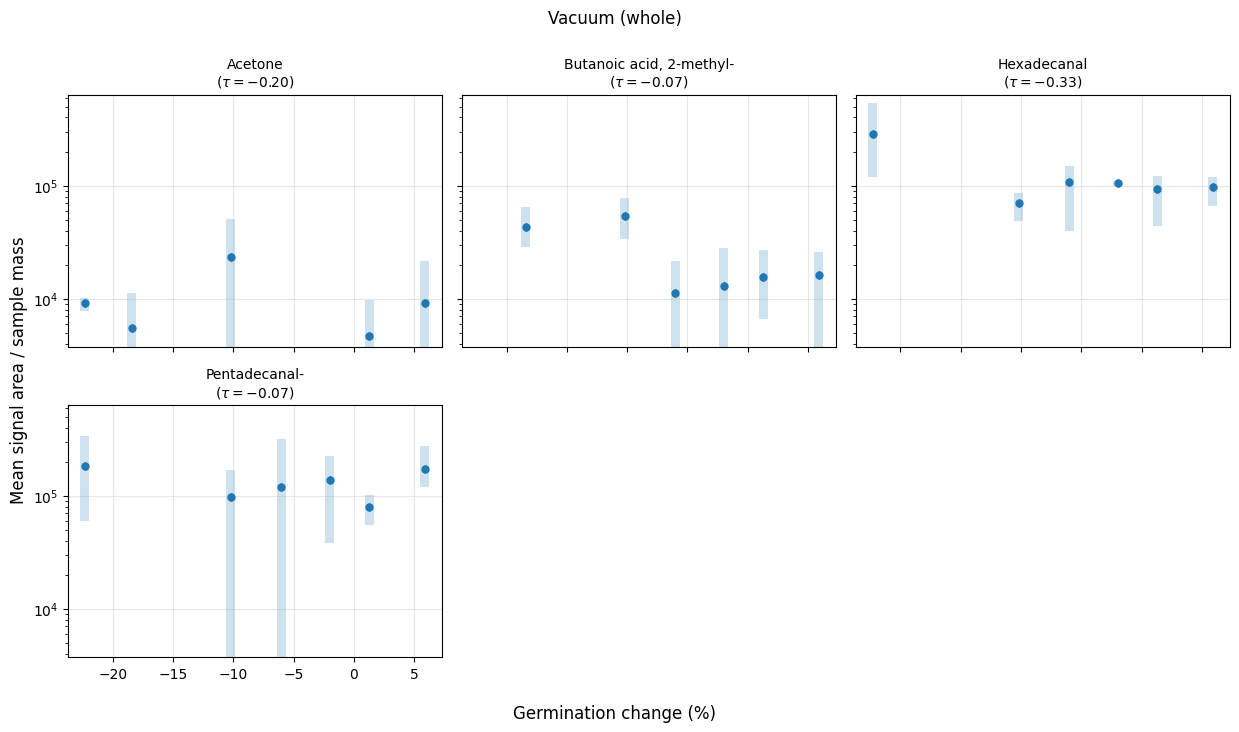

In [ ]:
# example plot using the function above
# signals from individual ageing-marker compounds that appear in at least 3 species plotted as a function of ex situ germination change
plot_df, common_compounds = plot_compound_signal_vs_trait(
    gcms_df[gcms_df['compound_norm'].isin(ageing_markers)],
    seed_area_df,
    seed_traits_df,
    treatment="vacuum_whole",
    x_var="germination_change",
    normalise_by="sample_mass",
    min_species=3,
    xerr_on=True,
)

In [60]:
# For each treatment, plot Kendall's tau vs minimum compound mass threshold for a chosen seed trait.
def plot_kendall_tau_vs_min_compound_mass_by_treatment(
    gcms_df,
    seed_area_df,
    seed_traits_df,
    x_var="surface_area",   # "surface_area", "oil_content", "germination_change"
    treatments=("vacuum_whole", "vacuum_cut", "normal_atm_whole"),
    treatment_labels=None,
    min_mass_values=None,

    # What to correlate
    normalise_by="n_seeds",          # "n_seeds" or "sample_mass"

    # GC columns
    species_col_gc="species",
    treatment_col="treatment",
    replicate_col="replicate",
    signal_col="area",
    n_seeds_col="n_seeds",
    sample_mass_col="sample_mass_mg",
    mass_col="mass_db",
    empty_label="Empty",

    # seed_area_df columns
    species_col_area="species",
    surface_area="approx",           # "projected" or "approx"
    projected_area_col="projected_surface_area/mm^2",
    approx_area_col="approx_surface_area/mm^2",

    # seed_traits_df columns
    species_col_traits="species",
    oil_content_mean_col="oil_content_mean",
    germination_change_col="germination_change",

    # replicate handling
    expected_n_replicates=3,
    include_zero_for_missing_replicates=True,

    # plotting
    ax=None,
    show=True,
    show_n_species=False,
):
    """
    Plot Kendall's tau vs minimum compound mass for all requested treatments,
    for one chosen seed trait.

    At each minimum mass threshold, signal is summed within each replicate using
    only compounds with mass_db >= threshold, then normalised by n_seeds or
    sample_mass, then averaged across replicates to get one value per species.

    Returns
    -------
    tau_df : pandas.DataFrame
        Long-form dataframe with columns:
        treatment, min_compound_mass, kendall_tau, p_value, n_species, n_gc_rows_retained
    """

    if treatment_labels is None:
        treatment_labels = {
            "normal_atm_whole": "Normal atmosphere (whole)",
            "vacuum_whole": "Vacuum (whole)",
            "vacuum_cut": "Vacuum (cut)",
            "normal_atm_empty": "Normal atmosphere (empty)",
            "vacuum_empty": "Vacuum (empty)",
        }

    # -------------------------
    # Defaults for thresholds
    # -------------------------
    if min_mass_values is None:
        masses = pd.to_numeric(gcms_df[mass_col], errors="coerce").dropna()
        if len(masses) == 0:
            raise ValueError(f"No numeric values found in column '{mass_col}'.")
        lo = int(np.floor(masses.min()))
        hi = int(np.ceil(masses.max()))
        min_mass_values = np.arange(lo, hi + 1, 10)

    min_mass_values = list(min_mass_values)

    # -------------------------
    # Choose trait summary
    # -------------------------
    if x_var == "surface_area":
        if surface_area == "projected":
            area_col = projected_area_col
            trait_label = "projected seed surface area"
        elif surface_area == "approx":
            area_col = approx_area_col
            trait_label = "approx. seed surface area"
        else:
            raise ValueError("surface_area must be 'projected' or 'approx'")

        trait_df = (
            seed_area_df[[species_col_area, area_col]]
            .copy()
            .rename(columns={species_col_area: "species", area_col: "trait_value"})
        )
        trait_df["trait_value"] = pd.to_numeric(trait_df["trait_value"], errors="coerce")
        trait_df = trait_df.dropna(subset=["species", "trait_value"])

        trait_summary = (
            trait_df.groupby("species", dropna=False)["trait_value"]
            .mean()
            .reset_index()
        )

    elif x_var == "oil_content":
        trait_label = "oil content"
        trait_summary = (
            seed_traits_df[[species_col_traits, oil_content_mean_col]]
            .copy()
            .rename(columns={species_col_traits: "species", oil_content_mean_col: "trait_value"})
        )
        trait_summary["trait_value"] = pd.to_numeric(trait_summary["trait_value"], errors="coerce")
        trait_summary = trait_summary.dropna(subset=["species", "trait_value"])

    elif x_var == "germination_change":
        trait_label = "germination change"
        trait_summary = (
            seed_traits_df[[species_col_traits, germination_change_col]]
            .copy()
            .rename(columns={species_col_traits: "species", germination_change_col: "trait_value"})
        )
        trait_summary["trait_value"] = pd.to_numeric(trait_summary["trait_value"], errors="coerce")
        trait_summary = trait_summary.dropna(subset=["species", "trait_value"])

    else:
        raise ValueError("x_var must be 'surface_area', 'oil_content', or 'germination_change'")

    # -------------------------
    # Choose signal normalisation
    # -------------------------
    if normalise_by == "n_seeds":
        y_label = "Signal area per seed"
    elif normalise_by == "sample_mass":
        y_label = "Signal area / sample mass"
    else:
        raise ValueError("normalise_by must be 'n_seeds' or 'sample_mass'")

    # -------------------------
    # Clean GC base once
    # -------------------------
    gc = gcms_df.copy()
    gc = gc[gc[species_col_gc] != empty_label].copy()

    gc[signal_col] = pd.to_numeric(gc[signal_col], errors="coerce")
    gc[mass_col] = pd.to_numeric(gc[mass_col], errors="coerce")
    gc[n_seeds_col] = pd.to_numeric(gc[n_seeds_col], errors="coerce")
    gc[sample_mass_col] = pd.to_numeric(gc[sample_mass_col], errors="coerce")

    gc = gc.dropna(subset=[species_col_gc, treatment_col, replicate_col, signal_col, mass_col])

    rows = []

    # -------------------------
    # Loop over treatments
    # -------------------------
    for treatment in treatments:
        gc_t = gc[gc[treatment_col] == treatment].copy()

        if gc_t.empty:
            print(f"Warning: no usable GC-MS rows found for treatment '{treatment}'.")
            continue

        # replicate grid from all replicates actually run in this treatment
        rep_grid = (
            gc_t.groupby([species_col_gc, treatment_col, replicate_col], dropna=False)
                .agg(
                    n_seeds=(n_seeds_col, "first"),
                    sample_mass=(sample_mass_col, "first"),
                )
                .reset_index()
                .rename(columns={species_col_gc: "species", treatment_col: "treatment"})
        )

        rep_counts = rep_grid.groupby("species")[replicate_col].nunique()

        for mmin in min_mass_values:
            sub = gc_t[gc_t[mass_col] >= mmin].copy()

            rep_sig = (
                sub.groupby([species_col_gc, treatment_col, replicate_col], dropna=False)[signal_col]
                   .sum()
                   .reset_index()
                   .rename(columns={
                       species_col_gc: "species",
                       treatment_col: "treatment",
                       signal_col: "total_signal",
                   })
            )

            rep = rep_grid.merge(
                rep_sig,
                on=["species", "treatment", replicate_col],
                how="left"
            )
            rep["total_signal"] = rep["total_signal"].fillna(0.0)

            if include_zero_for_missing_replicates:
                padded_rows = []

                for sp, grp in rep.groupby("species", dropna=False):
                    n_obs = len(grp)
                    n_missing = max(0, expected_n_replicates - n_obs)

                    if n_missing > 0:
                        existing_labels = set(grp[replicate_col].astype(str))

                        for j in range(n_missing):
                            new_label = f"__added_zero_rep_{j+1}"
                            while new_label in existing_labels:
                                new_label = f"__added_zero_rep_{j+1}_x"

                            padded_rows.append({
                                "species": sp,
                                "treatment": treatment,
                                replicate_col: new_label,
                                "n_seeds": np.nan,
                                "sample_mass": np.nan,
                                "total_signal": 0.0,
                            })

                if padded_rows:
                    rep = pd.concat([rep, pd.DataFrame(padded_rows)], ignore_index=True)

            if normalise_by == "n_seeds":
                rep["rep_signal_norm"] = rep["total_signal"] / rep["n_seeds"]
            else:
                rep["rep_signal_norm"] = rep["total_signal"] / rep["sample_mass"]

            species_signal = (
                rep.groupby("species", dropna=False)
                   .agg(
                       mean_signal=("rep_signal_norm", "mean"),
                       min_signal=("rep_signal_norm", "min"),
                       max_signal=("rep_signal_norm", "max"),
                       n_reps=("rep_signal_norm", "count"),
                   )
                   .reset_index()
            )

            corr_df = species_signal.merge(trait_summary, on="species", how="inner")
            good = np.isfinite(corr_df["trait_value"]) & np.isfinite(corr_df["mean_signal"])
            corr_df = corr_df.loc[good].copy()

            if len(corr_df) >= 3:
                tau, p = kendalltau(corr_df["trait_value"], corr_df["mean_signal"])
            else:
                tau, p = np.nan, np.nan

            rows.append({
                "treatment": treatment,
                "min_compound_mass": mmin,
                "kendall_tau": tau,
                "p_value": p,
                "n_species": len(corr_df),
                "n_gc_rows_retained": len(sub),
            })

    tau_df = pd.DataFrame(rows)

    if tau_df.empty:
        raise ValueError("No results to plot.")

    # -------------------------
    # Plot
    # -------------------------
    if ax is None:
        fig, ax = plt.subplots(figsize=(7.5, 4.8))
    else:
        fig = ax.figure

    for treatment in treatments:
        sub = tau_df[tau_df["treatment"] == treatment].sort_values("min_compound_mass")
        if sub.empty:
            continue

        ax.plot(
            sub["min_compound_mass"],
            sub["kendall_tau"],
            marker="o",
            label=treatment_labels.get(treatment, treatment),
        )

    ax.axhline(0, linestyle="--", linewidth=1, alpha=0.6)
    ax.set_xlabel("Minimum compound mass / a.m.u")
    ax.set_ylabel("Kendall's $\\tau$")
    ax.set_title(f"{y_label} vs. {trait_label}")
    ax.set_ylim(-1, 1)
    ax.grid(True, alpha=0.3)
    ax.legend()

    if show_n_species:
        ax2 = ax.twinx()
        for treatment in treatments:
            sub = tau_df[tau_df["treatment"] == treatment].sort_values("min_compound_mass")
            if sub.empty:
                continue

            ax2.plot(
                sub["min_compound_mass"],
                sub["n_species"],
                linestyle=":",
                alpha=0.5,
            )
        ax2.set_ylabel("Number of species")

    plt.tight_layout()

    #plt.savefig(f'Plots/correlation_between_signal_area_per_unit_mass_and_{x_var}_vs_compound_mass_threshold.png', dpi=300, bbox_inches='tight')

    if show:
        plt.show()

    return tau_df

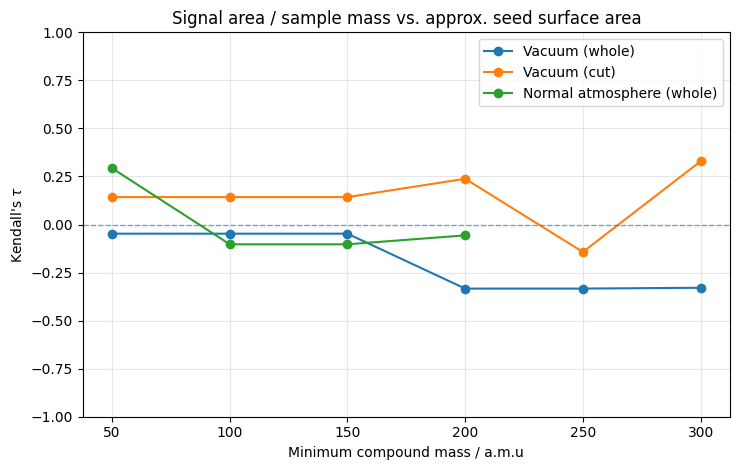

,treatment,min_compound_mass,kendall_tau,p_value,n_species,n_gc_rows_retained
0,vacuum_whole,50,-0.047619,1.000000,7,572
1,vacuum_whole,100,-0.047619,1.000000,7,558
2,vacuum_whole,150,-0.047619,1.000000,7,373
3,vacuum_whole,200,-0.333333,0.381349,7,290
4,vacuum_whole,250,-0.333333,0.381349,7,182
5,vacuum_whole,300,-0.328976,0.341814,7,4
6,vacuum_whole,350,NaN,NaN,7,0
7,vacuum_cut,50,0.142857,0.772619,7,887
8,vacuum_cut,100,0.142857,0.772619,7,852
9,vacuum_cut,150,0.142857,0.772619,7,563


In [61]:
tau_df = plot_kendall_tau_vs_min_compound_mass_by_treatment(
    gcms_df,
    seed_area_df,
    seed_traits_df,
    x_var="surface_area",
    normalise_by="sample_mass",
    min_mass_values=np.arange(50, 351, 50),
)
tau_df

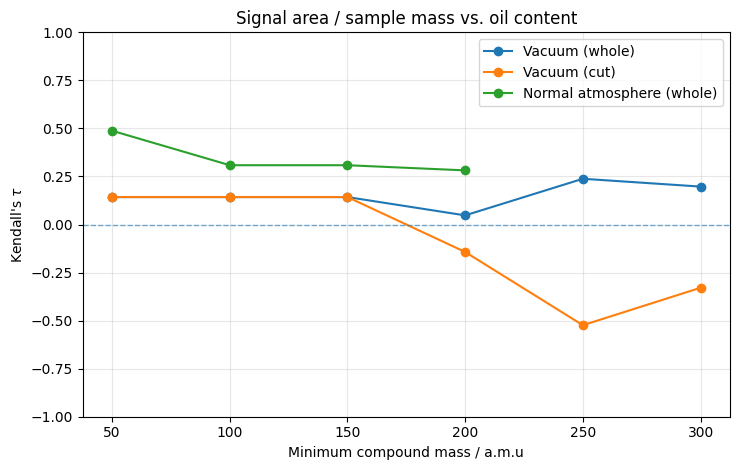

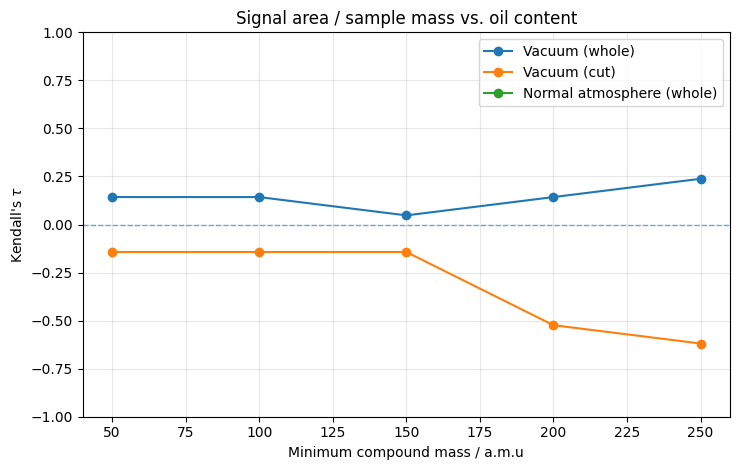

In [64]:
tau_df_all = plot_kendall_tau_vs_min_compound_mass_by_treatment(
    gcms_df,
    seed_area_df,
    seed_traits_df,
    x_var="oil_content",
    normalise_by="sample_mass",
    min_mass_values=np.arange(50, 351, 50),
)

tau_df_oil_markers = plot_kendall_tau_vs_min_compound_mass_by_treatment(
    gcms_df[gcms_df['compound_norm'].isin(oil_markers)],
    seed_area_df,
    seed_traits_df,
    x_var="oil_content",
    normalise_by="sample_mass",
    min_mass_values=np.arange(50, 351, 50),
)

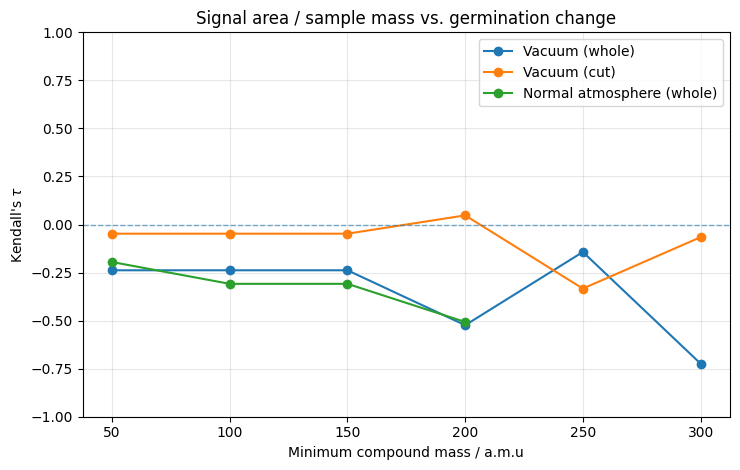

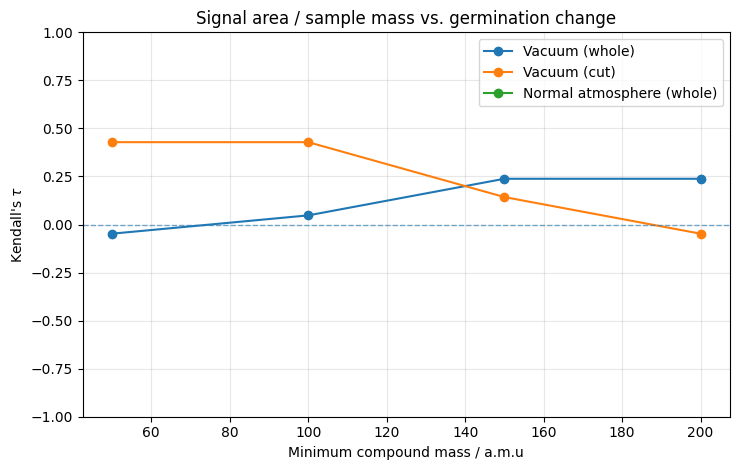

In [65]:
tau_df_all = plot_kendall_tau_vs_min_compound_mass_by_treatment(
    gcms_df,
    seed_area_df,
    seed_traits_df,
    x_var="germination_change",
    normalise_by="sample_mass",
    min_mass_values=np.arange(50, 351, 50),
)

tau_df_ageing_markers = plot_kendall_tau_vs_min_compound_mass_by_treatment(
    gcms_df[gcms_df['compound_norm'].isin(ageing_markers)],
    seed_area_df,
    seed_traits_df,
    x_var="germination_change",
    normalise_by="sample_mass",
    min_mass_values=np.arange(50, 351, 50),
)

In [68]:
def compute_kendall_tau_vs_min_compound_mass_by_treatment(
    gcms_df,
    seed_area_df,
    seed_traits_df,
    x_var="surface_area",   # "surface_area", "oil_content", "germination_change"
    treatments=("vacuum_whole", "vacuum_cut", "normal_atm_whole"),
    treatment_labels=None,
    min_mass_values=None,

    # What to correlate
    normalise_by="n_seeds",          # "n_seeds" or "sample_mass"

    # GC columns
    species_col_gc="species",
    treatment_col="treatment",
    replicate_col="replicate",
    signal_col="area",
    n_seeds_col="n_seeds",
    sample_mass_col="sample_mass_mg",
    mass_col="mass_db",
    empty_label="Empty",

    # seed_area_df columns
    species_col_area="species",
    surface_area="approx",           # "projected" or "approx"
    projected_area_col="projected_surface_area/mm^2",
    approx_area_col="approx_surface_area/mm^2",

    # seed_traits_df columns
    species_col_traits="species",
    oil_content_mean_col="oil_content_mean",
    germination_change_col="germination_change",

    # replicate handling
    expected_n_replicates=3,
    include_zero_for_missing_replicates=True,
):
    """
    Compute tau dataframe for one chosen x_var, without plotting.
    """

    if treatment_labels is None:
        treatment_labels = {
            "normal_atm_whole": "Normal atmosphere (whole)",
            "vacuum_whole": "Vacuum (whole)",
            "vacuum_cut": "Vacuum (cut)",
            "normal_atm_empty": "Normal atmosphere (empty)",
            "vacuum_empty": "Vacuum (empty)",
        }

    # -------------------------
    # Defaults for thresholds
    # -------------------------
    if min_mass_values is None:
        masses = pd.to_numeric(gcms_df[mass_col], errors="coerce").dropna()
        if len(masses) == 0:
            raise ValueError(f"No numeric values found in column '{mass_col}'.")
        lo = int(np.floor(masses.min()))
        hi = int(np.ceil(masses.max()))
        min_mass_values = np.arange(lo, hi + 1, 50)

    min_mass_values = list(min_mass_values)

    # -------------------------
    # Choose trait summary
    # -------------------------
    if x_var == "surface_area":
        if surface_area == "projected":
            area_col = projected_area_col
            trait_label = "projected seed surface area"
        elif surface_area == "approx":
            area_col = approx_area_col
            trait_label = "approx. seed surface area"
        else:
            raise ValueError("surface_area must be 'projected' or 'approx'")

        trait_df = (
            seed_area_df[[species_col_area, area_col]]
            .copy()
            .rename(columns={species_col_area: "species", area_col: "trait_value"})
        )
        trait_df["trait_value"] = pd.to_numeric(trait_df["trait_value"], errors="coerce")
        trait_df = trait_df.dropna(subset=["species", "trait_value"])

        trait_summary = (
            trait_df.groupby("species", dropna=False)["trait_value"]
            .mean()
            .reset_index()
        )

    elif x_var == "oil_content":
        trait_label = "oil content"
        trait_summary = (
            seed_traits_df[[species_col_traits, oil_content_mean_col]]
            .copy()
            .rename(columns={species_col_traits: "species", oil_content_mean_col: "trait_value"})
        )
        trait_summary["trait_value"] = pd.to_numeric(trait_summary["trait_value"], errors="coerce")
        trait_summary = trait_summary.dropna(subset=["species", "trait_value"])

    elif x_var == "germination_change":
        trait_label = "germination change"
        trait_summary = (
            seed_traits_df[[species_col_traits, germination_change_col]]
            .copy()
            .rename(columns={species_col_traits: "species", germination_change_col: "trait_value"})
        )
        trait_summary["trait_value"] = pd.to_numeric(trait_summary["trait_value"], errors="coerce")
        trait_summary = trait_summary.dropna(subset=["species", "trait_value"])

    else:
        raise ValueError("x_var must be 'surface_area', 'oil_content', or 'germination_change'")

    # -------------------------
    # Choose signal normalisation
    # -------------------------
    if normalise_by == "n_seeds":
        y_label = "Signal area per seed"
    elif normalise_by == "sample_mass":
        y_label = "Signal area / sample mass"
    else:
        raise ValueError("normalise_by must be 'n_seeds' or 'sample_mass'")

    # -------------------------
    # Clean GC base once
    # -------------------------
    gc = gcms_df.copy()
    gc = gc[gc[species_col_gc] != empty_label].copy()

    gc[signal_col] = pd.to_numeric(gc[signal_col], errors="coerce")
    gc[mass_col] = pd.to_numeric(gc[mass_col], errors="coerce")
    gc[n_seeds_col] = pd.to_numeric(gc[n_seeds_col], errors="coerce")
    gc[sample_mass_col] = pd.to_numeric(gc[sample_mass_col], errors="coerce")

    gc = gc.dropna(subset=[species_col_gc, treatment_col, replicate_col, signal_col, mass_col])

    rows = []

    # -------------------------
    # Loop over treatments
    # -------------------------
    for treatment in treatments:
        gc_t = gc[gc[treatment_col] == treatment].copy()

        if gc_t.empty:
            print(f"Warning: no usable GC-MS rows found for treatment '{treatment}'.")
            continue

        rep_grid = (
            gc_t.groupby([species_col_gc, treatment_col, replicate_col], dropna=False)
                .agg(
                    n_seeds=(n_seeds_col, "first"),
                    sample_mass=(sample_mass_col, "first"),
                )
                .reset_index()
                .rename(columns={species_col_gc: "species", treatment_col: "treatment"})
        )

        rep_counts = rep_grid.groupby("species")[replicate_col].nunique()

        for mmin in min_mass_values:
            sub = gc_t[gc_t[mass_col] >= mmin].copy()

            rep_sig = (
                sub.groupby([species_col_gc, treatment_col, replicate_col], dropna=False)[signal_col]
                   .sum()
                   .reset_index()
                   .rename(columns={
                       species_col_gc: "species",
                       treatment_col: "treatment",
                       signal_col: "total_signal",
                   })
            )

            rep = rep_grid.merge(
                rep_sig,
                on=["species", "treatment", replicate_col],
                how="left"
            )
            rep["total_signal"] = rep["total_signal"].fillna(0.0)

            if include_zero_for_missing_replicates:
                padded_rows = []

                for sp, grp in rep.groupby("species", dropna=False):
                    n_obs = len(grp)
                    n_missing = max(0, expected_n_replicates - n_obs)

                    if n_missing > 0:
                        existing_labels = set(grp[replicate_col].astype(str))

                        for j in range(n_missing):
                            new_label = f"__added_zero_rep_{j+1}"
                            while new_label in existing_labels:
                                new_label = f"__added_zero_rep_{j+1}_x"

                            padded_rows.append({
                                "species": sp,
                                "treatment": treatment,
                                replicate_col: new_label,
                                "n_seeds": np.nan,
                                "sample_mass": np.nan,
                                "total_signal": 0.0,
                            })

                if padded_rows:
                    rep = pd.concat([rep, pd.DataFrame(padded_rows)], ignore_index=True)

            if normalise_by == "n_seeds":
                rep["rep_signal_norm"] = rep["total_signal"] / rep["n_seeds"]
            else:
                rep["rep_signal_norm"] = rep["total_signal"] / rep["sample_mass"]

            species_signal = (
                rep.groupby("species", dropna=False)
                   .agg(
                       mean_signal=("rep_signal_norm", "mean"),
                       min_signal=("rep_signal_norm", "min"),
                       max_signal=("rep_signal_norm", "max"),
                       n_reps=("rep_signal_norm", "count"),
                   )
                   .reset_index()
            )

            corr_df = species_signal.merge(trait_summary, on="species", how="inner")
            good = np.isfinite(corr_df["trait_value"]) & np.isfinite(corr_df["mean_signal"])
            corr_df = corr_df.loc[good].copy()

            if len(corr_df) >= 3:
                tau, p = kendalltau(corr_df["trait_value"], corr_df["mean_signal"])
            else:
                tau, p = np.nan, np.nan

            rows.append({
                "x_var": x_var,
                "trait_label": trait_label,
                "y_label": y_label,
                "treatment": treatment,
                "min_compound_mass": mmin,
                "kendall_tau": tau,
                "p_value": p,
                "n_species": len(corr_df),
                "n_gc_rows_retained": len(sub),
            })

    tau_df = pd.DataFrame(rows)

    if tau_df.empty:
        raise ValueError("No results to plot.")

    return tau_df


def plot_kendall_tau_vs_min_compound_mass_by_treatment_3panel(
    gcms_df,
    seed_area_df,
    seed_traits_df,
    *,
    x_vars=("surface_area", "oil_content", "germination_change"),
    treatments=("vacuum_whole", "vacuum_cut", "normal_atm_whole"),
    treatment_labels=None,
    min_mass_values=None,

    # What to correlate
    normalise_by="n_seeds",

    # GC columns
    species_col_gc="species",
    treatment_col="treatment",
    replicate_col="replicate",
    signal_col="area",
    n_seeds_col="n_seeds",
    sample_mass_col="sample_mass_mg",
    mass_col="mass_db",
    empty_label="Empty",

    # seed_area_df columns
    species_col_area="species",
    surface_area="approx",
    projected_area_col="projected_surface_area/mm^2",
    approx_area_col="approx_surface_area/mm^2",

    # seed_traits_df columns
    species_col_traits="species",
    oil_content_mean_col="oil_content_mean",
    germination_change_col="germination_change",

    # replicate handling
    expected_n_replicates=3,
    include_zero_for_missing_replicates=True,

    # plotting
    figsize=(18, 4.8),
    show=True,
    show_n_species=False,
    savepath=None,
):
    """
    Make a 3-panel plot:
      (a) surface_area
      (b) oil_content
      (c) germination_change

    Returns
    -------
    all_tau_df : pandas.DataFrame
        Combined long-form dataframe for all panels.
    """

    if len(x_vars) != 3:
        raise ValueError("x_vars must contain exactly 3 entries.")

    if treatment_labels is None:
        treatment_labels = {
            "normal_atm_whole": "Normal atmosphere (whole)",
            "vacuum_whole": "Vacuum (whole)",
            "vacuum_cut": "Vacuum (cut)",
            "normal_atm_empty": "Normal atmosphere (empty)",
            "vacuum_empty": "Vacuum (empty)",
        }

    panel_labels = ["(a)", "(b)", "(c)"]

    fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=True)
    all_tau_dfs = []

    for ax, x_var, panel_label in zip(axes, x_vars, panel_labels):
        tau_df = compute_kendall_tau_vs_min_compound_mass_by_treatment(
            gcms_df,
            seed_area_df,
            seed_traits_df,
            x_var=x_var,
            treatments=treatments,
            treatment_labels=treatment_labels,
            min_mass_values=min_mass_values,
            normalise_by=normalise_by,
            species_col_gc=species_col_gc,
            treatment_col=treatment_col,
            replicate_col=replicate_col,
            signal_col=signal_col,
            n_seeds_col=n_seeds_col,
            sample_mass_col=sample_mass_col,
            mass_col=mass_col,
            empty_label=empty_label,
            species_col_area=species_col_area,
            surface_area=surface_area,
            projected_area_col=projected_area_col,
            approx_area_col=approx_area_col,
            species_col_traits=species_col_traits,
            oil_content_mean_col=oil_content_mean_col,
            germination_change_col=germination_change_col,
            expected_n_replicates=expected_n_replicates,
            include_zero_for_missing_replicates=include_zero_for_missing_replicates,
        )

        all_tau_dfs.append(tau_df)

        for treatment in treatments:
            sub = tau_df[tau_df["treatment"] == treatment].sort_values("min_compound_mass")
            if sub.empty:
                continue

            ax.plot(
                sub["min_compound_mass"],
                sub["kendall_tau"],
                marker="o",
                label=treatment_labels.get(treatment, treatment),
            )

        # panel title
        trait_label = tau_df["trait_label"].iloc[0]
        ax.set_title(f"{panel_label} {trait_label}")

        ax.axhline(0, linestyle="--", linewidth=1, alpha=0.6)
        ax.set_xlabel("Minimum compound mass / a.m.u")
        ax.set_ylim(-1, 1)
        ax.grid(True, alpha=0.3)

        if show_n_species:
            ax2 = ax.twinx()
            for treatment in treatments:
                sub = tau_df[tau_df["treatment"] == treatment].sort_values("min_compound_mass")
                if sub.empty:
                    continue

                ax2.plot(
                    sub["min_compound_mass"],
                    sub["n_species"],
                    linestyle=":",
                    alpha=0.5,
                )
            ax2.set_ylabel("Number of species")

    axes[0].set_ylabel("Kendall's $\\tau$")

    # one shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=len(treatments), frameon=False)

    plt.tight_layout(rect=[0, 0, 1, 0.9])

    if savepath is None:
        savepath = (
            f"Plots/correlation_between_signal_area_and_traits_vs_compound_mass_threshold_3panel.png"
        )

    #plt.savefig(savepath, dpi=300, bbox_inches="tight")

    if show:
        plt.show()

    all_tau_df = pd.concat(all_tau_dfs, ignore_index=True)
    return all_tau_df

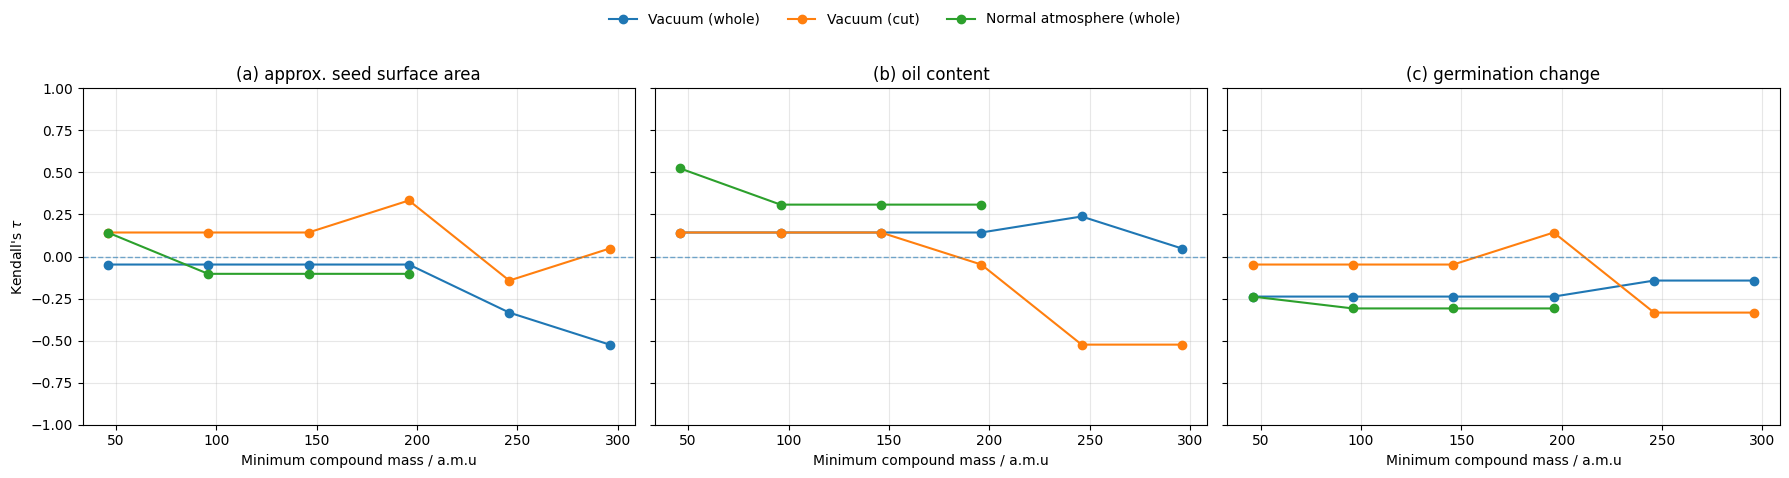

,x_var,trait_label,y_label,treatment,min_compound_mass,kendall_tau,p_value,n_species,n_gc_rows_retained
0,surface_area,approx. seed surface area,Signal area / sample mass,vacuum_whole,46,-0.047619,1.000000,7,574
1,surface_area,approx. seed surface area,Signal area / sample mass,vacuum_whole,96,-0.047619,1.000000,7,558
2,surface_area,approx. seed surface area,Signal area / sample mass,vacuum_whole,146,-0.047619,1.000000,7,373
3,surface_area,approx. seed surface area,Signal area / sample mass,vacuum_whole,196,-0.047619,1.000000,7,313
4,surface_area,approx. seed surface area,Signal area / sample mass,vacuum_whole,246,-0.333333,0.381349,7,182
5,surface_area,approx. seed surface area,Signal area / sample mass,vacuum_whole,296,-0.523810,0.136111,7,34
6,surface_area,approx. seed surface area,Signal area / sample mass,vacuum_cut,46,0.142857,0.772619,7,892
7,surface_area,approx. seed surface area,Signal area / sample mass,vacuum_cut,96,0.142857,0.772619,7,860
8,surface_area,approx. seed surface area,Signal area / sample mass,vacuum_cut,146,0.142857,0.772619,7,563
9,surface_area,approx. seed surface area,Signal area / sample mass,vacuum_cut,196,0.333333,0.381349,7,391


In [69]:
tau_df_all = plot_kendall_tau_vs_min_compound_mass_by_treatment_3panel(
    gcms_df,
    seed_area_df,
    seed_traits_df,
    normalise_by="sample_mass",   # or "n_seeds"
    surface_area="approx",
    show_n_species=False,
)
tau_df_all

In [70]:
def permutation_test_kendall_tau_difference_by_treatment(
    gcms_df,
    seed_area_df,
    seed_traits_df,
    x_vars=("surface_area", "oil_content", "germination_change"),
    treatments=("vacuum_whole", "vacuum_cut", "normal_atm_whole"),
    min_mass_values=None,

    # what to correlate
    normalise_by="n_seeds",   # "n_seeds" or "sample_mass"

    # GC columns
    species_col_gc="species",
    treatment_col="treatment",
    replicate_col="replicate",
    signal_col="area",
    n_seeds_col="n_seeds",
    sample_mass_col="sample_mass_mg",
    mass_col="mass_db",
    empty_label="Empty",

    # seed_area_df columns
    species_col_area="species",
    surface_area="approx",  # "projected" or "approx"
    projected_area_col="projected_surface_area/mm^2",
    approx_area_col="approx_surface_area/mm^2",

    # seed_traits_df columns
    species_col_traits="species",
    oil_content_mean_col="oil_content_mean",
    germination_change_col="germination_change",

    # replicate handling
    expected_n_replicates=3,
    include_zero_for_missing_replicates=True,

    # permutation settings
    exact_if_n_species_le=12,
    n_permutations=10000,
    random_state=42,

    # multiple testing correction
    p_adjust="fdr_bh",   # None or e.g. "fdr_bh"
):
    """
    Test whether Kendall's tau differs significantly between treatments
    at each minimum compound mass threshold, separately for each x_var.

    Uses a paired permutation test:
      - for each species, treatment labels are swapped between the two
        treatments being compared
      - this preserves the within-species pairing and the trait values

    Returns
    -------
    results_df : pandas.DataFrame
        Long-form dataframe with one row per:
            x_var × min_compound_mass × treatment pair
    """

    rng = np.random.default_rng(random_state)

    # ------------------------------------------------------------
    # Defaults for mass thresholds
    # ------------------------------------------------------------
    if min_mass_values is None:
        masses = pd.to_numeric(gcms_df[mass_col], errors="coerce").dropna()
        if len(masses) == 0:
            raise ValueError(f"No numeric values found in column '{mass_col}'.")
        lo = int(np.floor(masses.min()))
        hi = int(np.ceil(masses.max()))
        min_mass_values = np.arange(lo, hi + 1, 50)

    min_mass_values = list(min_mass_values)

    # ------------------------------------------------------------
    # Build trait summary helper
    # ------------------------------------------------------------
    def build_trait_summary(x_var):
        if x_var == "surface_area":
            if surface_area == "projected":
                area_col = projected_area_col
                trait_label = "projected seed surface area"
            elif surface_area == "approx":
                area_col = approx_area_col
                trait_label = "approx. seed surface area"
            else:
                raise ValueError("surface_area must be 'projected' or 'approx'")

            trait_df = (
                seed_area_df[[species_col_area, area_col]]
                .copy()
                .rename(columns={species_col_area: "species", area_col: "trait_value"})
            )
            trait_df["trait_value"] = pd.to_numeric(trait_df["trait_value"], errors="coerce")
            trait_df = trait_df.dropna(subset=["species", "trait_value"])

            trait_summary = (
                trait_df.groupby("species", dropna=False)["trait_value"]
                .mean()
                .reset_index()
            )

        elif x_var == "oil_content":
            trait_label = "oil content"
            trait_summary = (
                seed_traits_df[[species_col_traits, oil_content_mean_col]]
                .copy()
                .rename(columns={species_col_traits: "species", oil_content_mean_col: "trait_value"})
            )
            trait_summary["trait_value"] = pd.to_numeric(trait_summary["trait_value"], errors="coerce")
            trait_summary = trait_summary.dropna(subset=["species", "trait_value"])

        elif x_var == "germination_change":
            trait_label = "germination change"
            trait_summary = (
                seed_traits_df[[species_col_traits, germination_change_col]]
                .copy()
                .rename(columns={species_col_traits: "species", germination_change_col: "trait_value"})
            )
            trait_summary["trait_value"] = pd.to_numeric(trait_summary["trait_value"], errors="coerce")
            trait_summary = trait_summary.dropna(subset=["species", "trait_value"])

        else:
            raise ValueError("x_var must be 'surface_area', 'oil_content', or 'germination_change'")

        return trait_summary, trait_label

    # ------------------------------------------------------------
    # Prepare GC table once
    # ------------------------------------------------------------
    gc = gcms_df.copy()
    gc = gc[gc[species_col_gc] != empty_label].copy()

    gc[signal_col] = pd.to_numeric(gc[signal_col], errors="coerce")
    gc[mass_col] = pd.to_numeric(gc[mass_col], errors="coerce")
    gc[n_seeds_col] = pd.to_numeric(gc[n_seeds_col], errors="coerce")
    gc[sample_mass_col] = pd.to_numeric(gc[sample_mass_col], errors="coerce")

    gc = gc.dropna(subset=[species_col_gc, treatment_col, replicate_col, signal_col, mass_col])

    # ------------------------------------------------------------
    # Helper: species mean signal for one treatment and one threshold
    # ------------------------------------------------------------
    def compute_species_signal_for_treatment(gc_t, treatment, mmin):
        rep_grid = (
            gc_t.groupby([species_col_gc, treatment_col, replicate_col], dropna=False)
                .agg(
                    n_seeds=(n_seeds_col, "first"),
                    sample_mass=(sample_mass_col, "first"),
                )
                .reset_index()
                .rename(columns={species_col_gc: "species", treatment_col: "treatment"})
        )

        sub = gc_t[gc_t[mass_col] >= mmin].copy()

        rep_sig = (
            sub.groupby([species_col_gc, treatment_col, replicate_col], dropna=False)[signal_col]
               .sum()
               .reset_index()
               .rename(columns={
                   species_col_gc: "species",
                   treatment_col: "treatment",
                   signal_col: "total_signal",
               })
        )

        rep = rep_grid.merge(
            rep_sig,
            on=["species", "treatment", replicate_col],
            how="left"
        )
        rep["total_signal"] = rep["total_signal"].fillna(0.0)

        if include_zero_for_missing_replicates:
            padded_rows = []

            for sp, grp in rep.groupby("species", dropna=False):
                n_obs = len(grp)
                n_missing = max(0, expected_n_replicates - n_obs)

                if n_missing > 0:
                    existing_labels = set(grp[replicate_col].astype(str))

                    for j in range(n_missing):
                        new_label = f"__added_zero_rep_{j+1}"
                        while new_label in existing_labels:
                            new_label = f"__added_zero_rep_{j+1}_x"

                        padded_rows.append({
                            "species": sp,
                            "treatment": treatment,
                            replicate_col: new_label,
                            "n_seeds": np.nan,
                            "sample_mass": np.nan,
                            "total_signal": 0.0,
                        })

            if padded_rows:
                rep = pd.concat([rep, pd.DataFrame(padded_rows)], ignore_index=True)

        if normalise_by == "n_seeds":
            rep["rep_signal_norm"] = rep["total_signal"] / rep["n_seeds"]
        elif normalise_by == "sample_mass":
            rep["rep_signal_norm"] = rep["total_signal"] / rep["sample_mass"]
        else:
            raise ValueError("normalise_by must be 'n_seeds' or 'sample_mass'")

        species_signal = (
            rep.groupby("species", dropna=False)
               .agg(
                   mean_signal=("rep_signal_norm", "mean"),
                   min_signal=("rep_signal_norm", "min"),
                   max_signal=("rep_signal_norm", "max"),
                   n_reps=("rep_signal_norm", "count"),
               )
               .reset_index()
        )

        return species_signal

    # ------------------------------------------------------------
    # Helper: exact or Monte Carlo paired permutation test
    # ------------------------------------------------------------
    def paired_swap_perm_test(trait_vals, y_a, y_b):
        """
        trait_vals, y_a, y_b are matched arrays across the same species.
        Null: treatment labels A/B are exchangeable within species.
        """
        n = len(trait_vals)

        tau_a_obs = kendalltau(trait_vals, y_a).statistic
        tau_b_obs = kendalltau(trait_vals, y_b).statistic
        diff_obs = tau_a_obs - tau_b_obs

        if n <= exact_if_n_species_le:
            # exact: all 2^n swap patterns
            diffs = []
            for swap_bits in product([0, 1], repeat=n):
                swap_bits = np.array(swap_bits, dtype=bool)

                y_a_perm = y_a.copy()
                y_b_perm = y_b.copy()

                y_a_perm[swap_bits], y_b_perm[swap_bits] = y_b[swap_bits], y_a[swap_bits]

                tau_a_perm = kendalltau(trait_vals, y_a_perm).statistic
                tau_b_perm = kendalltau(trait_vals, y_b_perm).statistic
                diffs.append(tau_a_perm - tau_b_perm)

            diffs = np.asarray(diffs, dtype=float)

        else:
            diffs = np.empty(n_permutations, dtype=float)
            for i in range(n_permutations):
                swap_bits = rng.integers(0, 2, size=n).astype(bool)

                y_a_perm = y_a.copy()
                y_b_perm = y_b.copy()

                y_a_perm[swap_bits], y_b_perm[swap_bits] = y_b[swap_bits], y_a[swap_bits]

                tau_a_perm = kendalltau(trait_vals, y_a_perm).statistic
                tau_b_perm = kendalltau(trait_vals, y_b_perm).statistic
                diffs[i] = tau_a_perm - tau_b_perm

        # two-sided p-value
        p_value = np.mean(np.abs(diffs) >= np.abs(diff_obs))

        return tau_a_obs, tau_b_obs, diff_obs, p_value, diffs

    # ------------------------------------------------------------
    # Main loop
    # ------------------------------------------------------------
    results = []

    for x_var in x_vars:
        trait_summary, trait_label = build_trait_summary(x_var)

        # Build species mean signal table for all treatments and thresholds
        species_signal_rows = []

        for treatment in treatments:
            gc_t = gc[gc[treatment_col] == treatment].copy()
            if gc_t.empty:
                print(f"Warning: no usable GC-MS rows found for treatment '{treatment}'.")
                continue

            for mmin in min_mass_values:
                species_signal = compute_species_signal_for_treatment(gc_t, treatment, mmin)
                species_signal["min_compound_mass"] = mmin
                species_signal["treatment"] = treatment
                species_signal_rows.append(species_signal)

        if not species_signal_rows:
            continue

        species_signal_all = pd.concat(species_signal_rows, ignore_index=True)
        species_signal_all = species_signal_all.merge(trait_summary, on="species", how="inner")

        species_signal_all = species_signal_all[
            np.isfinite(species_signal_all["trait_value"]) &
            np.isfinite(species_signal_all["mean_signal"])
        ].copy()

        # Pairwise comparisons between treatments at each threshold
        for mmin in min_mass_values:
            ss_m = species_signal_all[species_signal_all["min_compound_mass"] == mmin].copy()

            for treatment_a, treatment_b in combinations(treatments, 2):
                a = (
                    ss_m.loc[ss_m["treatment"] == treatment_a, ["species", "trait_value", "mean_signal"]]
                    .rename(columns={"mean_signal": "signal_a"})
                )
                b = (
                    ss_m.loc[ss_m["treatment"] == treatment_b, ["species", "trait_value", "mean_signal"]]
                    .rename(columns={"mean_signal": "signal_b"})
                )

                merged = a.merge(b, on=["species", "trait_value"], how="inner").dropna()

                n_species = len(merged)

                if n_species < 3:
                    results.append({
                        "x_var": x_var,
                        "trait_label": trait_label,
                        "min_compound_mass": mmin,
                        "treatment_a": treatment_a,
                        "treatment_b": treatment_b,
                        "tau_a": np.nan,
                        "tau_b": np.nan,
                        "delta_tau": np.nan,
                        "p_value": np.nan,
                        "n_species": n_species,
                        "test_type": "paired_label_swap_permutation",
                    })
                    continue

                trait_vals = merged["trait_value"].to_numpy(dtype=float)
                y_a = merged["signal_a"].to_numpy(dtype=float)
                y_b = merged["signal_b"].to_numpy(dtype=float)

                tau_a, tau_b, delta_tau, p_value, _ = paired_swap_perm_test(
                    trait_vals, y_a, y_b
                )

                results.append({
                    "x_var": x_var,
                    "trait_label": trait_label,
                    "min_compound_mass": mmin,
                    "treatment_a": treatment_a,
                    "treatment_b": treatment_b,
                    "tau_a": tau_a,
                    "tau_b": tau_b,
                    "delta_tau": delta_tau,
                    "p_value": p_value,
                    "n_species": n_species,
                    "test_type": "paired_label_swap_permutation",
                })

    results_df = pd.DataFrame(results)

    if results_df.empty:
        raise ValueError("No valid permutation-test results were produced.")

    # ------------------------------------------------------------
    # Optional multiple-testing correction
    # ------------------------------------------------------------
    if p_adjust is not None:
        results_df["p_value_adj"] = np.nan

        # Adjust within each x_var across all thresholds and treatment pairs
        for x_var in results_df["x_var"].dropna().unique():
            mask = results_df["x_var"].eq(x_var) & results_df["p_value"].notna()
            if mask.sum() == 0:
                continue

            adj = multipletests(results_df.loc[mask, "p_value"], method=p_adjust)[1]
            results_df.loc[mask, "p_value_adj"] = adj

    return results_df

In [71]:
perm_results = permutation_test_kendall_tau_difference_by_treatment(
    gcms_df,
    seed_area_df,
    seed_traits_df,
    x_vars=("surface_area", "oil_content", "germination_change"),
    treatments=("vacuum_whole", "vacuum_cut", "normal_atm_whole"),
    normalise_by="sample_mass",
    p_adjust="fdr_bh",  
    n_permutations=1000
)

perm_results

,x_var,trait_label,min_compound_mass,treatment_a,treatment_b,tau_a,tau_b,delta_tau,p_value,n_species,test_type,p_value_adj
0,surface_area,approx. seed surface area,46,vacuum_whole,vacuum_cut,-0.047619,0.142857,-0.190476,0.843750,7,paired_label_swap_permutation,0.976103
1,surface_area,approx. seed surface area,46,vacuum_whole,normal_atm_whole,-0.047619,0.142857,-0.190476,0.687500,7,paired_label_swap_permutation,0.976103
2,surface_area,approx. seed surface area,46,vacuum_cut,normal_atm_whole,0.142857,0.142857,0.000000,1.000000,7,paired_label_swap_permutation,1.000000
3,surface_area,approx. seed surface area,96,vacuum_whole,vacuum_cut,-0.047619,0.142857,-0.190476,0.843750,7,paired_label_swap_permutation,0.976103
4,surface_area,approx. seed surface area,96,vacuum_whole,normal_atm_whole,-0.047619,-0.102869,0.055250,0.875000,7,paired_label_swap_permutation,0.976103
5,surface_area,approx. seed surface area,96,vacuum_cut,normal_atm_whole,0.142857,-0.102869,0.245726,0.640625,7,paired_label_swap_permutation,0.976103
6,surface_area,approx. seed surface area,146,vacuum_whole,vacuum_cut,-0.047619,0.142857,-0.190476,0.921875,7,paired_label_swap_permutation,0.976103
7,surface_area,approx. seed surface area,146,vacuum_whole,normal_atm_whole,-0.047619,-0.102869,0.055250,0.843750,7,paired_label_swap_permutation,0.976103
8,surface_area,approx. seed surface area,146,vacuum_cut,normal_atm_whole,0.142857,-0.102869,0.245726,0.671875,7,paired_label_swap_permutation,0.976103
9,surface_area,approx. seed surface area,196,vacuum_whole,vacuum_cut,-0.047619,0.333333,-0.380952,0.500000,7,paired_label_swap_permutation,0.976103


In [72]:
# Plot signal vs seed trait at iterative mass thresholds
def plot_signal_vs_trait_mass_thresholds(
    gcms_df,
    seed_area_df,
    seed_traits_df,
    treatment,
    mass_thresholds=(50, 150, 250, 350),
    x_var="oil_content",              # "surface_area", "oil_content", "germination_change"
    normalise_by="n_seeds",           # "n_seeds" or "sample_mass"

    # gcms columns
    species_col="species",
    treatment_col="treatment",
    replicate_col="replicate",
    signal_col="area",
    n_seeds_col="n_seeds",
    sample_mass_col="sample_mass_mg",
    mass_col="mass_db",
    empty_label="Empty",

    # seed area columns
    species_col_area="species",
    surface_area="approx",            # "projected" or "approx"
    projected_area_col="projected_surface_area/mm^2",
    approx_area_col="approx_surface_area/mm^2",

    # seed traits columns
    species_col_traits="species",
    oil_content_mean_col="oil_content_mean",
    oil_content_low_col="oil_content_low",
    oil_content_high_col="oil_content_high",
    germination_change_col="germination_change",

    # replicate handling
    expected_n_replicates=3,

    # plotting
    ncols=2,
    figsize_per_panel=(4.6, 4.0),
    markersize=5,
    band_alpha=0.22,
    logy=True,
    show_correlation=True,
    xerr_on=True,
    show=True,
):
    """
    Plot signal vs trait at a few cumulative mass thresholds.
    For threshold M, include compounds with mass_db >= M.
    """

    def get_trait_summary():
        if x_var == "surface_area":
            if surface_area == "projected":
                area_col = projected_area_col
                xlabel = "Projected seed surface area / mm$^2$"
            elif surface_area == "approx":
                area_col = approx_area_col
                xlabel = "Approx. seed surface area / mm$^2$"
            else:
                raise ValueError("surface_area must be 'projected' or 'approx'")

            d = seed_area_df[[species_col_area, area_col]].copy()
            d = d.rename(columns={species_col_area: "species", area_col: "trait"})
            d["trait"] = pd.to_numeric(d["trait"], errors="coerce")
            d = d.dropna(subset=["species", "trait"])

            out = (
                d.groupby("species", dropna=False)["trait"]
                .agg(mean_trait="mean", std_trait="std")
                .reset_index()
            )
            out["xerr_lo"] = out["std_trait"].fillna(0.0)
            out["xerr_hi"] = out["std_trait"].fillna(0.0)
            return out[["species", "mean_trait", "xerr_lo", "xerr_hi"]], xlabel

        elif x_var == "oil_content":
            d = seed_traits_df[
                [species_col_traits, oil_content_mean_col, oil_content_low_col, oil_content_high_col]
            ].copy()
            d = d.rename(columns={
                species_col_traits: "species",
                oil_content_mean_col: "mean_trait",
                oil_content_low_col: "trait_low",
                oil_content_high_col: "trait_high",
            })
            d["mean_trait"] = pd.to_numeric(d["mean_trait"], errors="coerce") * 100.0 # convert from fraction to percentage
            d["trait_low"] = pd.to_numeric(d["trait_low"], errors="coerce") * 100.0
            d["trait_high"] = pd.to_numeric(d["trait_high"], errors="coerce") * 100.0
            d = d.dropna(subset=["species", "mean_trait"])
            d["xerr_lo"] = np.clip(d["mean_trait"] - d["trait_low"], 0, None)
            d["xerr_hi"] = np.clip(d["trait_high"] - d["mean_trait"], 0, None)
            return d[["species", "mean_trait", "xerr_lo", "xerr_hi"]], "Oil content (%)"

        elif x_var == "germination_change":
            d = seed_traits_df[[species_col_traits, germination_change_col]].copy()
            d = d.rename(columns={species_col_traits: "species", germination_change_col: "mean_trait"})
            d["mean_trait"] = pd.to_numeric(d["mean_trait"], errors="coerce")
            d = d.dropna(subset=["species", "mean_trait"])
            d["xerr_lo"] = 0.0
            d["xerr_hi"] = 0.0
            return d[["species", "mean_trait", "xerr_lo", "xerr_hi"]], "Germination change (%)"

        else:
            raise ValueError("x_var must be 'surface_area', 'oil_content', or 'germination_change'")

    def compute_species_signal(gc_sub):
        rep_sig = (
            gc_sub.groupby(["species", replicate_col], dropna=False)[signal_col]
            .sum()
            .reset_index()
            .rename(columns={signal_col: "total_signal"})
        )

        rep = rep_grid.merge(rep_sig, on=["species", replicate_col], how="left")
        rep["total_signal"] = rep["total_signal"].fillna(0.0)

        padded_rows = []
        for sp, grp in rep.groupby("species", dropna=False):
            n_obs = len(grp)
            n_missing = max(0, expected_n_replicates - n_obs)
            if n_missing > 0:
                existing = set(grp[replicate_col].astype(str))
                for j in range(n_missing):
                    new_label = f"__added_zero_rep_{j+1}"
                    while new_label in existing:
                        new_label = f"__added_zero_rep_{j+1}_x"
                    padded_rows.append({
                        "species": sp,
                        replicate_col: new_label,
                        "n_seeds": np.nan,
                        "sample_mass": np.nan,
                        "total_signal": 0.0,
                    })
        if padded_rows:
            rep = pd.concat([rep, pd.DataFrame(padded_rows)], ignore_index=True)

        if normalise_by == "n_seeds":
            rep["rep_signal_norm"] = rep["total_signal"] / rep["n_seeds"]
        elif normalise_by == "sample_mass":
            rep["rep_signal_norm"] = rep["total_signal"] / rep["sample_mass"]
        else:
            raise ValueError("normalise_by must be 'n_seeds' or 'sample_mass'")

        return (
            rep.groupby("species", dropna=False)["rep_signal_norm"]
            .agg(mean_signal="mean", min_signal="min", max_signal="max")
            .reset_index()
        )

    # base gc
    gc = gcms_df.copy()
    gc = gc[(gc[treatment_col] == treatment) & (gc[species_col] != empty_label)].copy()
    gc[signal_col] = pd.to_numeric(gc[signal_col], errors="coerce")
    gc[mass_col] = pd.to_numeric(gc[mass_col], errors="coerce")
    gc[n_seeds_col] = pd.to_numeric(gc[n_seeds_col], errors="coerce")
    gc[sample_mass_col] = pd.to_numeric(gc[sample_mass_col], errors="coerce")
    gc = gc.dropna(subset=[species_col, replicate_col, signal_col, mass_col])

    gc = gc.rename(columns={species_col: "species"})

    rep_grid = (
        gc.groupby(["species", replicate_col], dropna=False)
        .agg(
            n_seeds=(n_seeds_col, "first"),
            sample_mass=(sample_mass_col, "first"),
        )
        .reset_index()
    )

    trait_summary, xlabel = get_trait_summary()

    # collect plot dfs
    plot_dfs = []
    for thr in mass_thresholds:
        sub = gc[gc[mass_col] >= thr].copy()
        species_signal = compute_species_signal(sub)
        merged = species_signal.merge(trait_summary, on="species", how="inner")
        merged["panel_label"] = f"Mass ≥ {thr}"
        merged["mass_threshold"] = thr
        plot_dfs.append(merged)

    plot_df = pd.concat(plot_dfs, ignore_index=True)

    # global y limits
    ymin = plot_df["min_signal"].min()
    ymax = plot_df["max_signal"].max()

    if logy:
        pos = pd.concat([
            plot_df.loc[plot_df["mean_signal"] > 0, "mean_signal"],
            plot_df.loc[plot_df["min_signal"] > 0, "min_signal"],
            plot_df.loc[plot_df["max_signal"] > 0, "max_signal"],
        ])
        if len(pos) == 0:
            raise ValueError("No positive y values available for log scaling.")
        ymin = pos.min() * 0.8
        ymax = pos.max() * 1.2

    # plot
    n = len(mass_thresholds)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        sharex=True, sharey=True
    )
    axes = np.array(axes).reshape(-1)

    marker_diameter_pixels = markersize * fig.dpi / 72.0

    for i, thr in enumerate(mass_thresholds):
        ax = axes[i]
        sub = plot_df[plot_df["mass_threshold"] == thr].sort_values("mean_trait").copy()

        if xerr_on:
            xerr = np.vstack([
                sub["xerr_lo"].fillna(0.0).to_numpy(),
                sub["xerr_hi"].fillna(0.0).to_numpy(),
            ])
        else:
            xerr = None

        ax.errorbar(
            sub["mean_trait"],
            sub["mean_signal"],
            xerr=xerr,
            fmt="o",
            capsize=3 if xerr_on else 0,
            markersize=markersize,
            zorder=3,
        )

        if show_correlation and len(sub) >= 3:
            good = np.isfinite(sub["mean_trait"]) & np.isfinite(sub["mean_signal"])
            if good.sum() >= 3:
                tau, _ = kendalltau(sub.loc[good, "mean_trait"], sub.loc[good, "mean_signal"])
                title = f"Mass ≥ {thr} a.m.u. \n$\\tau={tau:.2f}$"
            else:
                title = f"Mass ≥ {thr} a.m.u."
        else:
            title = f"Mass ≥ {thr} a.m.u."

        ax.set_title(title, fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(ymin, ymax)
        if logy:
            ax.set_yscale("log")

        # draw min-max bands
        ylim = ax.get_ylim()
        ymid = np.sqrt(ylim[0] * ylim[1]) if logy and ylim[0] > 0 and ylim[1] > 0 else 0.5 * (ylim[0] + ylim[1])

        ymid_disp = ax.transData.transform((0, ymid))[1]
        x0_disp = ax.transData.transform((0, ymid))[0]
        x1_disp = x0_disp + marker_diameter_pixels
        x0_data = ax.transData.inverted().transform((x0_disp, ymid_disp))[0]
        x1_data = ax.transData.inverted().transform((x1_disp, ymid_disp))[0]
        band_width = abs(x1_data - x0_data)

        for _, row in sub.iterrows():
            xi, ylo, yhi = row["mean_trait"], row["min_signal"], row["max_signal"]
            if np.isfinite(xi) and np.isfinite(ylo) and np.isfinite(yhi):
                if yhi < ylo:
                    ylo, yhi = yhi, ylo
                rect = Rectangle(
                    (xi - band_width / 2, ylo),
                    band_width,
                    yhi - ylo,
                    facecolor="C0",
                    edgecolor="none",
                    alpha=band_alpha,
                    zorder=1,
                )
                ax.add_patch(rect)

    for j in range(n, len(axes)):
        fig.delaxes(axes[j])

    ylabel = "Mean signal area per seed" if normalise_by == "n_seeds" else "Mean signal area / sample mass"
    fig.supxlabel(xlabel)
    fig.supylabel(ylabel)

    plt.tight_layout()

    #plt.savefig(f'Plots/signal_area_per_seed_vs_{x_var}_at_compound_mass_thresholds_oil_markers_only_{treatment}.png', dpi=300, bbox_inches='tight')

    if show:
        plt.show()

    return plot_df

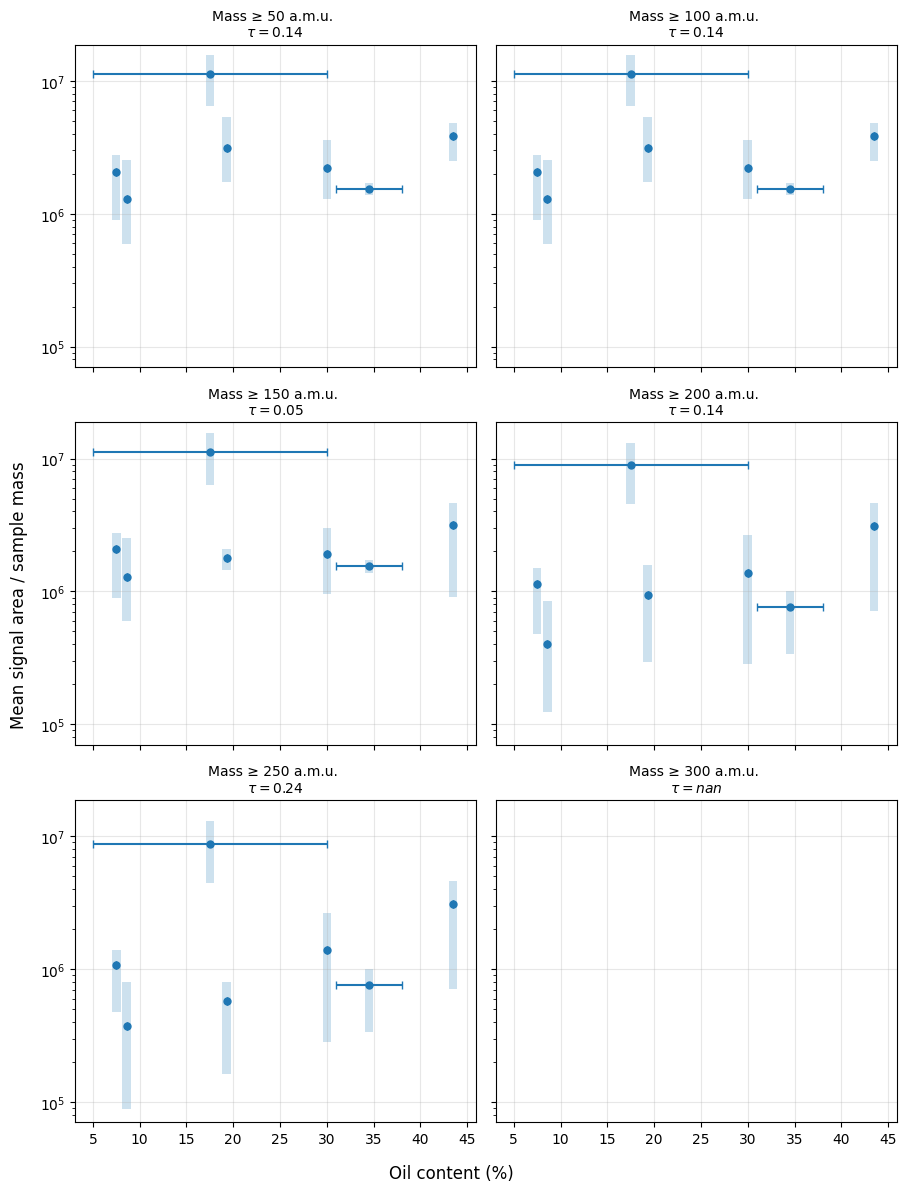

In [73]:
# example plot
# signal vs oil content for oil markers only, at iterative mass thresholds
threshold_plot_df = plot_signal_vs_trait_mass_thresholds(
    gcms_df[gcms_df['compound_norm'].isin(oil_markers)],
    seed_area_df,
    seed_traits_df,
    treatment="vacuum_whole",
    mass_thresholds=[50, 100, 150, 200, 250, 300],
    x_var="oil_content",
    normalise_by="sample_mass",
)

In [74]:
# Plot signal vs seed trait for discrete mass bins
def plot_signal_vs_trait_mass_bins(
    gcms_df,
    seed_area_df,
    seed_traits_df,
    treatment,
    mass_bins=((50, 100), (100, 150), (150, 200), (200, 250), (250, 300)),
    x_var="oil_content",              # "surface_area", "oil_content", "germination_change"
    normalise_by="n_seeds",           # "n_seeds" or "sample_mass"

    # gcms columns
    species_col="species",
    treatment_col="treatment",
    replicate_col="replicate",
    signal_col="area",
    n_seeds_col="n_seeds",
    sample_mass_col="sample_mass_mg",
    mass_col="mass_db",
    empty_label="Empty",

    # seed area columns
    species_col_area="species",
    surface_area="approx",
    projected_area_col="projected_surface_area/mm^2",
    approx_area_col="approx_surface_area/mm^2",

    # seed traits columns
    species_col_traits="species",
    oil_content_mean_col="oil_content_mean",
    oil_content_low_col="oil_content_low",
    oil_content_high_col="oil_content_high",
    germination_change_col="germination_change",

    # replicate handling
    expected_n_replicates=3,

    # plotting
    ncols=3,
    figsize_per_panel=(4.6, 4.0),
    markersize=5,
    band_alpha=0.22,
    logy=True,
    show_correlation=True,
    xerr_on=True,
    show=True,
):
    """
    Plot signal vs trait for a few discrete mass bins.
    For bin (lo, hi), include compounds with lo <= mass_db < hi.
    """

    def get_trait_summary():
        if x_var == "surface_area":
            if surface_area == "projected":
                area_col = projected_area_col
                xlabel = "Projected seed surface area / mm$^2$"
            elif surface_area == "approx":
                area_col = approx_area_col
                xlabel = "Approx. seed surface area / mm$^2$"
            else:
                raise ValueError("surface_area must be 'projected' or 'approx'")

            d = seed_area_df[[species_col_area, area_col]].copy()
            d = d.rename(columns={species_col_area: "species", area_col: "trait"})
            d["trait"] = pd.to_numeric(d["trait"], errors="coerce")
            d = d.dropna(subset=["species", "trait"])

            out = (
                d.groupby("species", dropna=False)["trait"]
                .agg(mean_trait="mean", std_trait="std")
                .reset_index()
            )
            out["xerr_lo"] = out["std_trait"].fillna(0.0)
            out["xerr_hi"] = out["std_trait"].fillna(0.0)
            return out[["species", "mean_trait", "xerr_lo", "xerr_hi"]], xlabel

        elif x_var == "oil_content":
            d = seed_traits_df[
                [species_col_traits, oil_content_mean_col, oil_content_low_col, oil_content_high_col]
            ].copy()
            d = d.rename(columns={
                species_col_traits: "species",
                oil_content_mean_col: "mean_trait",
                oil_content_low_col: "trait_low",
                oil_content_high_col: "trait_high",
            })
            d["mean_trait"] = pd.to_numeric(d["mean_trait"], errors="coerce") * 100.0 # convert from fraction to percentage
            d["trait_low"] = pd.to_numeric(d["trait_low"], errors="coerce") * 100.0
            d["trait_high"] = pd.to_numeric(d["trait_high"], errors="coerce") * 100.0
            d = d.dropna(subset=["species", "mean_trait"])
            d["xerr_lo"] = np.clip(d["mean_trait"] - d["trait_low"], 0, None)
            d["xerr_hi"] = np.clip(d["trait_high"] - d["mean_trait"], 0, None)
            return d[["species", "mean_trait", "xerr_lo", "xerr_hi"]], "Oil content (%)"

        elif x_var == "germination_change":
            d = seed_traits_df[[species_col_traits, germination_change_col]].copy()
            d = d.rename(columns={species_col_traits: "species", germination_change_col: "mean_trait"})
            d["mean_trait"] = pd.to_numeric(d["mean_trait"], errors="coerce")
            d = d.dropna(subset=["species", "mean_trait"])
            d["xerr_lo"] = 0.0
            d["xerr_hi"] = 0.0
            return d[["species", "mean_trait", "xerr_lo", "xerr_hi"]], "Germination change (%)"

        else:
            raise ValueError("x_var must be 'surface_area', 'oil_content', or 'germination_change'")

    def compute_species_signal(gc_sub):
        rep_sig = (
            gc_sub.groupby(["species", replicate_col], dropna=False)[signal_col]
            .sum()
            .reset_index()
            .rename(columns={signal_col: "total_signal"})
        )

        rep = rep_grid.merge(rep_sig, on=["species", replicate_col], how="left")
        rep["total_signal"] = rep["total_signal"].fillna(0.0)

        padded_rows = []
        for sp, grp in rep.groupby("species", dropna=False):
            n_obs = len(grp)
            n_missing = max(0, expected_n_replicates - n_obs)
            if n_missing > 0:
                existing = set(grp[replicate_col].astype(str))
                for j in range(n_missing):
                    new_label = f"__added_zero_rep_{j+1}"
                    while new_label in existing:
                        new_label = f"__added_zero_rep_{j+1}_x"
                    padded_rows.append({
                        "species": sp,
                        replicate_col: new_label,
                        "n_seeds": np.nan,
                        "sample_mass": np.nan,
                        "total_signal": 0.0,
                    })
        if padded_rows:
            rep = pd.concat([rep, pd.DataFrame(padded_rows)], ignore_index=True)

        if normalise_by == "n_seeds":
            rep["rep_signal_norm"] = rep["total_signal"] / rep["n_seeds"]
        elif normalise_by == "sample_mass":
            rep["rep_signal_norm"] = rep["total_signal"] / rep["sample_mass"]
        else:
            raise ValueError("normalise_by must be 'n_seeds' or 'sample_mass'")

        return (
            rep.groupby("species", dropna=False)["rep_signal_norm"]
            .agg(mean_signal="mean", min_signal="min", max_signal="max")
            .reset_index()
        )

    gc = gcms_df.copy()
    gc = gc[(gc[treatment_col] == treatment) & (gc[species_col] != empty_label)].copy()
    gc[signal_col] = pd.to_numeric(gc[signal_col], errors="coerce")
    gc[mass_col] = pd.to_numeric(gc[mass_col], errors="coerce")
    gc[n_seeds_col] = pd.to_numeric(gc[n_seeds_col], errors="coerce")
    gc[sample_mass_col] = pd.to_numeric(gc[sample_mass_col], errors="coerce")
    gc = gc.dropna(subset=[species_col, replicate_col, signal_col, mass_col])

    gc = gc.rename(columns={species_col: "species"})

    rep_grid = (
        gc.groupby(["species", replicate_col], dropna=False)
        .agg(
            n_seeds=(n_seeds_col, "first"),
            sample_mass=(sample_mass_col, "first"),
        )
        .reset_index()
    )

    trait_summary, xlabel = get_trait_summary()

    plot_dfs = []
    for lo, hi in mass_bins:
        sub = gc[(gc[mass_col] >= lo) & (gc[mass_col] < hi)].copy()
        species_signal = compute_species_signal(sub)
        merged = species_signal.merge(trait_summary, on="species", how="inner")
        merged["panel_label"] = f"{lo} ≤ mass < {hi}"
        merged["mass_bin_lo"] = lo
        merged["mass_bin_hi"] = hi
        plot_dfs.append(merged)

    plot_df = pd.concat(plot_dfs, ignore_index=True)

    ymin = plot_df["min_signal"].min()
    ymax = plot_df["max_signal"].max()

    if logy:
        pos = pd.concat([
            plot_df.loc[plot_df["mean_signal"] > 0, "mean_signal"],
            plot_df.loc[plot_df["min_signal"] > 0, "min_signal"],
            plot_df.loc[plot_df["max_signal"] > 0, "max_signal"],
        ])
        if len(pos) == 0:
            raise ValueError("No positive y values available for log scaling.")
        ymin = pos.min() * 0.8
        ymax = pos.max() * 1.2

    n = len(mass_bins)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        sharex=True, sharey=True
    )
    axes = np.array(axes).reshape(-1)

    marker_diameter_pixels = markersize * fig.dpi / 72.0

    for i, (lo, hi) in enumerate(mass_bins):
        ax = axes[i]
        sub = plot_df[
            (plot_df["mass_bin_lo"] == lo) & (plot_df["mass_bin_hi"] == hi)
        ].sort_values("mean_trait").copy()

        if xerr_on:
            xerr = np.vstack([
                sub["xerr_lo"].fillna(0.0).to_numpy(),
                sub["xerr_hi"].fillna(0.0).to_numpy(),
            ])
        else:
            xerr = None

        ax.errorbar(
            sub["mean_trait"],
            sub["mean_signal"],
            xerr=xerr,
            fmt="o",
            capsize=3 if xerr_on else 0,
            markersize=markersize,
            zorder=3,
        )

        if show_correlation and len(sub) >= 3:
            good = np.isfinite(sub["mean_trait"]) & np.isfinite(sub["mean_signal"])
            if good.sum() >= 3:
                tau, _ = kendalltau(sub.loc[good, "mean_trait"], sub.loc[good, "mean_signal"])
                title = f"{lo} ≤ compound mass / a.m.u. < {hi}\n$\\tau={tau:.2f}$"
            else:
                title = f"{lo} ≤ compound mass / a.m.u. < {hi}"
        else:
            title = f"{lo} ≤ compound mass / a.m.u. < {hi}"

        ax.set_title(title, fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(ymin, ymax)
        if logy:
            ax.set_yscale("log")

        ylim = ax.get_ylim()
        ymid = np.sqrt(ylim[0] * ylim[1]) if logy and ylim[0] > 0 and ylim[1] > 0 else 0.5 * (ylim[0] + ylim[1])

        ymid_disp = ax.transData.transform((0, ymid))[1]
        x0_disp = ax.transData.transform((0, ymid))[0]
        x1_disp = x0_disp + marker_diameter_pixels
        x0_data = ax.transData.inverted().transform((x0_disp, ymid_disp))[0]
        x1_data = ax.transData.inverted().transform((x1_disp, ymid_disp))[0]
        band_width = abs(x1_data - x0_data)

        for _, row in sub.iterrows():
            xi, ylo, yhi = row["mean_trait"], row["min_signal"], row["max_signal"]
            if np.isfinite(xi) and np.isfinite(ylo) and np.isfinite(yhi):
                if yhi < ylo:
                    ylo, yhi = yhi, ylo
                rect = Rectangle(
                    (xi - band_width / 2, ylo),
                    band_width,
                    yhi - ylo,
                    facecolor="C0",
                    edgecolor="none",
                    alpha=band_alpha,
                    zorder=1,
                )
                ax.add_patch(rect)

    for j in range(n, len(axes)):
        fig.delaxes(axes[j])

    ylabel = "Mean signal area per seed" if normalise_by == "n_seeds" else "Mean signal area / sample mass"
    fig.supxlabel(xlabel)
    fig.supylabel(ylabel)

    plt.tight_layout()

    #plt.savefig(f'Plots/signal_area_per_unit_mass_vs_{x_var}_in_compound_mass_bins_{treatment}.png', dpi=300, bbox_inches='tight')

    if show:
        plt.show()

    return plot_df

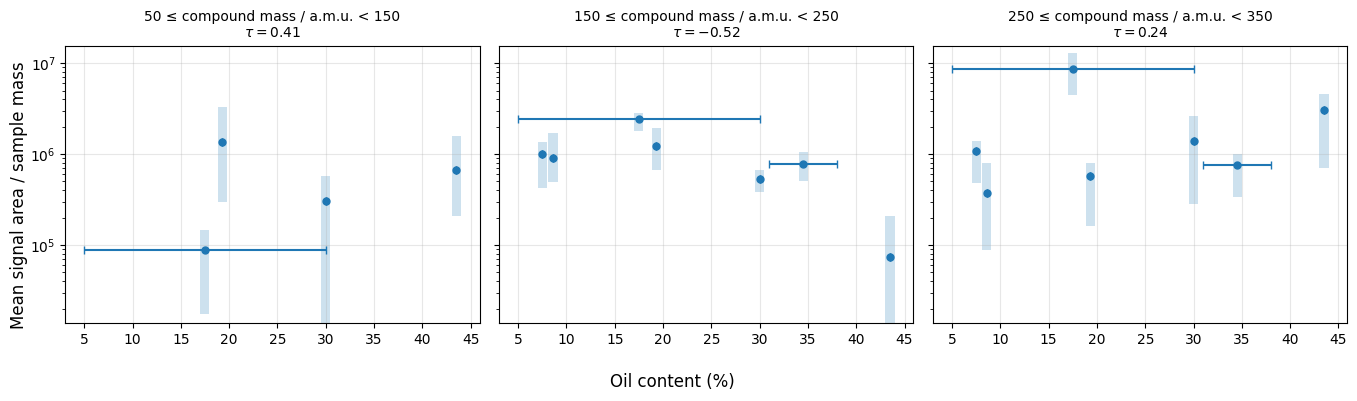

In [75]:
# example plot
# signal vs oil content for oil markers only, in discrete mass bins
bins_plot_df = plot_signal_vs_trait_mass_bins(
    gcms_df[gcms_df['compound_norm'].isin(oil_markers)],
    seed_area_df,
    seed_traits_df,
    treatment="vacuum_whole",
    x_var="oil_content",
    normalise_by="sample_mass",
    mass_bins=((50, 150), (150, 250), (250, 350))
)

In [ ]:
def permutation_test_difference_in_tau_from_panel_dfs(
    df_a,
    df_b,
    species_col="species",
    x_col="mean_trait",
    y_col="mean_signal",
    n_permutations=5000,
    random_state=42,
    alternative="two-sided",
):
    """
    Paired permutation test for the difference in Kendall's tau between two panels.

    Each dataframe should contain one row per species.

    The correlation in each panel is computed across species:
        tau_a = tau(x, y_a)
        tau_b = tau(x, y_b)

    Null:
        under no real difference between panels, the two panel-specific y-values
        are exchangeable within species.

    So for each permutation, we randomly swap y_a and y_b within species, then
    recompute tau_a - tau_b.
    """

    rng = np.random.default_rng(random_state)

    merged = (
        df_a[[species_col, x_col, y_col]]
        .rename(columns={x_col: "x_a", y_col: "y_a"})
        .merge(
            df_b[[species_col, x_col, y_col]].rename(columns={x_col: "x_b", y_col: "y_b"}),
            on=species_col,
            how="inner",
        )
    )

    merged["x_a"] = pd.to_numeric(merged["x_a"], errors="coerce")
    merged["x_b"] = pd.to_numeric(merged["x_b"], errors="coerce")
    merged["y_a"] = pd.to_numeric(merged["y_a"], errors="coerce")
    merged["y_b"] = pd.to_numeric(merged["y_b"], errors="coerce")

    good = (
        np.isfinite(merged["x_a"]) &
        np.isfinite(merged["x_b"]) &
        np.isfinite(merged["y_a"]) &
        np.isfinite(merged["y_b"])
    )
    merged = merged.loc[good].copy()

    if merged.empty:
        raise ValueError("No overlapping finite species data between the two panels.")

    # x should be the same trait values in both panels
    # use x from panel A
    x = merged["x_a"].to_numpy(dtype=float)
    y_a = merged["y_a"].to_numpy(dtype=float)
    y_b = merged["y_b"].to_numpy(dtype=float)

    n = len(x)
    if n < 3:
        raise ValueError(f"Need at least 3 overlapping species; got n={n}.")

    tau_a, _ = kendalltau(x, y_a)
    tau_b, _ = kendalltau(x, y_b)
    delta_obs = tau_a - tau_b

    null_deltas = np.empty(n_permutations, dtype=float)

    for i in range(n_permutations):
        swap = rng.integers(0, 2, size=n).astype(bool)

        y1 = y_a.copy()
        y2 = y_b.copy()

        y1[swap], y2[swap] = y_b[swap], y_a[swap]

        tau1, _ = kendalltau(x, y1)
        tau2, _ = kendalltau(x, y2)
        null_deltas[i] = tau1 - tau2

    if alternative == "two-sided":
        p_value = (np.sum(np.abs(null_deltas) >= abs(delta_obs)) + 1) / (n_permutations + 1)
    elif alternative == "greater":
        p_value = (np.sum(null_deltas >= delta_obs) + 1) / (n_permutations + 1)
    elif alternative == "less":
        p_value = (np.sum(null_deltas <= delta_obs) + 1) / (n_permutations + 1)
    else:
        raise ValueError("alternative must be 'two-sided', 'greater', or 'less'")

    return {
        "n_points": n,
        "tau_a": tau_a,
        "tau_b": tau_b,
        "delta_obs": delta_obs,
        "null_deltas": null_deltas,
        "p_value": p_value,
        "species_used": merged[species_col].tolist(),
    }

In [79]:
def pairwise_threshold_tau_permutation_tests(
    plot_df,
    species_col="species",
    threshold_col="mass_threshold",
    x_col="mean_trait",
    y_col="mean_signal",
    n_permutations=5000,
    random_state=42,
    alternative="two-sided",
    adjust_pvals=None,   # None, "bonferroni", "holm", "bh"
):
    """
    Compare every pair of mass-threshold panels in an existing threshold plot_df.

    For each pair of thresholds, this function compares the Kendall tau
    correlation between x_col and y_col using
    permutation_test_difference_in_tau_from_panel_dfs().

    If either panel has an undefined Kendall tau (NaN), the permutation
    test is skipped and p_value is set to NaN.

    Parameters
    ----------
    plot_df : pd.DataFrame
        DataFrame containing one row per species per threshold.
    species_col : str, default "species"
        Column identifying species.
    threshold_col : str, default "mass_threshold"
        Column identifying the mass-threshold panel.
    x_col : str, default "mean_trait"
        X variable used in the correlation.
    y_col : str, default "mean_signal"
        Y variable used in the correlation.
    n_permutations : int, default 5000
        Number of permutations for each pairwise test.
    random_state : int, default 42
        Base random seed.
    alternative : {"two-sided", "greater", "less"}, default "two-sided"
        Alternative hypothesis for the permutation test.
    adjust_pvals : {None, "bonferroni", "holm", "bh"}, default None
        Optional multiple-testing correction applied across all valid
        pairwise p-values.

    Returns
    -------
    results_df : pd.DataFrame
        DataFrame with one row per threshold pair and columns:
        threshold_a, threshold_b, n_points, tau_a, tau_b, delta_obs,
        p_value, and optionally p_value_adj.
    """
    
    thresholds = list(dict.fromkeys(plot_df[threshold_col].tolist()))
    results = []

    for i in range(len(thresholds)):
        for j in range(i + 1, len(thresholds)):
            thr_a = thresholds[i]
            thr_b = thresholds[j]

            df_a = plot_df.loc[plot_df[threshold_col] == thr_a].copy()
            df_b = plot_df.loc[plot_df[threshold_col] == thr_b].copy()

            # Compute observed taus first so we can skip invalid comparisons
            tau_a = df_a[[x_col, y_col]].corr(method="kendall").iloc[0, 1]
            tau_b = df_b[[x_col, y_col]].corr(method="kendall").iloc[0, 1]

            if np.isnan(tau_a) or np.isnan(tau_b):
                results.append({
                    "threshold_a": thr_a,
                    "threshold_b": thr_b,
                    "n_points": min(len(df_a), len(df_b)),
                    "tau_a": tau_a,
                    "tau_b": tau_b,
                    "delta_obs": np.nan,
                    "p_value": np.nan,
                })
                continue

            res = permutation_test_difference_in_tau_from_panel_dfs(
                df_a,
                df_b,
                species_col=species_col,
                x_col=x_col,
                y_col=y_col,
                n_permutations=n_permutations,
                random_state=random_state + len(results),
                alternative=alternative,
            )

            results.append({
                "threshold_a": thr_a,
                "threshold_b": thr_b,
                "n_points": res["n_points"],
                "tau_a": res["tau_a"],
                "tau_b": res["tau_b"],
                "delta_obs": res["delta_obs"],
                "p_value": res["p_value"],
            })

    results_df = pd.DataFrame(results)

    if adjust_pvals is not None and not results_df.empty:
        p = results_df["p_value"].to_numpy(dtype=float)

        valid = ~np.isnan(p)
        p_valid = p[valid]
        m = len(p_valid)

        if m > 0:
            if adjust_pvals == "bonferroni":
                adj = np.full_like(p, np.nan)
                adj[valid] = np.minimum(p_valid * m, 1.0)
                results_df["p_value_adj"] = adj

            elif adjust_pvals == "holm":
                order = np.argsort(p_valid)
                p_sorted = p_valid[order]

                adj_sorted = np.empty(m, dtype=float)
                for k, val in enumerate(p_sorted):
                    adj_sorted[k] = min((m - k) * val, 1.0)
                adj_sorted = np.maximum.accumulate(adj_sorted)

                adj_valid = np.empty(m, dtype=float)
                adj_valid[order] = adj_sorted

                adj = np.full_like(p, np.nan)
                adj[valid] = adj_valid
                results_df["p_value_adj"] = adj

            elif adjust_pvals == "bh":
                order = np.argsort(p_valid)
                p_sorted = p_valid[order]

                adj_sorted = np.empty(m, dtype=float)
                for k, val in enumerate(p_sorted, start=1):
                    adj_sorted[k - 1] = val * m / k

                adj_sorted = np.minimum.accumulate(adj_sorted[::-1])[::-1]
                adj_sorted = np.minimum(adj_sorted, 1.0)

                adj_valid = np.empty(m, dtype=float)
                adj_valid[order] = adj_sorted

                adj = np.full_like(p, np.nan)
                adj[valid] = adj_valid
                results_df["p_value_adj"] = adj

            else:
                raise ValueError(
                    "adjust_pvals must be None, 'bonferroni', 'holm', or 'bh'"
                )
        else:
            if adjust_pvals not in {"bonferroni", "holm", "bh"}:
                raise ValueError(
                    "adjust_pvals must be None, 'bonferroni', 'holm', or 'bh'"
                )
            results_df["p_value_adj"] = np.nan

    return results_df

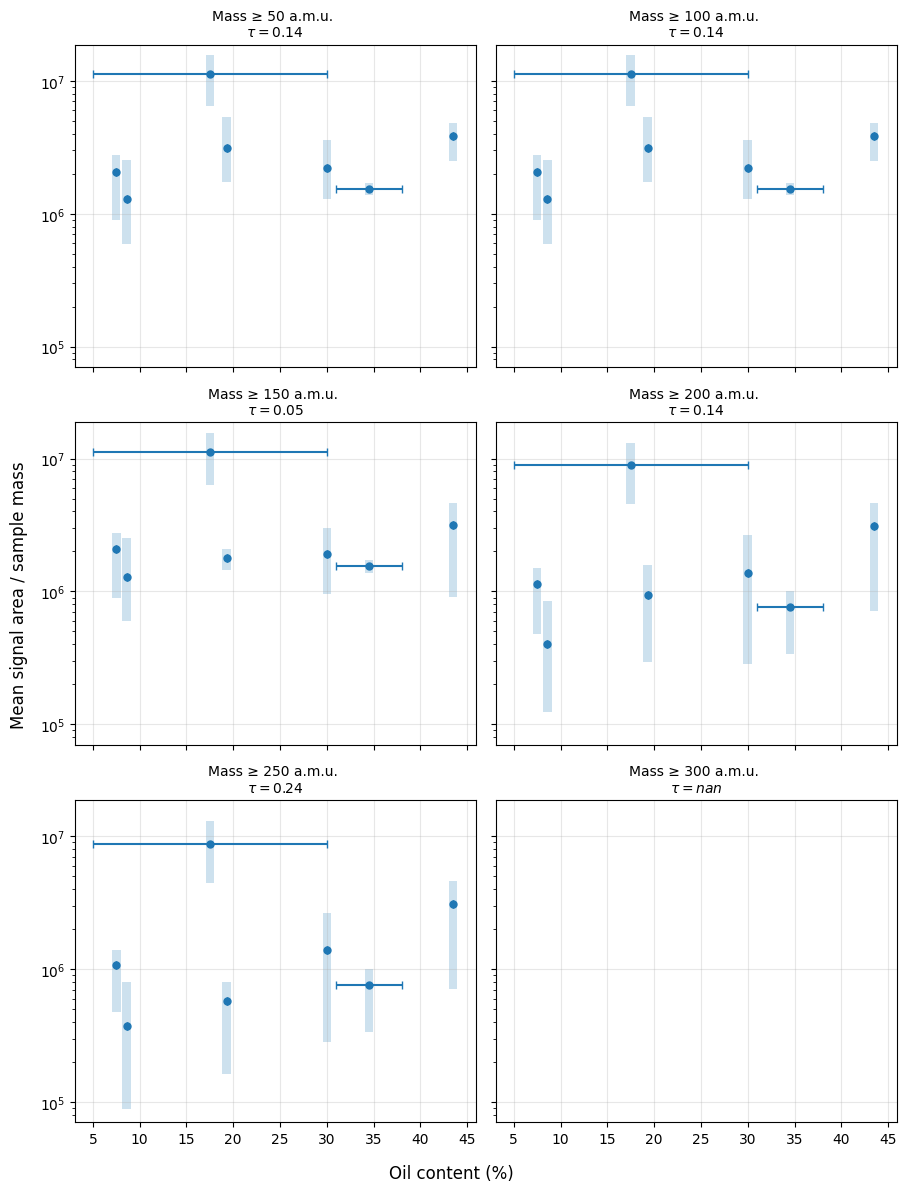

,threshold_a,threshold_b,n_points,tau_a,tau_b,delta_obs,p_value,p_value_adj
10,150,250,7,0.047619,0.238095,-0.190476,0.628372,1.0
9,150,200,7,0.047619,0.142857,-0.095238,0.756244,1.0
7,100,250,7,0.142857,0.238095,-0.095238,0.851149,1.0
3,50,250,7,0.142857,0.238095,-0.095238,0.859141,1.0
0,50,100,7,0.142857,0.142857,0.000000,1.000000,1.0
1,50,150,7,0.142857,0.047619,0.095238,1.000000,1.0
2,50,200,7,0.142857,0.142857,0.000000,1.000000,1.0
5,100,150,7,0.142857,0.047619,0.095238,1.000000,1.0
6,100,200,7,0.142857,0.142857,0.000000,1.000000,1.0
12,200,250,7,0.142857,0.238095,-0.095238,1.000000,1.0


In [81]:
# example
# compare differences in tau between mass thresholds for signal area vs oil content (oil markers only)
threshold_plot_df = plot_signal_vs_trait_mass_thresholds(
    gcms_df[gcms_df['compound_norm'].isin(oil_markers)],
    seed_area_df,
    seed_traits_df,
    treatment="vacuum_whole",
    mass_thresholds=[50, 100, 150, 200, 250, 300],
    x_var="oil_content",
    normalise_by="sample_mass",
)

threshold_results = pairwise_threshold_tau_permutation_tests(
    threshold_plot_df,
    n_permutations=1000,
    random_state=42,
    adjust_pvals="bh",
)

threshold_results.sort_values("p_value")

In [82]:
def pairwise_bin_tau_permutation_tests(
    plot_df,
    species_col="species",
    bin_lo_col="mass_bin_lo",
    bin_hi_col="mass_bin_hi",
    x_col="mean_trait",
    y_col="mean_signal",
    n_permutations=5000,
    random_state=42,
    alternative="two-sided",
    adjust_pvals=None,   # None, "bonferroni", "holm", "bh"
):
    """
    Compare every pair of mass-bin panels in an existing bin plot_df.

    For each pair of mass bins, this function compares the Kendall tau
    correlation between x_col and y_col using
    permutation_test_difference_in_tau_from_panel_dfs().

    If either panel has an undefined Kendall tau (NaN), the permutation
    test is skipped and p_value is set to NaN.

    Parameters
    ----------
    plot_df : pd.DataFrame
        DataFrame containing one row per species per mass bin.
    species_col : str, default "species"
        Column identifying species.
    bin_lo_col : str, default "mass_bin_lo"
        Column giving the lower edge of each mass bin.
    bin_hi_col : str, default "mass_bin_hi"
        Column giving the upper edge of each mass bin.
    x_col : str, default "mean_trait"
        X variable used in the correlation.
    y_col : str, default "mean_signal"
        Y variable used in the correlation.
    n_permutations : int, default 5000
        Number of permutations for each pairwise test.
    random_state : int, default 42
        Base random seed.
    alternative : {"two-sided", "greater", "less"}, default "two-sided"
        Alternative hypothesis for the permutation test.
    adjust_pvals : {None, "bonferroni", "holm", "bh"}, default None
        Optional multiple-testing correction applied across all valid
        pairwise p-values.

    Returns
    -------
    results_df : pd.DataFrame
        DataFrame with one row per bin pair and columns:
        bin_a, bin_b, n_points, tau_a, tau_b, delta_obs, p_value,
        and optionally p_value_adj.
    """
    
    bin_keys = list(dict.fromkeys(zip(plot_df[bin_lo_col], plot_df[bin_hi_col])))
    results = []

    for i in range(len(bin_keys)):
        for j in range(i + 1, len(bin_keys)):
            lo_a, hi_a = bin_keys[i]
            lo_b, hi_b = bin_keys[j]

            df_a = plot_df.loc[
                (plot_df[bin_lo_col] == lo_a) & (plot_df[bin_hi_col] == hi_a)
            ].copy()

            df_b = plot_df.loc[
                (plot_df[bin_lo_col] == lo_b) & (plot_df[bin_hi_col] == hi_b)
            ].copy()

            # Compute observed taus first so we can skip invalid comparisons
            tau_a = df_a[[x_col, y_col]].corr(method="kendall").iloc[0, 1]
            tau_b = df_b[[x_col, y_col]].corr(method="kendall").iloc[0, 1]

            if np.isnan(tau_a) or np.isnan(tau_b):
                results.append({
                    "bin_a": (lo_a, hi_a),
                    "bin_b": (lo_b, hi_b),
                    "n_points": min(len(df_a), len(df_b)),
                    "tau_a": tau_a,
                    "tau_b": tau_b,
                    "delta_obs": np.nan,
                    "p_value": np.nan,
                })
                continue

            res = permutation_test_difference_in_tau_from_panel_dfs(
                df_a,
                df_b,
                species_col=species_col,
                x_col=x_col,
                y_col=y_col,
                n_permutations=n_permutations,
                random_state=random_state + len(results),
                alternative=alternative,
            )

            results.append({
                "bin_a": (lo_a, hi_a),
                "bin_b": (lo_b, hi_b),
                "n_points": res["n_points"],
                "tau_a": res["tau_a"],
                "tau_b": res["tau_b"],
                "delta_obs": res["delta_obs"],
                "p_value": res["p_value"],
            })

    results_df = pd.DataFrame(results)

    if adjust_pvals is not None and not results_df.empty:
        p = results_df["p_value"].to_numpy(dtype=float)

        valid = ~np.isnan(p)
        p_valid = p[valid]
        m = len(p_valid)

        if m > 0:
            if adjust_pvals == "bonferroni":
                adj = np.full_like(p, np.nan)
                adj[valid] = np.minimum(p_valid * m, 1.0)
                results_df["p_value_adj"] = adj

            elif adjust_pvals == "holm":
                order = np.argsort(p_valid)
                p_sorted = p_valid[order]

                adj_sorted = np.empty(m, dtype=float)
                for k, val in enumerate(p_sorted):
                    adj_sorted[k] = min((m - k) * val, 1.0)
                adj_sorted = np.maximum.accumulate(adj_sorted)

                adj_valid = np.empty(m, dtype=float)
                adj_valid[order] = adj_sorted

                adj = np.full_like(p, np.nan)
                adj[valid] = adj_valid
                results_df["p_value_adj"] = adj

            elif adjust_pvals == "bh":
                order = np.argsort(p_valid)
                p_sorted = p_valid[order]

                adj_sorted = np.empty(m, dtype=float)
                for k, val in enumerate(p_sorted, start=1):
                    adj_sorted[k - 1] = val * m / k

                adj_sorted = np.minimum.accumulate(adj_sorted[::-1])[::-1]
                adj_sorted = np.minimum(adj_sorted, 1.0)

                adj_valid = np.empty(m, dtype=float)
                adj_valid[order] = adj_sorted

                adj = np.full_like(p, np.nan)
                adj[valid] = adj_valid
                results_df["p_value_adj"] = adj

            else:
                raise ValueError(
                    "adjust_pvals must be None, 'bonferroni', 'holm', or 'bh'"
                )
        else:
            if adjust_pvals not in {"bonferroni", "holm", "bh"}:
                raise ValueError(
                    "adjust_pvals must be None, 'bonferroni', 'holm', or 'bh'"
                )
            results_df["p_value_adj"] = np.nan

    return results_df

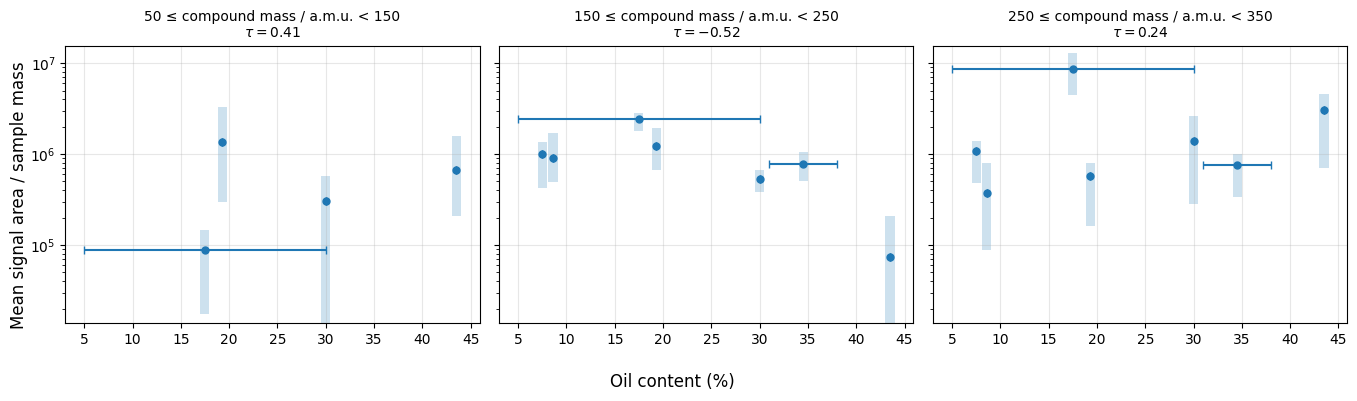

,bin_a,bin_b,n_points,tau_a,tau_b,delta_obs,p_value,p_value_adj
0,"(50, 150)","(150, 250)",7,0.411476,-0.523810,0.935285,0.133866,0.401598
2,"(150, 250)","(250, 350)",7,-0.523810,0.238095,-0.761905,0.279720,0.419580
1,"(50, 150)","(250, 350)",7,0.411476,0.238095,0.173380,0.738262,0.738262


In [83]:
# example
# compare differences in tau between mass bins for signal area vs oil content (oil markers only)
bins_plot_df = plot_signal_vs_trait_mass_bins(
    gcms_df[gcms_df['compound_norm'].isin(oil_markers)],
    seed_area_df,
    seed_traits_df,
    treatment="vacuum_whole",
    x_var="oil_content",
    normalise_by="sample_mass",
    mass_bins=((50, 150), (150, 250), (250, 350)),
)

bin_results = pairwise_bin_tau_permutation_tests(
    bins_plot_df,
    n_permutations=1000,
    random_state=42,
    adjust_pvals="bh",
)

bin_results.sort_values("p_value")